# NB01a — Ukraine Boundaries, Building Footprints, and UNOSAT Damage Labels

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `01a_full_unosat_overture_xBD_v2.ipynb` |
| **Version** | v2 |
| **Pipeline position** | First notebook. Data acquisition and exploration (before NB01b) |
| **Last validated** | 2026-04-XX |

## Narrative

This notebook is the entry point of the BDA pipeline. It starts by loading Ukraine
administrative boundaries (COD-AB shapefiles ADM0-ADM4) and creating an interactive
overview map of all ~50 target cities within their oblasts.

It then attempts to use **OSM building footprints** (2022 vs 2025 snapshots) as the
building inventory for damage assessment. Cell 12 analyzes whether temporal differences
between OSM snapshots can serve as a damage proxy. **Conclusion: OSM temporal comparison
is unsuitable for damage assessment** — differences reflect mapping activity and
completeness improvements, not physical building destruction.

The notebook then pivots to **UNOSAT damage labels**, downloading assessments from HDX
and loading the Dietrich et al. (2025) compiled labels (18,686 points across 6 cities).
The Dietrich compilation proved richer and more consistent than raw UNOSAT downloads.
Cells 15-17 extract, classify (EMS-98 mapping), and compile UNOSAT data per city.
Cells 18+ overlay UNOSAT damage points onto building footprints via spatial join +
nearest-neighbor matching.

**Key finding:** Neither OSM nor raw UNOSAT alone provides a reliable building-level
damage inventory. This motivated NB01b, which constructs AOI.geojson per city using
Overture Maps footprints + Dietrich UNOSAT labels as the master reference.

## Scientific Rationale

Building damage assessment requires two inputs: building footprints and damage labels.
OSM is the most accessible global building dataset but suffers from temporal inconsistency
and volunteer mapping bias (Barrington-Leigh & Millard-Ball 2017). UNOSAT provides
expert-verified damage labels but is incomplete — Aimaiti et al. (2022) showed that
UNOSAT false positives were often real damage that UNOSAT missed elsewhere. The Dietrich
et al. (2025) compilation standardizes UNOSAT labels across 6 Ukrainian cities with
consistent damage coding. This notebook documents the exploration that led to the final
data strategy in NB01b.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| COD-AB Ukraine shapefiles (ADM0-ADM4) | OCHA HDX | Shapefile |
| OSM building footprints (2022, 2025) | Pre-downloaded country shapefiles | Shapefile |
| UNOSAT damage assessments | HDX download (Cell 13) | Shapefile/GeoJSON |
| Dietrich UNOSAT labels | `unosat_labels.geojson` (18,686 points) | GeoJSON |
| `cities_config.json` | Manual | JSON (50 cities, battle dates, tiers) |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| `boundary.geojson` per city | `CITIES_DIR/{city}/` | NB01b, NB02, NB03 |
| `bda_city_boundaries.geojson` | `DATA_ROOT/` | NB01b |
| `bda_battle_dates.json` | `DATA_ROOT/` | NB01b, NB02 |
| `unosat_damage.geojson` per city | `UNOSAT_CITIES_DIR/{city}/` | NB01b |
| `unosat_ukraine_compiled.geojson` | `UNOSAT_COMPILED_DIR/` | NB01b, NB09 |
| OSM buildings per city (2022/2025) | `OSM_OUTPUT_DIR/` | Exploratory only (superseded by Overture in NB01b) |
| Interactive folium map | In-notebook HTML | Thesis figures |

## Prerequisites

- `global_setup.py` accessible
- `cities_config.json` in `notebooks/`
- COD-AB shapefiles downloaded to `DATA_ROOT/boundaries/`
- OSM country shapefiles in `OSM_DIR/` (for Cells 9-12)
- Internet access for UNOSAT HDX download (Cell 13)

## Key Findings (documented in cells)

| Cell | Finding | Consequence |
|------|---------|-------------|
| 12 | OSM 2022 vs 2025 differences = mapping activity, not damage | Cannot use OSM temporal diff as damage proxy |
| 14 | Raw UNOSAT downloads inconsistent across cities | Use Dietrich compiled labels instead |
| 16 | Dual damage columns (Main_Damag, d_Damage_S) need mapping | EMS-98 mapping strategy defined |
| 18B2 | Many UNOSAT points >15m from nearest building | OSM footprint coverage insufficient, need Overture |

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 3 | NB01a config (TIER_SELECTION, CLIP_MODE, TARGET_RES) | Config |
| 2 | Cell 4 | Load global_setup.py | Config |
| 3-4 | Cell 4B | Data verification (paths, dirs) | Config |
| 5-6 | Cell 5 | Load Ukraine admin boundaries + overview map | **Core** |
| 7-8 | Cell 6 | Load COD-AB ADM0-ADM4 polygon layers | **Core** |
| 9-10 | Cell 7 | Interactive folium map (oblasts + target cities) | **Core** |
| 11-12 | Cell 8 | Create city boundaries + battle dates (NUCLEUS) | **Core** |
| 13-14 | Cell 9 | Extract OSM buildings per city (2022/2025 snapshots) | Exploratory |
| 15-16 | Cell 10 | Clip OSM buildings per city (bbox/polygon) | Exploratory |
| 17-18 | Cell 11 | Inspect building data structure | Exploratory |
| 19-20 | Cell 12 | OSM mapping quality analysis (**negative result**) | Exploratory |
| 21-22 | Cell 13 | Download UNOSAT from HDX | **Core** |
| 23-24 | Cell 14 | Inspect UNOSAT files + Dietrich data | **Core** |
| 25-26 | Cell 15 | Extract UNOSAT damage per city | **Core** |
| 27-28 | Cell 16 | Analyze damage classifications + EMS-98 mapping | **Core** |
| 29-30 | Cell 17 | Compile UNOSAT with EMS-98 mapping | **Core** |
| 31-32 | Cell 18 | Overlay UNOSAT onto OSM buildings | Exploratory |
| 33-34 | Cell 18B2 | Analyze unmatched UNOSAT points | Exploratory |

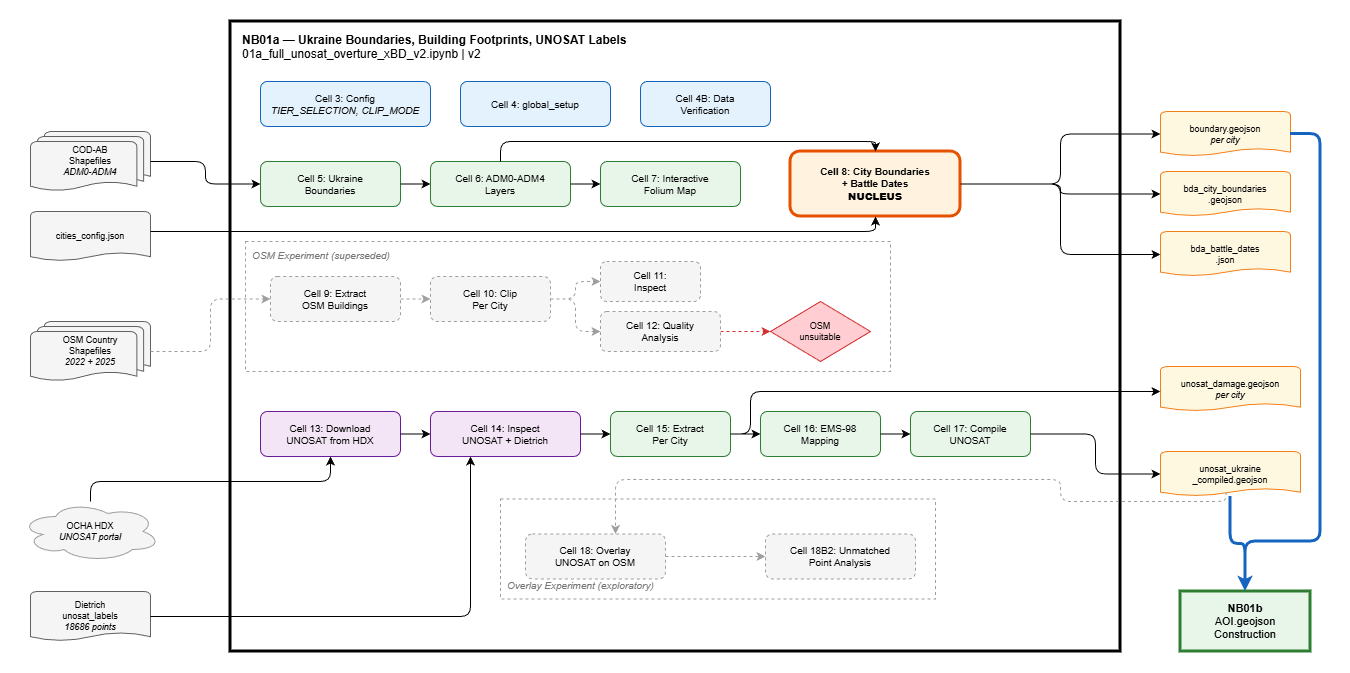

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.1 Study Area | 5, 6, 7 | Ukraine boundaries, oblast map, city selection |
| 3.2 Data Sources — Building Footprints | 9-12 | OSM exploration + negative result |
| 3.2 Data Sources — Damage Labels | 13-17 | UNOSAT acquisition, EMS-98 mapping, Dietrich compilation |
| 3.2 Data Sources — Label Limitations | 18, 18B2 | Spatial join accuracy, unmatched points |
| 4.0 or Appendix | 12 | OSM quality analysis (negative result, brief mention) |

# CELL 4: COMPLETE ENVIRONMENT SETUP (BDA + SNAP12) - LOCAL WSL VERSION


In [10]:
# @title CELL 3: NB01a CONFIG
# ---- shared ----
TIER_SELECTION = [0, 1, 2]
CITY_SELECTION = None              # or ["Mariupol"]
# ---- nucleus cell 8 (bbox alignment) ----
CLIP_MODE = "bbox"                 # "bbox" or "polygon"
TARGET_RES = 10.0
PREFERRED_DIVISOR = 256
BUFFER_M = 50.0
# ---- cell 9/10 (OSM buildings) ----
USE_EXISTING_OSM = True
USE_OVERPASS_API = False
EXTRACT_2025_ONLY = True
EXTRACT_2022_ONLY = False
EXTRACT_BOTH = False
PRIORITY_CITIES_ONLY = False
# ---- cell 11 (inspect) ----
INSPECT_CITY = "Mariupol"
# ---- cell 13 (UNOSAT download) ----
CHECK_FOR_NEW = False
UKRAINE_ONLY = True
# ---- cell 16 (UNOSAT analysis) ----
PLOT_ALL_CITIES = True
# ---- cell 17 (UNOSAT compile) ----
VERIFY_UKRAINE_COORDS = True
DROP_SPARSE_COLUMNS = True
# ---- cell 18 (damage overlay) ----
MAX_DISTANCE_METERS = 10
CREATE_DETAILED_MAPS = True

In [11]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-03-21 09:28:10
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /content/masterthesis_local/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 43 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------

  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
------

# CELL 4B: DATA VERIFICATION

In [12]:
# @title CELL 4B: DATA VERIFICATION
# =============================================================================
# Checks all data directories and files. Run after Cell 4.
# =============================================================================

import os
import shutil
from pathlib import Path
from datetime import datetime

print("=" * 70)
print("DATA VERIFICATION")
print("=" * 70)

# ============================================================================
# DIRECTORY INVENTORY
# ============================================================================

data_locations = {
    # Core satellite data (Google Drive)
    "SAR SLC (InSAR products)":     SAR_SLC_DIR,
    "SAR CARD-BS (calibrated)":     SAR_CARD_DIR,
    "Multispectral (Sentinel-2)":   MULTISPECTRAL_ROOT,
    "MS Metadata":                  MS_METADATA_DIR,
    "Landuse Classification":       LANDUSE_DIR,
    "Transition Matrix":            TRANSITION_DIR,

    # Reference data (Google Drive)
    "City Boundaries":              CITIES_DIR,
    "Ukraine Admin Boundaries":     UKR_BOUNDARIES,
    "OSM Feb 2022 (pre-conflict)":  OSM_2022,
    "OSM Oct 2025 (current)":       OSM_2025,
    "OSM Buildings (extracted)":    OSM_OUTPUT_DIR,
    "UNOSAT Damage Assessments":    UNOSAT_DIR,
    "xBD Dataset":                  XBD_ROOT,

    # ML (Google Drive)
    "Model Checkpoints":            CHECKPOINTS_DIR,
    "Pretrained Models":            PRETRAINED_DIR,
    "Trained Models":               TRAINED_DIR,

    # Results (Google Drive)
    "Predictions":                  PREDICTIONS_DIR,
    "Validation Results":           VALIDATION_DIR,
    "Visualizations":               VISUALIZATIONS_DIR,

    # Outputs & tracking (Google Drive)
    "Outputs":                      OUTPUTS_DIR,
    "Logs":                         LOGS_DIR,
}

for name, path in data_locations.items():
    path = Path(path)
    if not path.exists():
        print(f"  [ MISSING ] {name:35s} {path}")
        continue

    all_files = [f for f in path.rglob('*') if f.is_file()]
    if not all_files:
        print(f"  [ EMPTY  ] {name:35s} {path}")
        continue

    total_mb = sum(f.stat().st_size for f in all_files) / (1024**2)
    total_gb = total_mb / 1024

    if total_gb >= 1:
        size_str = f"{total_gb:.1f} GB"
    else:
        size_str = f"{total_mb:.1f} MB"

    print(f"  [   OK   ] {name:35s} {len(all_files):6d} files, {size_str}")

# ============================================================================
# LOCAL HDD STORAGE
# ============================================================================

print(f"\nLocal HDD storage:")
print("-" * 70)

local_locations = {
    "RAW SLC ZIPs (prestage)":      RAW_SLC_ZIP,
    "Orbit files (POEORB)":         ORBITS_DIR,
    "DEM tiles":                    DEM_DIR,
}

for name, path in local_locations.items():
    path = Path(path)
    if not path.exists():
        print(f"  [ MISSING ] {name:35s} {path}")
        continue

    all_files = [f for f in path.rglob('*') if f.is_file()]
    if not all_files:
        print(f"  [ EMPTY  ] {name:35s} {path}")
        continue

    total_mb = sum(f.stat().st_size for f in all_files) / (1024**2)
    total_gb = total_mb / 1024

    if total_gb >= 1:
        size_str = f"{total_gb:.1f} GB"
    else:
        size_str = f"{total_mb:.1f} MB"

    print(f"  [   OK   ] {name:35s} {len(all_files):6d} files, {size_str}")

# ============================================================================
# SNAP WORKDIR
# ============================================================================

print(f"\nSNAP work directories:")
print("-" * 70)

snap_locations = {
    "SNAP workdir":                 SNAP_WORKDIR,
    "Temp download dir":            TEMP_DOWNLOAD_DIR,
    "Crossbattle stash":            CROSSBATTLE_STASH_DIR,
    "SNAP graph XMLs":              SNAP_GRAPH_DIR,
}

for name, path in snap_locations.items():
    path = Path(path)
    if not path.exists():
        print(f"  [ MISSING ] {name:35s} {path}")
    else:
        all_files = [f for f in path.rglob('*') if f.is_file()]
        total_mb = sum(f.stat().st_size for f in all_files) / (1024**2) if all_files else 0
        if total_mb >= 1024:
            print(f"  [   OK   ] {name:35s} {len(all_files):6d} files, {total_mb/1024:.1f} GB")
        elif all_files:
            print(f"  [   OK   ] {name:35s} {len(all_files):6d} files, {total_mb:.1f} MB")
        else:
            print(f"  [ EMPTY  ] {name:35s} {path}")

if os.path.exists(GPT_PATH):
    print(f"  [   OK   ] {'SNAP GPT binary':35s} {GPT_PATH}")
else:
    print(f"  [ MISSING ] {'SNAP GPT binary':35s} {GPT_PATH}")

# ============================================================================
# TRACKING FILES
# ============================================================================

print(f"\nTracking files:")
print("-" * 70)

tracking_files = {
    "InSAR tracker":        INSAR_TRACKER_FILE,
    "MS download tracker":  MS_TRACKING_FILE,
    "CARD download tracker": CARD_TRACKER_FILE,
    "Scene discovery":      PROGRESS_FILE,
    "SAR cities pkl":       CITIES_PKL_FILE,
    "MS cities pkl":        MS_CITIES_PKL_FILE,
}

for name, fpath in tracking_files.items():
    fpath = Path(fpath)
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        print(f"  [   OK   ] {name:30s} ({size_kb:.1f} KB)")
    else:
        print(f"  [ MISSING ] {name:30s}")

# ============================================================================
# CRITICAL DATA CHECK
# ============================================================================

print(f"\nCritical data check:")
print("-" * 70)

critical_checks = {
    "City boundaries (.geojson)":   (CITIES_DIR,          ["*.geojson"]),
    "SAR SLC products (.tif)":      (SAR_SLC_DIR,         ["*.tif"]),
    "SAR CARD products (.tif)":     (SAR_CARD_DIR,        ["*.tif"]),
    "Multispectral scenes (.tif)":  (MULTISPECTRAL_ROOT,  ["*.tif", "*.jp2"]),
    "Landuse classification (.tif)":(LANDUSE_DIR,         ["*.tif"]),
    "OSM 2022 data":                (OSM_2022,            ["*.pbf", "*.shp", "*.geojson"]),
    "OSM 2025 data":                (OSM_2025,            ["*.pbf", "*.shp", "*.geojson"]),
    "Admin boundaries (.shp)":      (UKR_BOUNDARIES,      ["*.shp"]),
    "UNOSAT raw shapefiles":        (UNOSAT_RAW_DIR,      ["*.shp", "*.geojson", "*.zip"]),
    "Orbit files (.EOF)":           (ORBITS_DIR,          ["*.EOF", "*.EOF.zip"]),
}

all_ok = True
critical_missing = []

for check_name, (path, patterns) in critical_checks.items():
    path = Path(path)
    if not path.exists():
        print(f"  X  {check_name:40s}: MISSING")
        all_ok = False
        critical_missing.append(check_name)
        continue

    found = []
    for pattern in patterns:
        found.extend(path.rglob(pattern))

    if found:
        print(f"  OK {check_name:40s}: {len(found)} files")
    else:
        print(f"  -- {check_name:40s}: empty")

# ============================================================================
# PER-CITY SAR COVERAGE
# ============================================================================

print(f"\nPer-city SAR coverage:")
print("-" * 70)

sar_slc_path = Path(SAR_SLC_DIR)
sar_card_path = Path(SAR_CARD_DIR)

if sar_slc_path.exists():
    cities_slc = sorted([d.name for d in sar_slc_path.iterdir() if d.is_dir() and d.name != 'metadata'])
    for city in cities_slc:
        slc_files = list((sar_slc_path / city).rglob('*.tif'))
        card_files = list((sar_card_path / city).rglob('*.tif')) if (sar_card_path / city).exists() else []

        slc_pre = len([f for f in slc_files if 'prebattle' in str(f)])
        slc_post = len([f for f in slc_files if 'postbattle' in str(f)])
        slc_cross = len([f for f in slc_files if 'crossbattle' in str(f)])
        slc_monthly = len([f for f in slc_files if 'monthly' in str(f)])
        card_count = len(card_files)

        monthly_str = f" monthly={slc_monthly:2d}" if slc_monthly else ""
        print(f"  {city:25s}  SLC: pre={slc_pre:2d} post={slc_post:2d} cross={slc_cross:2d}{monthly_str}  CARD: {card_count:2d}")
else:
    print("  SAR_SLC_DIR not found")

# ============================================================================
# PRESTAGE ZIP INVENTORY
# ============================================================================

print(f"\nPrestage ZIP inventory:")
print("-" * 70)

raw_slc_path = Path(RAW_SLC_ZIP)
if raw_slc_path.exists():
    zips = list(raw_slc_path.glob('*.zip'))
    if zips:
        total_gb = sum(z.stat().st_size for z in zips) / (1024**3)
        print(f"  {len(zips)} ZIP files, {total_gb:.1f} GB total")
    else:
        print(f"  No ZIPs in {raw_slc_path}")
else:
    print(f"  RAW_SLC_ZIP not mounted: {raw_slc_path}")

# ============================================================================
# DISK SPACE
# ============================================================================

print(f"\nDisk space:")
print("-" * 70)

disk = get_disk_space('/content/drive')
if disk:
    print(f"  Drive:  {disk['used_gb']:.1f} / {disk['total_gb']:.1f} GB ({disk['free_gb']:.1f} GB free)")

disk_local = get_disk_space('/')
if disk_local:
    print(f"  Local:  {disk_local['used_gb']:.1f} / {disk_local['total_gb']:.1f} GB ({disk_local['free_gb']:.1f} GB free)")

if CONTENT_LOCAL.exists():
    disk_hdd = get_disk_space(str(CONTENT_LOCAL))
    if disk_hdd:
        print(f"  HDD:    {disk_hdd['used_gb']:.1f} / {disk_hdd['total_gb']:.1f} GB ({disk_hdd['free_gb']:.1f} GB free)")

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*70}")
if not critical_missing:
    print("ALL CRITICAL DATA PRESENT")
else:
    print(f"WARNING: {len(critical_missing)} data source(s) need attention:")
    for item in critical_missing:
        print(f"  - {item}")
print(f"{'='*70}")

VERIFICATION_STATUS = {
    'all_ok': all_ok,
    'critical_missing': critical_missing,
    'timestamp': datetime.now().isoformat()
}

DATA VERIFICATION
  [   OK   ] SAR SLC (InSAR products)                53 files, 20.0 MB
  [   OK   ] SAR CARD-BS (calibrated)                 1 files, 0.0 MB
  [   OK   ] Multispectral (Sentinel-2)           72922 files, 562.8 GB
  [   OK   ] MS Metadata                             52 files, 1.2 MB
  [   OK   ] Landuse Classification                5742 files, 38.1 GB
  [   OK   ] Transition Matrix                        1 files, 0.0 MB
  [   OK   ] City Boundaries                        224 files, 2.8 GB
  [   OK   ] Ukraine Admin Boundaries                60 files, 139.5 MB
  [   OK   ] OSM Feb 2022 (pre-conflict)             92 files, 3.7 GB
  [   OK   ] OSM Oct 2025 (current)                  92 files, 4.6 GB
  [   OK   ] OSM Buildings (extracted)              123 files, 848.6 MB
  [   OK   ] UNOSAT Damage Assessments             1048 files, 1.2 GB
  [   OK   ] xBD Dataset                          11203 files, 8.0 GB
  [   OK   ] Model Checkpoints                        1 files, 0

# CELL 5: LOAD & VISUALIZE UKRAINE BOUNDARIES

In [13]:
# @title CELL 5: LOAD & VISUALIZE UKRAINE BOUNDARIES
# =============================================================================
# Loads admin boundary shapefiles, city boundaries, creates overview map.
# Requires: Cell 4 + Cell 4A (paths)
# =============================================================================

CELL_ID = "cell_05_ukraine_boundaries"
FORCE_RERUN = False

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 5 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    boundaries = previous_log.get('boundaries', {})
    print(f"  {len(boundaries)} boundary layers available")
else:
    start_time = datetime.now()

    print("=" * 70)
    print("LOADING UKRAINE BOUNDARIES")
    print("=" * 70)

    # ========================================================================
    # ADMIN BOUNDARIES (shapefiles)
    # ========================================================================

    boundaries = {}
    admin_levels = {}

    boundary_path = Path(UKR_BOUNDARIES)
    if boundary_path.exists():
        boundary_files = list(boundary_path.glob("*.shp"))
        print(f"\nAdmin boundary shapefiles: {len(boundary_files)}")

        for shp_file in boundary_files:
            try:
                gdf = gpd.read_file(shp_file)
                layer_name = shp_file.stem
                boundaries[layer_name] = gdf
                print(f"  {layer_name}: {len(gdf)} features, CRS={gdf.crs}")

                if 'adm0' in layer_name.lower() or 'country' in layer_name.lower():
                    admin_levels['country'] = gdf
                elif 'adm1' in layer_name.lower() or 'oblast' in layer_name.lower():
                    admin_levels['oblast'] = gdf
                elif 'adm2' in layer_name.lower() or 'raion' in layer_name.lower():
                    admin_levels['raion'] = gdf
            except Exception as e:
                print(f"  ERROR loading {shp_file.name}: {e}")
    else:
        print(f"  Admin boundaries not found: {boundary_path}")

    # ========================================================================
    # CITY BOUNDARIES (geojson per city)
    # ========================================================================

    cities_path = Path(CITIES_DIR)
    city_boundaries = {}

    if cities_path.exists():
        city_dirs = sorted([d for d in cities_path.iterdir() if d.is_dir()])
        print(f"\nCity boundaries: {len(city_dirs)} cities")

        for city_dir in city_dirs:
            geojson_file = city_dir / 'boundary.geojson'
            if geojson_file.exists():
                try:
                    gdf = gpd.read_file(geojson_file)
                    city_boundaries[city_dir.name] = gdf
                except Exception as e:
                    print(f"  ERROR loading {city_dir.name}: {e}")

        print(f"  Loaded: {len(city_boundaries)} city boundaries")

        if city_boundaries:
            # show sample
            for name, gdf in list(city_boundaries.items())[:5]:
                area_km2 = gdf.to_crs(epsg=32636).geometry.area.sum() / 1e6
                print(f"    {name:25s}: {area_km2:.1f} km2")
            if len(city_boundaries) > 5:
                print(f"    ... and {len(city_boundaries) - 5} more")
    else:
        print(f"  Cities dir not found: {cities_path}")

    # ========================================================================
    # VISUALIZATION
    # ========================================================================

    print(f"\n{'='*70}")
    print("VISUALIZATION")
    print(f"{'='*70}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Plot 1: Admin boundaries
    ax1 = axes[0]
    if 'oblast' in admin_levels:
        admin_levels['oblast'].plot(ax=ax1, edgecolor='black', facecolor='lightblue', linewidth=0.5)
        ax1.set_title(f"Ukraine Oblasts ({len(admin_levels['oblast'])} features)")
    elif 'country' in admin_levels:
        admin_levels['country'].plot(ax=ax1, edgecolor='black', facecolor='lightblue', linewidth=1)
        ax1.set_title("Ukraine Country Boundary")
    elif boundaries:
        first_layer = list(boundaries.values())[0]
        first_layer.plot(ax=ax1, edgecolor='black', facecolor='lightblue', linewidth=0.5)
        ax1.set_title(f"Boundaries ({len(first_layer)} features)")
    else:
        ax1.text(0.5, 0.5, 'No admin boundaries loaded', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title("Admin Boundaries (missing)")

    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True, alpha=0.3)

    # Plot 2: City boundaries on top of admin
    ax2 = axes[1]
    if 'oblast' in admin_levels:
        admin_levels['oblast'].plot(ax=ax2, edgecolor='gray', facecolor='#f0f0f0', linewidth=0.3)
    elif 'country' in admin_levels:
        admin_levels['country'].plot(ax=ax2, edgecolor='gray', facecolor='#f0f0f0', linewidth=0.5)

    if city_boundaries:
        all_cities_gdf = gpd.GeoDataFrame(
            pd.concat([gdf.assign(city=name) for name, gdf in city_boundaries.items()], ignore_index=True)
        )
        all_cities_gdf.plot(ax=ax2, edgecolor='red', facecolor='salmon', linewidth=1, alpha=0.7)

        # label cities
        for name, gdf in city_boundaries.items():
            centroid = gdf.geometry.centroid.iloc[0]
            ax2.annotate(name, xy=(centroid.x, centroid.y), fontsize=5, ha='center',
                        alpha=0.8, color='darkred')

    ax2.set_title(f"Target Cities ({len(city_boundaries)})")
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.grid(True, alpha=0.3)

    # zoom to cities area if available
    if city_boundaries:
        all_bounds = all_cities_gdf.total_bounds
        pad = 1.0
        ax2.set_xlim(all_bounds[0] - pad, all_bounds[2] + pad)
        ax2.set_ylim(all_bounds[1] - pad, all_bounds[3] + pad)

    plt.tight_layout()

    fig_path = Path(OUTPUTS_DIR) / CELL_ID
    fig_path.mkdir(exist_ok=True)
    plt.savefig(fig_path / "boundaries_overview.png", dpi=150, bbox_inches='tight')
    print(f"\nSaved: {fig_path / 'boundaries_overview.png'}")
    plt.show()
    plt.close()

    # ========================================================================
    # SUMMARY & LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    boundary_info = {}
    for name, gdf in boundaries.items():
        boundary_info[name] = {'features': len(gdf), 'crs': str(gdf.crs)}

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'boundaries': boundary_info,
        'admin_levels': list(admin_levels.keys()),
        'city_count': len(city_boundaries),
    }

    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"BOUNDARIES LOADED ({duration:.1f}s)")
    print(f"  Admin layers: {len(boundaries)}")
    print(f"  City boundaries: {len(city_boundaries)}")
    print(f"{'='*70}")

plt.close('all')

CELL 5 already run (2026-03-13). Set FORCE_RERUN=True to re-run.
  7 boundary layers available


# CELL 6: LOAD COD-AB ADMINISTRATIVE BOUNDARIES (ADM0-ADM4)

In [14]:
# @title CELL 6: LOAD COD-AB ADMINISTRATIVE BOUNDARIES (ADM0-ADM4)
# =============================================================================
# Loads COD-AB polygon layers (admbnda shapefiles) by admin level.
# Requires: Cell 4 + Cell 4A (paths)
# =============================================================================

CELL_ID = "cell_06_cod_ab_boundaries"
FORCE_RERUN = False

import os
import re
import glob
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 6 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    for info in previous_log.get('levels_info', []):
        print(f"  ADM{info['level']}: {info['features']} features")
    levels = {}
else:
    start_time = datetime.now()

    print("=" * 70)
    print("LOADING COD-AB ADMINISTRATIVE BOUNDARIES")
    print("=" * 70)

    def load_cod_ab_areas(root):
        files = sorted(glob.glob(os.path.join(root, "**", "*.shp"), recursive=True))
        by_level = {}
        for f in files:
            base = os.path.basename(f).lower()
            if "admbnda" not in base:
                continue
            m = re.search(r"adm(\d)", base)
            if not m:
                continue
            lvl = int(m.group(1))
            g = gpd.read_file(f).to_crs(4326)
            g = g[g.geometry.notnull() & (~g.geometry.is_empty)]
            g = g[g.geom_type.isin(["Polygon", "MultiPolygon"])]
            if g.empty:
                continue
            print(f"  ADM{lvl}: {os.path.basename(f)} ({len(g)} features)")
            by_level[lvl] = g if lvl not in by_level else gpd.GeoDataFrame(
                pd.concat([by_level[lvl], g], ignore_index=True), crs=4326
            )
        return by_level

    print(f"\nSearching: {UKR_BOUNDARIES}")
    levels = load_cod_ab_areas(UKR_BOUNDARIES)

    if not levels:
        print("WARNING: No COD-AB polygon layers found. Check UKR_BOUNDARIES path.")
    else:
        print(f"\nLoaded {len(levels)} admin levels:")
        levels_info = []
        for lvl in sorted(levels):
            gdf = levels[lvl]
            print(f"  ADM{lvl}: {len(gdf)} features, bounds={gdf.total_bounds.round(2)}")
            levels_info.append({
                'level': lvl,
                'features': len(gdf),
                'crs': str(gdf.crs),
                'bounds': gdf.total_bounds.tolist()
            })

        # visualization
        fig, ax = plt.subplots(figsize=(9, 9))
        style = {
            0: ("black", 1.5),
            1: ("tab:blue", 0.6),
            2: ("tab:orange", 0.3),
            3: ("tab:green", 0.25),
            4: ("tab:purple", 0.2)
        }

        for lvl in sorted(levels):
            color, lw = style.get(lvl, ("gray", 0.3))
            levels[lvl].boundary.plot(ax=ax, color=color, linewidth=lw, alpha=0.85,
                                      aspect="auto", label=f"ADM{lvl}")

        ax.set_title("Ukraine - COD-AB Administrative Boundaries (ADM0-ADM4)", fontsize=14, fontweight='bold')
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend(loc="lower left", fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')

        try:
            ax.set_aspect("equal", adjustable="datalim")
        except Exception:
            ax.set_aspect("auto")

        plt.tight_layout()

        fig_dir = Path(OUTPUTS_DIR) / CELL_ID
        fig_dir.mkdir(exist_ok=True)
        fig_path = fig_dir / "ukraine_cod_ab_boundaries.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"\nSaved: {fig_path}")
        plt.show()
        plt.close()

        # log
        duration = (datetime.now() - start_time).total_seconds()
        log_data = {
            'cell_id': CELL_ID,
            'status': 'SUCCESS',
            'timestamp': datetime.now().isoformat(),
            'duration_seconds': duration,
            'levels_info': levels_info,
            'num_levels': len(levels),
            'total_features': sum(len(levels[lvl]) for lvl in levels),
        }
        with open(CELL_LOG_FILE, 'w') as f:
            json.dump(log_data, f, indent=2)

        print(f"\n{'='*70}")
        print(f"COD-AB LOADED ({duration:.1f}s)")
        print(f"  Access: levels[0], levels[1], ... levels[4]")
        print(f"{'='*70}")


plt.close('all')

CELL 6 already run (2026-02-11). Set FORCE_RERUN=True to re-run.
  ADM0: 1 features
  ADM1: 27 features
  ADM2: 139 features
  ADM3: 1769 features
  ADM4: 29707 features


# CELL 7: INTERACTIVE MAP - OBLASTS + TARGET CITIES

In [15]:
# @title CELL 7: INTERACTIVE MAP - OBLASTS + TARGET CITIES
# =============================================================================
# Creates folium interactive map with ADM1 oblasts and target city boundaries.
# Uses city boundaries from CITIES_DIR instead of OSM places points.
# Requires: Cell 4 + 4A (paths), Cell 5 (city_boundaries), Cell 6 (levels)
# =============================================================================

CELL_ID = "cell_07_interactive_map"
FORCE_RERUN = False

import os
import re
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 7 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Oblasts: {previous_log.get('oblasts_count', '?')}, Cities: {previous_log.get('cities_count', '?')}")
    map_file = previous_log.get('map_file')
    if map_file:
        print(f"  Map: {map_file}")
else:
    start_time = datetime.now()

    print("=" * 70)
    print("CREATING INTERACTIVE MAP")
    print("=" * 70)

    # ========================================================================
    # LOAD ADM1 OBLASTS
    # ========================================================================

    def find_admbnda_shp(root, level):
        pats = [f"*admbnda*adm{level}*.shp", f"*ADMBNDA*ADM{level}*.shp"]
        for p in pats:
            hits = glob.glob(os.path.join(root, "**", p), recursive=True)
            if hits:
                return sorted(hits)[0]
        return None

    def sanitize_for_folium(gdf):
        gdf = gdf.copy()
        dt_cols = list(gdf.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns)
        for c in dt_cols:
            gdf[c] = gdf[c].astype(str)
        return gdf.replace({np.nan: None})

    def tooltip_fields(gdf, level):
        candidates = [f"adm{level}_en", f"adm{level}_ua", f"adm{level}_ru", f"adm{level}_pcode",
                      "NAME_EN", "NAME_UA", "NAME", "adm1_en", "adm1_ua", "adm1_pcode"]
        return [c for c in candidates if c in gdf.columns]

    # try to use levels dict from Cell 6, otherwise load from shapefile
    if 'levels' in dir() and levels and 1 in levels:
        adm1 = levels[1].copy()
        print(f"  ADM1 from Cell 6: {len(adm1)} oblasts")
    else:
        shp = find_admbnda_shp(UKR_BOUNDARIES, 1)
        if shp:
            adm1 = gpd.read_file(shp).to_crs(4326)
            adm1 = adm1[adm1.geometry.notnull() & (~adm1.geometry.is_empty)]
            adm1 = adm1[adm1.geom_type.isin(["Polygon", "MultiPolygon"])]
            print(f"  ADM1 from shapefile: {len(adm1)} oblasts")
        else:
            adm1 = None
            print("  WARNING: No ADM1 shapefile found")

    # ========================================================================
    # LOAD TARGET CITY BOUNDARIES
    # ========================================================================

    cities_path = Path(CITIES_DIR)
    target_cities = {}

    if cities_path.exists():
        for city_dir in sorted(cities_path.iterdir()):
            if not city_dir.is_dir():
                continue
            geojson = city_dir / 'boundary.geojson'
            if geojson.exists():
                try:
                    gdf = gpd.read_file(geojson)
                    target_cities[city_dir.name] = gdf
                except:
                    pass

    print(f"  Target cities: {len(target_cities)}")

    # ========================================================================
    # CREATE FOLIUM MAP
    # ========================================================================

    if adm1 is not None:
        adm1 = sanitize_for_folium(adm1)
        minx, miny, maxx, maxy = adm1.total_bounds
    else:
        minx, miny, maxx, maxy = 22.0, 44.0, 40.5, 52.5

    center = [(miny + maxy) / 2, (minx + maxx) / 2]
    m = folium.Map(location=center, zoom_start=6, tiles="cartodbpositron")

    # oblast layer
    if adm1 is not None:
        sty_oblast = lambda f: {"color": "#1f77b4", "weight": 1.2, "fillColor": "#cfe8ff", "fillOpacity": 0.18}
        folium.GeoJson(
            adm1,
            name="ADM1 - Oblasts",
            style_function=sty_oblast,
            highlight_function=lambda f: {"weight": 3, "color": "#135ba1"},
            tooltip=folium.GeoJsonTooltip(fields=tooltip_fields(adm1, 1), sticky=True),
        ).add_to(m)

    # city boundaries layer
    cities_added = 0
    if target_cities:
        city_group = folium.FeatureGroup(name="Target Cities").add_to(m)

        for city_name, gdf in target_cities.items():
            gdf = sanitize_for_folium(gdf.to_crs(4326))
            centroid = gdf.geometry.centroid.iloc[0]
            area_km2 = gdf.to_crs(epsg=32636).geometry.area.sum() / 1e6

            # boundary polygon
            sty_city = lambda f: {"color": "#e74c3c", "weight": 2, "fillColor": "#ff9999", "fillOpacity": 0.3}
            folium.GeoJson(
                gdf,
                style_function=sty_city,
                tooltip=f"<b>{city_name}</b><br>{area_km2:.1f} km2",
            ).add_to(city_group)

            # label marker
            folium.CircleMarker(
                location=[centroid.y, centroid.x],
                radius=4,
                color="#e74c3c",
                fill=True,
                fill_opacity=0.9,
                tooltip=f"<b>{city_name}</b><br>{area_km2:.1f} km2",
            ).add_to(city_group)

            cities_added += 1

    # legend
    legend_html = """
    <div style="
        position: fixed; bottom: 20px; left: 20px; z-index: 9999;
        background: rgba(255,255,255,0.95); padding: 10px 12px;
        border: 1px solid #999; border-radius: 6px; font-size: 13px;">
    <b>Layers</b><br>
    <span style="display:inline-block;width:14px;height:14px;background:#cfe8ff;border:1px solid #1f77b4;"></span>
    &nbsp;ADM1 - Oblasts<br>
    <span style="display:inline-block;width:14px;height:14px;background:#ff9999;border:1px solid #e74c3c;"></span>
    &nbsp;Target Cities
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl(collapsed=False).add_to(m)

    # save interactive map
    fig_dir = Path(OUTPUTS_DIR) / CELL_ID
    fig_dir.mkdir(parents=True, exist_ok=True)
    map_file = fig_dir / "ukraine_interactive_map.html"
    m.save(str(map_file))
    print(f"\n  Interactive map saved: {map_file}")

    # ========================================================================
    # STATIC PREVIEW
    # ========================================================================

    fig, ax = plt.subplots(figsize=(12, 10))

    if adm1 is not None:
        adm1.plot(ax=ax, edgecolor='#1f77b4', facecolor='#cfe8ff', linewidth=1.2, alpha=0.5)

    if target_cities:
        all_cities_gdf = gpd.GeoDataFrame(
            pd.concat([gdf.assign(city=name) for name, gdf in target_cities.items()], ignore_index=True)
        )
        all_cities_gdf.plot(ax=ax, edgecolor='#e74c3c', facecolor='#ff9999', linewidth=1.5, alpha=0.7)

        for name, gdf in target_cities.items():
            centroid = gdf.geometry.centroid.iloc[0]
            ax.annotate(name, xy=(centroid.x, centroid.y), fontsize=5, ha='center',
                       alpha=0.8, color='darkred')

    ax.set_title(f"Ukraine - Oblasts + Target Cities ({cities_added})", fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3, linestyle='--')

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, f"Oblasts: {len(adm1) if adm1 is not None else 0}\nTarget cities: {cities_added}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)

    plt.tight_layout()

    screenshot = fig_dir / "ukraine_map_screenshot.png"
    plt.savefig(screenshot, dpi=150, bbox_inches='tight')
    print(f"  Static preview saved: {screenshot}")
    plt.show()
    plt.close()

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'oblasts_count': len(adm1) if adm1 is not None else 0,
        'cities_count': cities_added,
        'map_file': str(map_file),
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"INTERACTIVE MAP COMPLETE ({duration:.1f}s)")
    print(f"  Open in browser: {map_file}")
    print(f"{'='*70}")

plt.close('all') 

CELL 7 already run (2026-02-11). Set FORCE_RERUN=True to re-run.
  Oblasts: 27, Cities: 50
  Map: /content/drive/MyDrive/masterthesis/data/outputs/cell_07_interactive_map/ukraine_interactive_map.html


# CELL 8: CREATE CITY BOUNDARIES + BATTLE DATES (NUCLEUS)

In [16]:
# @title CELL 8: CREATE CITY BOUNDARIES + BATTLE DATES (NUCLEUS)
# =============================================================================
# THIS IS THE FOUNDATIONAL CELL that creates all boundary.geojson files.
# It spatial-joins city coordinates to ADM3/ADM4 polygons and saves:
#   - CITIES_DIR/{city}/boundary.geojson (individual, with battle dates)
#   - DATA_ROOT/bda_city_boundaries.geojson (master file)
#   - DATA_ROOT/bda_battle_dates.json
#
# Properties per city: city_name, lat, lon, oblast, tier, priority,
#                      admin_level, battle_start, battle_stop, geometry
#
# Requires: Cell 4 + 4A (paths), Cell 6 optional (levels)
# =============================================================================

CELL_ID = "cell_08_city_boundaries"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Point
import json
from datetime import datetime
import glob
import math
import pyproj
from shapely.geometry import box as shapely_box
from shapely.ops import transform as shapely_transform

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)


# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 8 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities: {previous_log.get('total_cities', '?')}, "
          f"Battle dates: {previous_log.get('cities_with_battle_dates', '?')}")

    # Load master boundaries into memory
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    if city_boundaries_file.exists():
        cities_gdf = gpd.read_file(city_boundaries_file)
        print(f"  Loaded cities_gdf: {len(cities_gdf)} cities")
    else:
        print(f"  WARNING: Master file missing, set FORCE_RERUN=True")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("CREATING CITY BOUNDARIES WITH BATTLE DATES")
    print("=" * 70)
    print(f"Total cities defined: {len(PRIORITY_CITIES_COORDS)}")
    print(f"Cities with battle dates: {len([c for c in PRIORITY_CITIES_COORDS if c['name'] in BATTLE_DATES])}")

    # Create GeoDataFrame from coordinates
    geometry = [Point(city['lon'], city['lat']) for city in PRIORITY_CITIES_COORDS]
    cities_points_gdf = gpd.GeoDataFrame(PRIORITY_CITIES_COORDS, geometry=geometry, crs='EPSG:4326')

    # Save city coordinates
    coords_json = Path(DATA_ROOT) / "bda_city_coordinates.json"
    with open(coords_json, 'w') as f:
        json.dump(PRIORITY_CITIES_COORDS, f, indent=2)
    print(f"\n  Saved coordinates: {coords_json}")

    coords_geojson = Path(DATA_ROOT) / "bda_city_coordinates.geojson"
    cities_points_gdf.to_file(coords_geojson, driver='GeoJSON')
    print(f"  Saved GeoJSON: {coords_geojson}")

    # ========================================================================
    # LOAD ADM3/ADM4 BOUNDARIES
    # ========================================================================

    print(f"\nLoading administrative boundaries...")

    adm3_files = list(Path(UKR_BOUNDARIES).glob("*adm3*.shp"))
    adm4_files = list(Path(UKR_BOUNDARIES).glob("*adm4*.shp"))

    if not adm3_files and not adm4_files:
        raise FileNotFoundError("No ADM3 or ADM4 boundary files found in UKR_BOUNDARIES")

    adm3_gdf = gpd.read_file(adm3_files[0]) if adm3_files else None
    adm4_gdf = gpd.read_file(adm4_files[0]) if adm4_files else None

    print(f"  ADM3: {len(adm3_gdf) if adm3_gdf is not None else 0} polygons")
    print(f"  ADM4: {len(adm4_gdf) if adm4_gdf is not None else 0} polygons")

    # Ensure same CRS
    ref_crs = adm3_gdf.crs if adm3_gdf is not None else adm4_gdf.crs
    cities_points_gdf = cities_points_gdf.to_crs(ref_crs)

    # ========================================================================
    # SPATIAL JOIN: MATCH CITIES TO ADM BOUNDARIES
    # ========================================================================

    print(f"\nMatching cities to administrative boundaries...")

    city_boundaries = []

    for idx, city_row in cities_points_gdf.iterrows():
        city_name = city_row['name']
        city_point = city_row.geometry
        battle_info = BATTLE_DATES.get(city_name, {})

        matched = False

        # Try ADM4 first (more granular)
        if adm4_gdf is not None:
            matching = adm4_gdf[adm4_gdf.contains(city_point)]
            if len(matching) > 0:
                city_boundaries.append({
                    'city_name': city_name,
                    'lat': city_row['lat'],
                    'lon': city_row['lon'],
                    'oblast': city_row['oblast'],
                    'tier': city_row['tier'],
                    'priority': city_row['priority'],
                    'admin_level': 'ADM4',
                    'battle_start': battle_info.get('start', None),
                    'battle_stop': battle_info.get('stop', None),
                    'geometry': matching.iloc[0].geometry
                })
                print(f"  {city_name:25s} ADM4  battle: {battle_info.get('start', 'N/A')} to {battle_info.get('stop', 'N/A')}")
                matched = True

        # Try ADM3 if ADM4 didn't match
        if not matched and adm3_gdf is not None:
            matching = adm3_gdf[adm3_gdf.contains(city_point)]
            if len(matching) > 0:
                city_boundaries.append({
                    'city_name': city_name,
                    'lat': city_row['lat'],
                    'lon': city_row['lon'],
                    'oblast': city_row['oblast'],
                    'tier': city_row['tier'],
                    'priority': city_row['priority'],
                    'admin_level': 'ADM3',
                    'battle_start': battle_info.get('start', None),
                    'battle_stop': battle_info.get('stop', None),
                    'geometry': matching.iloc[0].geometry
                })
                print(f"  {city_name:25s} ADM3  battle: {battle_info.get('start', 'N/A')} to {battle_info.get('stop', 'N/A')}")
                matched = True

        if not matched:
            print(f"  {city_name:25s} WARNING: no ADM boundary found")

    if not city_boundaries:
        raise RuntimeError("No city boundaries could be created")

    # Create GeoDataFrame
    cities_gdf = gpd.GeoDataFrame(city_boundaries, crs=ref_crs)

    print(f"\n  Created boundaries for {len(cities_gdf)}/{len(cities_points_gdf)} cities")
    print(f"  Admin level distribution: {cities_gdf['admin_level'].value_counts().to_dict()}")

    # Battle date statistics
    cities_with_dates = cities_gdf['battle_start'].notna().sum()
    ongoing_battles = (cities_gdf['battle_stop'] == 'ongoing').sum()
    completed_battles = ((cities_gdf['battle_stop'] != 'ongoing') & cities_gdf['battle_stop'].notna()).sum()

    print(f"\n  Battle dates: {cities_with_dates}/{len(cities_gdf)} cities")
    print(f"    Ongoing: {ongoing_battles}, Completed: {completed_battles}")
    # ========================================================================
    # COMPUTE PIXEL-ALIGNED BOUNDING BOXES (for patch generation)
    # ========================================================================


    print(f"\nComputing 256-aligned bounding boxes...")

    bbox_results = {}

    for idx, row in cities_gdf.iterrows():
        city_name = row['city_name']
        city_geom = row.geometry

        # auto-detect UTM zone from city centroid
        centroid = city_geom.centroid
        utm_zone = int((centroid.x + 180) / 6) + 1
        hemisphere = 'north' if centroid.y >= 0 else 'south'
        utm_epsg = 32600 + utm_zone if hemisphere == 'north' else 32700 + utm_zone

        # project to UTM
        project_to_utm = pyproj.Transformer.from_crs('EPSG:4326', f'EPSG:{utm_epsg}', always_xy=True).transform
        project_to_wgs = pyproj.Transformer.from_crs(f'EPSG:{utm_epsg}', 'EPSG:4326', always_xy=True).transform
        city_geom_utm = shapely_transform(project_to_utm, city_geom)

        # bbox with buffer
        minx, miny, maxx, maxy = city_geom_utm.bounds
        minx -= BUFFER_M
        miny -= BUFFER_M
        maxx += BUFFER_M
        maxy += BUFFER_M

        # snap to 10m grid
        minx = math.floor(minx / TARGET_RES) * TARGET_RES
        miny = math.floor(miny / TARGET_RES) * TARGET_RES
        maxx = math.ceil(maxx / TARGET_RES) * TARGET_RES
        maxy = math.ceil(maxy / TARGET_RES) * TARGET_RES

        w_px = int(round((maxx - minx) / TARGET_RES))
        h_px = int(round((maxy - miny) / TARGET_RES))

        # pad to next multiple of 256
        d = PREFERRED_DIVISOR
        w_aligned = math.ceil(w_px / d) * d
        h_aligned = math.ceil(h_px / d) * d

        # distribute padding evenly on both sides
        pad_w = (w_aligned - w_px) * TARGET_RES
        pad_h = (h_aligned - h_px) * TARGET_RES
        minx -= pad_w / 2
        maxx += pad_w / 2
        miny -= pad_h / 2
        maxy += pad_h / 2

        # verify
        final_w = int(round((maxx - minx) / TARGET_RES))
        final_h = int(round((maxy - miny) / TARGET_RES))
        assert final_w % d == 0, f"{city_name}: width {final_w} not divisible by {d}"
        assert final_h % d == 0, f"{city_name}: height {final_h} not divisible by {d}"
        assert final_w == w_aligned
        assert final_h == h_aligned

        # create bbox geometry in WGS84
        bbox_utm = shapely_box(minx, miny, maxx, maxy)
        bbox_wgs84 = shapely_transform(project_to_wgs, bbox_utm)

        bbox_results[idx] = {
            'utm_epsg': utm_epsg,
            'utm_minx': minx,
            'utm_miny': miny,
            'utm_maxx': maxx,
            'utm_maxy': maxy,
            'width_px': final_w,
            'height_px': final_h,
            'divisor': d,
            'resolution_m': TARGET_RES,
            'bbox_geom_wgs84': bbox_wgs84,
        }

        pad_w_m = (final_w - w_px) * TARGET_RES
        pad_h_m = (final_h - h_px) * TARGET_RES
        print(f"  {city_name:25s} {final_w:5d}x{final_h:<5d} px  pad +{pad_w_m:.0f}m x +{pad_h_m:.0f}m  EPSG:{utm_epsg}")

    # add bbox columns to cities_gdf
    for col in ['bbox_utm_epsg', 'bbox_utm_minx', 'bbox_utm_miny', 'bbox_utm_maxx', 'bbox_utm_maxy',
                'bbox_width_px', 'bbox_height_px', 'bbox_divisor', 'bbox_resolution_m']:
        cities_gdf[col] = None

    for idx, binfo in bbox_results.items():
        cities_gdf.at[idx, 'bbox_utm_epsg'] = binfo['utm_epsg']
        cities_gdf.at[idx, 'bbox_utm_minx'] = binfo['utm_minx']
        cities_gdf.at[idx, 'bbox_utm_miny'] = binfo['utm_miny']
        cities_gdf.at[idx, 'bbox_utm_maxx'] = binfo['utm_maxx']
        cities_gdf.at[idx, 'bbox_utm_maxy'] = binfo['utm_maxy']
        cities_gdf.at[idx, 'bbox_width_px'] = binfo['width_px']
        cities_gdf.at[idx, 'bbox_height_px'] = binfo['height_px']
        cities_gdf.at[idx, 'bbox_divisor'] = binfo['divisor']
        cities_gdf.at[idx, 'bbox_resolution_m'] = binfo['resolution_m']

    print(f"\n  Added 9 bbox columns to cities_gdf")
    print(f"  All {len(bbox_results)} cities aligned to {PREFERRED_DIVISOR}px divisor")

    # ========================================================================
    # SAVE MASTER OUTPUTS
    # ========================================================================

    output_geojson = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf.to_file(output_geojson, driver='GeoJSON')
    print(f"\n  Master GeoJSON: {output_geojson}")

    output_shp = Path(DATA_ROOT) / "bda_city_boundaries.shp"
    cities_gdf.to_file(output_shp)
    print(f"  Master Shapefile: {output_shp}")

    # ========================================================================
    # SAVE INDIVIDUAL CITY BOUNDARIES
    # ========================================================================

    print(f"\nSaving individual city boundaries...")

    cities_dir = Path(CITIES_DIR)
    cities_dir.mkdir(exist_ok=True)

    individual_files_created = []

    for idx, row in cities_gdf.iterrows():
        city_name = row['city_name']
        city_dir = cities_dir / city_name
        city_dir.mkdir(exist_ok=True)

        city_single_gdf = cities_gdf.iloc[[idx]].copy()
        city_boundary_file = city_dir / "boundary.geojson"
        city_single_gdf.to_file(city_boundary_file, driver='GeoJSON')

        # save aligned bbox as separate geojson (rectangle geometry in WGS84)
        binfo = bbox_results[idx]
        bbox_gdf = gpd.GeoDataFrame([{
            'city_name': city_name,
            'utm_epsg': binfo['utm_epsg'],
            'utm_minx': binfo['utm_minx'],
            'utm_miny': binfo['utm_miny'],
            'utm_maxx': binfo['utm_maxx'],
            'utm_maxy': binfo['utm_maxy'],
            'width_px': binfo['width_px'],
            'height_px': binfo['height_px'],
            'divisor': binfo['divisor'],
            'resolution_m': binfo['resolution_m'],
            'geometry': binfo['bbox_geom_wgs84'],
        }], crs='EPSG:4326')
        bbox_file = city_dir / "bbox_aligned.geojson"
        bbox_gdf.to_file(bbox_file, driver='GeoJSON')

        battle_info = f"{row['battle_start']} to {row['battle_stop']}" if row['battle_start'] else "No dates"
        print(f"  {city_name:25s} -> {city_boundary_file.relative_to(DATA_ROOT)} ({battle_info})")
        individual_files_created.append(str(city_boundary_file.relative_to(DATA_ROOT)))
    print(f"\n  Saved {len(cities_gdf)} individual boundary files")

    # Save battle dates separately
    battle_dates_file = Path(DATA_ROOT) / "bda_battle_dates.json"
    with open(battle_dates_file, 'w') as f:
        json.dump(BATTLE_DATES, f, indent=2)
    print(f"  Battle dates: {battle_dates_file}")

    # Save metadata
    metadata = {
        'created': pd.Timestamp.now().isoformat(),
        'total_cities_requested': len(cities_points_gdf),
        'total_cities_matched': len(cities_gdf),
        'cities_with_battle_dates': int(cities_with_dates),
        'ongoing_battles': int(ongoing_battles),
        'completed_battles': int(completed_battles),
        'admin_levels': cities_gdf['admin_level'].value_counts().to_dict(),
        'tier_distribution': {str(k): v for k, v in cities_gdf.groupby('tier').size().to_dict().items()},
        'oblast_distribution': cities_gdf.groupby('oblast').size().to_dict(),
    }

    metadata_file = Path(DATA_ROOT) / "bda_city_boundaries_metadata.json"
    with open(metadata_file, 'w') as f:
        json.dump(metadata, f, indent=2)

    # ========================================================================
    # VISUALIZATION
    # ========================================================================

    fig, ax = plt.subplots(figsize=(16, 12))

    # Ukraine outline
    adm0_files = list(Path(UKR_BOUNDARIES).glob("*adm0*.shp"))
    if adm0_files:
        adm0_gdf = gpd.read_file(adm0_files[0])
        adm0_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=1, alpha=0.3)

    # Cities by tier
    tier_colors = {0: 'darkred', 1: 'red', 2: 'orange', 3: 'yellow'}
    tier_labels = {0: 'Tier 0: Primary Analysis', 1: 'Tier 1: Complete Destruction', 2: 'Tier 2: Severe Damage', 3: 'Tier 3: Moderate Damage'}

    for tier in [0, 1, 2, 3]:
        tier_cities = cities_gdf[cities_gdf['tier'] == tier]
        if len(tier_cities) > 0:
            tier_cities.plot(ax=ax, color=tier_colors[tier], edgecolor='black',
                           alpha=0.5, linewidth=1, label=tier_labels[tier])

    # Labels for priority 1 cities
    priority1 = cities_gdf[cities_gdf['priority'] == 1]
    for idx, row in priority1.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(row['city_name'], xy=(centroid.x, centroid.y),
                   fontsize=7, ha='center', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black'))

    ax.set_title('BDA Priority Cities - Administrative Boundaries with Battle Dates', fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    fig_path = CELL_IMAGE_DIR / "bda_city_boundaries_map.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"\n  Saved: {fig_path}")

    # ========================================================================
    # SUMMARY
    # ========================================================================

    cities_utm = cities_gdf.to_crs('EPSG:32636')
    total_area_km2 = cities_utm.geometry.area.sum() / 1_000_000
    avg_area_km2 = total_area_km2 / len(cities_gdf)

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"CITY BOUNDARIES COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Total cities: {len(cities_gdf)}")
    for tier in [0, 1, 2, 3]:
        print(f"    Tier {tier}: {len(cities_gdf[cities_gdf['tier'] == tier])} cities")
    print(f"  Total area: {total_area_km2:.1f} km2, avg: {avg_area_km2:.1f} km2/city")

    print(f"\n  By oblast:")
    for oblast, count in cities_gdf['oblast'].value_counts().items():
        print(f"    {oblast:20s}: {count}")

    # Save log
    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'total_cities': len(cities_gdf),
        'cities_with_battle_dates': int(cities_with_dates),
        'cities_by_tier': {str(k): v for k, v in cities_gdf['tier'].value_counts().to_dict().items()},
        'cities_by_oblast': cities_gdf['oblast'].value_counts().to_dict(),
        'admin_levels': cities_gdf['admin_level'].value_counts().to_dict(),
        'total_area_km2': float(total_area_km2),
        'avg_area_km2': float(avg_area_km2),
        'individual_city_files': individual_files_created,
        'bbox_divisor': PREFERRED_DIVISOR,
        'bbox_resolution_m': TARGET_RES,
        'bbox_buffer_m': BUFFER_M,
    }

    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n  cities_gdf available with {len(cities_gdf)} cities")
    print(f"  Access: cities_gdf[['city_name', 'battle_start', 'battle_stop', 'tier']]")
    print(f"{'='*70}")

plt.close('all') 

CREATING CITY BOUNDARIES WITH BATTLE DATES
Total cities defined: 50
Cities with battle dates: 50

  Saved coordinates: /content/drive_f/masterthesis/data/bda_city_coordinates.json
  Saved GeoJSON: /content/drive_f/masterthesis/data/bda_city_coordinates.geojson

Loading administrative boundaries...
  ADM3: 1769 polygons
  ADM4: 29707 polygons

Matching cities to administrative boundaries...
  Mariupol                  ADM4  battle: N/A to N/A
  Bakhmut                   ADM4  battle: N/A to N/A
  Avdiivka                  ADM4  battle: N/A to N/A
  Sievierodonetsk           ADM4  battle: N/A to N/A
  Maryinka                  ADM4  battle: N/A to N/A
  Soledar                   ADM4  battle: N/A to N/A
  Vuhledar                  ADM4  battle: N/A to N/A
  Volnovakha                ADM4  battle: N/A to N/A
  Pisky                     ADM4  battle: N/A to N/A
  Krasnohorivka             ADM3  battle: N/A to N/A
  New York                  ADM4  battle: N/A to N/A
  Toretsk               

# CELL 9: EXTRACT OSM BUILDINGS FOR BDA CITIES

In [21]:
# @title CELL 9: EXTRACT OSM BUILDINGS FOR BDA CITIES
# =============================================================================
# Extracts OSM building footprints per city from pre-downloaded shapefiles
# (2022 and/or 2025 snapshots) or optionally via Overpass API.
# CLIP_MODE controls spatial extraction: "bbox" or "polygon".
#
# Output: OSM_OUTPUT_DIR/{city}_buildings_{snapshot}.geojson
# Requires: Cell 4+4A (paths), Cell 8 (bda_city_boundaries.geojson)
# =============================================================================

CELL_ID = "cell_09_osm_buildings"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
from datetime import datetime
import time
import requests
from shapely.geometry import Polygon, box

OSM_OUTPUT_DIR = Path(DATA_ROOT) / "osm_buildings"
OSM_OUTPUT_DIR.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

assert CLIP_MODE in ("bbox", "polygon"), f"CLIP_MODE must be 'bbox' or 'polygon', got '{CLIP_MODE}'"

# ============================================================================
# OVERPASS API DOWNLOAD (optional)
# ============================================================================

def download_osm_buildings_overpass(city_name, bbox, output_file):
    overpass_url = "http://overpass-api.de/api/interpreter"
    query = f"""
    [out:json][timeout:90];
    (
      way["building"]({bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]});
      relation["building"]({bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]});
    );
    out geom;
    """
    try:
        print(f"    Querying Overpass API...")
        response = requests.post(overpass_url, data={'data': query}, timeout=120)

        if response.status_code == 200:
            data = response.json()
            if 'elements' not in data or len(data['elements']) == 0:
                print(f"    No buildings found")
                return 0

            features = []
            for element in data['elements']:
                if element['type'] == 'way' and 'geometry' in element:
                    coords = [(node['lon'], node['lat']) for node in element['geometry']]
                    if len(coords) >= 3:
                        if coords[0] != coords[-1]:
                            coords.append(coords[0])
                        features.append({
                            'osm_id': element['id'],
                            'building': element.get('tags', {}).get('building', 'yes'),
                            'name': element.get('tags', {}).get('name', None),
                            'geometry': Polygon(coords)
                        })

            if len(features) == 0:
                return 0

            gdf = gpd.GeoDataFrame(features, crs="EPSG:4326")
            gdf.to_file(output_file, driver='GeoJSON')
            print(f"    Downloaded {len(gdf)} buildings")
            return len(gdf)

        elif response.status_code == 429:
            print(f"    Rate limited - waiting 60s...")
            time.sleep(60)
            return None
        else:
            print(f"    HTTP {response.status_code}")
            return 0

    except Exception as e:
        print(f"    ERROR: {e}")
        return 0

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 9 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities: {previous_log.get('cities_extracted', 0)}, "
          f"Buildings: {previous_log.get('total_buildings', 0):,}, "
          f"Source: {previous_log.get('data_source', '?')}")

    existing_files = list(OSM_OUTPUT_DIR.glob("*_buildings_*.geojson"))
    if existing_files:
        print(f"  Files: {len(existing_files)} geojson in {OSM_OUTPUT_DIR}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print(f"EXTRACTING OSM BUILDINGS FOR BDA CITIES (CLIP_MODE={CLIP_MODE})")
    print("=" * 70)

    # Determine snapshots
    if USE_EXISTING_OSM:
        print("\nData source: Existing OSM shapefiles")
        snapshots_to_use = []

        if EXTRACT_2022_ONLY or EXTRACT_BOTH:
            if Path(OSM_2022).exists():
                snapshots_to_use.append(('2022', Path(OSM_2022)))
                print(f"  2022 snapshot: {OSM_2022}")
            else:
                print(f"  2022 snapshot not found: {OSM_2022}")

        if EXTRACT_2025_ONLY or EXTRACT_BOTH:
            if Path(OSM_2025).exists():
                snapshots_to_use.append(('2025', Path(OSM_2025)))
                print(f"  2025 snapshot: {OSM_2025}")
            else:
                print(f"  2025 snapshot not found: {OSM_2025}")

        if not snapshots_to_use:
            raise FileNotFoundError("No OSM snapshots available!")

    elif USE_OVERPASS_API:
        print("\nData source: Overpass API (live download)")
        snapshots_to_use = [('live', None)]
    else:
        raise ValueError("Must set either USE_EXISTING_OSM or USE_OVERPASS_API to True")

    # Load city boundaries
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    if not city_boundaries_file.exists():
        raise FileNotFoundError("City boundaries not found. Run Cell 8 first.")

    cities_gdf = gpd.read_file(city_boundaries_file)
    print(f"\nLoaded {len(cities_gdf)} city boundaries")

    if PRIORITY_CITIES_ONLY:
        cities_to_extract = cities_gdf[cities_gdf['tier'] == 1]
        print(f"PRIORITY MODE: Tier 1 only ({len(cities_to_extract)} cities)")
    else:
        cities_to_extract = cities_gdf
        print(f"Extracting ALL cities ({len(cities_to_extract)} cities)")

    # ========================================================================
    # EXTRACT PER SNAPSHOT
    # ========================================================================

    all_results = []

    for snapshot_name, snapshot_dir in snapshots_to_use:
        print(f"\n{'='*70}")
        print(f"EXTRACTING FROM {snapshot_name.upper()} SNAPSHOT")
        print(f"{'='*70}")

        if USE_EXISTING_OSM:
            buildings_shp = snapshot_dir / "gis_osm_buildings_a_free_1.shp"
            if not buildings_shp.exists():
                print(f"  Buildings shapefile not found: {buildings_shp}")
                continue

            print(f"\n  Loading OSM buildings from {snapshot_name}...")
            osm_buildings = gpd.read_file(buildings_shp)
            print(f"  Loaded {len(osm_buildings):,} buildings, CRS={osm_buildings.crs}")

            if cities_gdf.crs != osm_buildings.crs:
                cities_gdf_proj = cities_gdf.to_crs(osm_buildings.crs)
            else:
                cities_gdf_proj = cities_gdf

        extraction_results = []

        for idx, city_row in cities_to_extract.iterrows():
            city_name = city_row['city_name']

            if USE_EXISTING_OSM:
                output_file = OSM_OUTPUT_DIR / f"{city_name}_buildings_{snapshot_name}.geojson"
            else:
                output_file = OSM_OUTPUT_DIR / f"{city_name}_buildings_live.geojson"

            # skip if exists
            if output_file.exists() and not FORCE_RERUN:
                try:
                    existing_gdf = gpd.read_file(output_file)
                    extraction_results.append({
                        'city_name': city_name, 'snapshot': snapshot_name,
                        'status': 'existing', 'building_count': len(existing_gdf),
                        'file': output_file.name
                    })
                    continue
                except:
                    pass

            print(f"\n  [{idx+1}/{len(cities_to_extract)}] {city_name}")

            try:
                if USE_EXISTING_OSM:
                    city_geom_proj = cities_gdf_proj.loc[idx, 'geometry']
                    if CLIP_MODE == "bbox":
                        clip_geom = box(*city_geom_proj.bounds)
                    else:
                        clip_geom = city_geom_proj
                    city_buildings = gpd.clip(osm_buildings, clip_geom)
                    building_count = len(city_buildings)
                    print(f"    Found {building_count:,} buildings ({CLIP_MODE} clip)")

                    if building_count > 0:
                        if city_buildings.crs != "EPSG:4326":
                            city_buildings = city_buildings.to_crs("EPSG:4326")
                        city_buildings.to_file(output_file, driver='GeoJSON')

                        extraction_results.append({
                            'city_name': city_name, 'snapshot': snapshot_name,
                            'status': 'extracted', 'building_count': building_count,
                            'file': output_file.name
                        })
                    else:
                        extraction_results.append({
                            'city_name': city_name, 'snapshot': snapshot_name,
                            'status': 'no_data', 'building_count': 0, 'file': None
                        })

                elif USE_OVERPASS_API:
                    bounds = city_row.geometry.bounds
                    bbox = [bounds[0], bounds[1], bounds[2], bounds[3]]

                    building_count = download_osm_buildings_overpass(city_name, bbox, output_file)

                    if building_count is None:
                        time.sleep(60)
                        building_count = download_osm_buildings_overpass(city_name, bbox, output_file)

                    if building_count and building_count > 0:
                        extraction_results.append({
                            'city_name': city_name, 'snapshot': 'live',
                            'status': 'downloaded', 'building_count': building_count,
                            'file': output_file.name
                        })
                    else:
                        extraction_results.append({
                            'city_name': city_name, 'snapshot': 'live',
                            'status': 'failed', 'building_count': 0, 'file': None
                        })
                    time.sleep(2)

            except Exception as e:
                print(f"    ERROR: {e}")
                extraction_results.append({
                    'city_name': city_name, 'snapshot': snapshot_name,
                    'status': 'error', 'building_count': 0,
                    'file': None, 'error': str(e)
                })

        all_results.extend(extraction_results)

    # ========================================================================
    # SUMMARY
    # ========================================================================

    results_df = pd.DataFrame(all_results)
    successful = results_df[results_df['building_count'] > 0]
    failed = results_df[results_df['building_count'] == 0]

    print(f"\n{'='*70}")
    print(f"EXTRACTION SUMMARY")
    print(f"{'='*70}")
    print(f"  Clip mode: {CLIP_MODE}")
    print(f"  Attempted: {len(results_df)}")
    print(f"  Successful: {len(successful)}")
    print(f"  Failed/No data: {len(failed)}")
    print(f"  Total buildings: {results_df['building_count'].sum():,}")

    if len(successful) > 0:
        print(f"\n  Top 15 cities:")
        top_cities = successful.nlargest(15, 'building_count')
        for _, row in top_cities.iterrows():
            print(f"    {row['city_name']:25s} ({row['snapshot']}): {row['building_count']:>8,} buildings")

    if 'snapshot' in results_df.columns:
        print(f"\n  By snapshot:")
        for snapshot in results_df['snapshot'].unique():
            snap_data = results_df[results_df['snapshot'] == snapshot]
            snap_ok = snap_data[snap_data['building_count'] > 0]
            print(f"    {snapshot:6s}: {len(snap_ok)}/{len(snap_data)} cities, "
                  f"{snap_data['building_count'].sum():,} buildings")

    if len(failed) > 0 and len(failed) <= 20:
        print(f"\n  Cities with no data:")
        for _, row in failed.iterrows():
            print(f"    - {row['city_name']}")

    # save summary csv
    summary_file = OSM_OUTPUT_DIR / "osm_extraction_summary.csv"
    results_df.to_csv(summary_file, index=False)

    # save log
    duration = (datetime.now() - start_time).total_seconds()
    data_source = 'existing_osm' if USE_EXISTING_OSM else 'overpass_api'

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'data_source': data_source,
        'clip_mode': CLIP_MODE,
        'snapshots_used': [s[0] for s in snapshots_to_use],
        'cities_attempted': len(cities_to_extract),
        'cities_extracted': len(successful),
        'cities_failed': len(failed),
        'total_buildings': int(results_df['building_count'].sum()),
        'priority_only': PRIORITY_CITIES_ONLY,
    }

    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"OSM EXTRACTION COMPLETE ({duration:.1f}s)")
    print(f"  Source: {data_source}, Cities: {len(successful)}, "
          f"Buildings: {results_df['building_count'].sum():,}")
    print(f"{'='*70}")

EXTRACTING OSM BUILDINGS FOR BDA CITIES (CLIP_MODE=bbox)

Data source: Existing OSM shapefiles
  2025 snapshot: /content/drive_f/masterthesis/data/osm/ukraine/20251007

Loaded 50 city boundaries
Extracting ALL cities (50 cities)

EXTRACTING FROM 2025 SNAPSHOT

  Loading OSM buildings from 2025...
  Loaded 7,196,968 buildings, CRS=EPSG:4326

  [1/50] Mariupol
    Found 72,114 buildings (bbox clip)

  [2/50] Bakhmut
    Found 2,806 buildings (bbox clip)

  [3/50] Avdiivka
    Found 4,174 buildings (bbox clip)

  [4/50] Sievierodonetsk
    Found 7,364 buildings (bbox clip)

  [5/50] Maryinka
    Found 4,962 buildings (bbox clip)

  [6/50] Soledar
    Found 1,079 buildings (bbox clip)

  [7/50] Vuhledar
    Found 1,071 buildings (bbox clip)

  [8/50] Volnovakha
    Found 6,796 buildings (bbox clip)

  [9/50] Pisky
    Found 166 buildings (bbox clip)

  [10/50] Krasnohorivka
    Found 12,173 buildings (bbox clip)

  [11/50] New York
    Found 41,170 buildings (bbox clip)

  [12/50] Toretsk


# CELL 10: EXTRACT PER-CITY BUILDING DATA (2022 + 2025)

In [22]:
# @title CELL 10: EXTRACT PER-CITY BUILDING DATA (2022 + 2025)
# =============================================================================
# Clips OSM building footprints per city from the full country shapefiles.
# CLIP_MODE controls spatial extraction: "bbox" or "polygon".
# Saves per-city: buildings_2022.geojson, buildings_2025.geojson, metadata.json
# Output: CITIES_DIR/{city}/buildings_2022.geojson, buildings_2025.geojson
# Requires: Cell 4+4A (paths), Cell 8 (bda_city_boundaries.geojson)
# =============================================================================

CELL_ID = "cell_10_extract_city_buildings"
FORCE_RERUN = True
FORCE_RERUN_FAILED = True

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
import gc
from datetime import datetime
from shapely.geometry import box

CITIES_DATA_DIR = Path(CITIES_DIR)
CITIES_DATA_DIR.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

assert CLIP_MODE in ("bbox", "polygon"), f"CLIP_MODE must be 'bbox' or 'polygon', got '{CLIP_MODE}'"

# ============================================================================
# HELPERS
# ============================================================================

def check_city_data_exists(city_name):
    city_dir = CITIES_DATA_DIR / city_name
    if not city_dir.exists():
        return False, None

    required_files = {
        'boundary': city_dir / "boundary.geojson",
        'buildings_2022': city_dir / "buildings_2022.geojson",
        'buildings_2025': city_dir / "buildings_2025.geojson",
        'metadata': city_dir / "metadata.json"
    }

    if all(f.exists() for f in required_files.values()):
        with open(required_files['metadata'], 'r') as f:
            metadata = json.load(f)
        return True, metadata
    return False, None

def find_building_shapefile(osm_path):
    if not Path(osm_path).exists():
        return None
    shp_files = list(Path(osm_path).glob("**/*.shp"))
    for shp_file in shp_files:
        if 'building' in shp_file.stem.lower():
            return shp_file
    return shp_files[0] if shp_files else None

def load_city_buildings(city_name, year=2022):
    city_dir = CITIES_DATA_DIR / city_name
    buildings_file = city_dir / f"buildings_{year}.geojson"
    if buildings_file.exists():
        return gpd.read_file(buildings_file)
    else:
        print(f"  No data found for {city_name} ({year})")
        return None

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 10 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Processed: {previous_log.get('cities_processed', 0)}, "
          f"Skipped: {previous_log.get('cities_skipped', 0)}, "
          f"Failed: {previous_log.get('cities_failed', 0)}")
    print(f"  Buildings 2022: {previous_log.get('total_buildings_2022', 0):,}, "
          f"2025: {previous_log.get('total_buildings_2025', 0):,}")

    summary_file = CITIES_DATA_DIR / "extraction_summary.csv"
    if summary_file.exists():
        summary_df = pd.read_csv(summary_file)
        print(f"\n  Top 5 cities:")
        top5 = summary_df.nlargest(5, 'buildings_2022')[['city', 'buildings_2022', 'buildings_2025']]
        for _, row in top5.iterrows():
            print(f"    {row['city']:25s} 2022={row['buildings_2022']:>6,}  2025={row['buildings_2025']:>6,}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print(f"EXTRACTING PER-CITY BUILDING DATA (2022 + 2025) (CLIP_MODE={CLIP_MODE})")
    print("=" * 70)

    # Load city boundaries
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    if not city_boundaries_file.exists():
        raise FileNotFoundError("City boundaries not found. Run Cell 8 first.")

    cities_gdf = gpd.read_file(city_boundaries_file)
    print(f"  Loaded {len(cities_gdf)} city boundaries")

    # Find OSM shapefiles
    osm_2022_file = find_building_shapefile(OSM_2022)
    osm_2025_file = find_building_shapefile(OSM_2025)

    print(f"  OSM 2022: {osm_2022_file.name if osm_2022_file else 'NOT FOUND'}")
    print(f"  OSM 2025: {osm_2025_file.name if osm_2025_file else 'NOT FOUND'}")

    if not osm_2022_file or not osm_2025_file:
        raise FileNotFoundError("OSM building shapefiles not found!")

    # ========================================================================
    # CHECK EXISTING DATA
    # ========================================================================

    print(f"\nChecking existing data...")
    cities_to_process = []
    cities_already_exist = []

    for idx, city_row in cities_gdf.iterrows():
        city_name = city_row['city_name']
        exists, metadata = check_city_data_exists(city_name)

        if exists and not FORCE_RERUN:
            cities_already_exist.append({
                'city': city_name,
                'buildings_2022': metadata['count_2022'],
                'buildings_2025': metadata['count_2025'],
                'directory': str(CITIES_DATA_DIR / city_name)
            })
        else:
            cities_to_process.append((idx, city_row))

    print(f"  Existing: {len(cities_already_exist)}, To process: {len(cities_to_process)}")

    # ========================================================================
    # PROCESS CITIES
    # ========================================================================

    processed_cities = []
    failed_cities = []

    if cities_to_process:
        print(f"\nProcessing {len(cities_to_process)} cities...")

        for process_idx, (idx, city_row) in enumerate(cities_to_process, 1):
            city_name = city_row['city_name']
            city_geom = city_row.geometry

            print(f"\n  [{process_idx}/{len(cities_to_process)}] {city_name}")

            try:
                city_dir = CITIES_DATA_DIR / city_name
                city_dir.mkdir(exist_ok=True)

                # Save boundary (Cell 8 already does this but we ensure consistency)
                city_boundary_gdf = gpd.GeoDataFrame([city_row], crs=cities_gdf.crs)
                boundary_file = city_dir / "boundary.geojson"
                city_boundary_gdf.to_file(boundary_file, driver='GeoJSON')

                # Clip geometry
                if CLIP_MODE == "bbox":
                    clip_geom = box(*city_geom.bounds)
                else:
                    clip_geom = city_geom

                # 2022 buildings
                buildings_2022 = gpd.read_file(osm_2022_file, bbox=city_geom.bounds)
                buildings_2022 = gpd.clip(buildings_2022, clip_geom)
                count_2022 = len(buildings_2022)
                buildings_2022.to_file(city_dir / "buildings_2022.geojson", driver='GeoJSON')
                del buildings_2022
                gc.collect()

                # 2025 buildings
                buildings_2025 = gpd.read_file(osm_2025_file, bbox=city_geom.bounds)
                buildings_2025 = gpd.clip(buildings_2025, clip_geom)
                count_2025 = len(buildings_2025)
                buildings_2025.to_file(city_dir / "buildings_2025.geojson", driver='GeoJSON')
                del buildings_2025
                gc.collect()

                # Metadata
                metadata = {
                    'city_name': city_name,
                    'oblast': city_row['oblast'],
                    'tier': int(city_row['tier']),
                    'priority': int(city_row['priority']),
                    'admin_level': city_row['admin_level'],
                    'clip_mode': CLIP_MODE,
                    'count_2022': int(count_2022),
                    'count_2025': int(count_2025),
                    'extracted_date': datetime.now().isoformat(),
                    'files': {
                        'boundary': 'boundary.geojson',
                        'buildings_2022': 'buildings_2022.geojson',
                        'buildings_2025': 'buildings_2025.geojson'
                    }
                }
                with open(city_dir / "metadata.json", 'w', encoding='utf-8') as f:
                    json.dump(metadata, f, indent=2, ensure_ascii=False)

                processed_cities.append({
                    'city': city_name,
                    'buildings_2022': count_2022,
                    'buildings_2025': count_2025,
                    'directory': str(city_dir)
                })
                print(f"    2022: {count_2022:,}  2025: {count_2025:,}  ({CLIP_MODE} clip)")

            except Exception as e:
                print(f"    ERROR: {e}")
                failed_cities.append({'city': city_name, 'error': str(e)})

    # ========================================================================
    # SUMMARY
    # ========================================================================

    all_cities = cities_already_exist + processed_cities
    summary_df = pd.DataFrame(all_cities)
    summary_file = CITIES_DATA_DIR / "extraction_summary.csv"
    summary_df.to_csv(summary_file, index=False)

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"EXTRACTION COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Clip mode: {CLIP_MODE}")
    print(f"  Skipped (existing): {len(cities_already_exist)}")
    print(f"  Processed: {len(processed_cities)}")
    print(f"  Failed: {len(failed_cities)}")
    print(f"  Total with data: {len(all_cities)}/{len(cities_gdf)}")
    print(f"  Buildings 2022: {summary_df['buildings_2022'].sum():,}")
    print(f"  Buildings 2025: {summary_df['buildings_2025'].sum():,}")

    if failed_cities:
        print(f"\n  Failed cities:")
        for item in failed_cities:
            print(f"    - {item['city']}: {item['error'][:60]}")

    # Save log
    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'clip_mode': CLIP_MODE,
        'total_cities': len(cities_gdf),
        'cities_skipped': len(cities_already_exist),
        'cities_processed': len(processed_cities),
        'cities_failed': len(failed_cities),
        'total_with_data': len(all_cities),
        'total_buildings_2022': int(summary_df['buildings_2022'].sum()),
        'total_buildings_2025': int(summary_df['buildings_2025'].sum()),
        'failed_cities': [c['city'] for c in failed_cities],
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n  load_city_buildings('Mariupol', 2022) to load data")
    print(f"{'='*70}")

EXTRACTING PER-CITY BUILDING DATA (2022 + 2025) (CLIP_MODE=bbox)
  Loaded 50 city boundaries
  OSM 2022: gis_osm_buildings_a_free_1.shp
  OSM 2025: gis_osm_buildings_a_free_1.shp

Checking existing data...
  Existing: 0, To process: 50

Processing 50 cities...

  [1/50] Mariupol
    2022: 71,983  2025: 72,114  (bbox clip)

  [2/50] Bakhmut
    2022: 2,719  2025: 2,806  (bbox clip)

  [3/50] Avdiivka
    2022: 4,180  2025: 4,174  (bbox clip)

  [4/50] Sievierodonetsk
    2022: 7,349  2025: 7,364  (bbox clip)

  [5/50] Maryinka
    2022: 4,979  2025: 4,962  (bbox clip)

  [6/50] Soledar
    2022: 1,063  2025: 1,079  (bbox clip)

  [7/50] Vuhledar
    2022: 404  2025: 1,071  (bbox clip)

  [8/50] Volnovakha
    2022: 4,581  2025: 6,796  (bbox clip)

  [9/50] Pisky
    2022: 170  2025: 166  (bbox clip)

  [10/50] Krasnohorivka
    2022: 11,885  2025: 12,173  (bbox clip)

  [11/50] New York
    2022: 41,109  2025: 41,170  (bbox clip)

  [12/50] Toretsk


IOStream.flush timed out


    2022: 1,266  2025: 1,267  (bbox clip)

  [13/50] Chasiv Yar


IOStream.flush timed out


    2022: 4,602  2025: 4,872  (bbox clip)

  [14/50] Kurakhove
    2022: 383  2025: 382  (bbox clip)

  [15/50] Lysychansk
    2022: 25,154  2025: 25,273  (bbox clip)

  [16/50] Rubizhne
    2022: 8,531  2025: 8,389  (bbox clip)

  [17/50] Popasna
    2022: 7,299  2025: 7,297  (bbox clip)

  [18/50] Hirske
    2022: 21,686  2025: 22,460  (bbox clip)

  [19/50] Zolote
    2022: 4,023  2025: 4,169  (bbox clip)

  [20/50] Irpin
    2022: 4,660  2025: 5,567  (bbox clip)

  [21/50] Bucha
    2022: 4,434  2025: 5,480  (bbox clip)

  [22/50] Hostomel
    2022: 6,868  2025: 7,992  (bbox clip)

  [23/50] Borodyanka
    2022: 3,011  2025: 3,210  (bbox clip)

  [24/50] Makariv
    2022: 421  2025: 631  (bbox clip)

  [25/50] Dmytrivka
    2022: 4,434  2025: 5,480  (bbox clip)

  [26/50] Moschun
    2022: 6,103  2025: 10,647  (bbox clip)

  [27/50] Kharkiv
    2022: 98,231  2025: 102,843  (bbox clip)

  [28/50] Izyum
    2022: 13,498  2025: 13,494  (bbox clip)

  [29/50] Kupiansk
    2022: 511  20

IOStream.flush timed out


    2022: 5,161  2025: 7,790  (bbox clip)

  [46/50] Sloviansk
    2022: 7,349  2025: 8,328  (bbox clip)

  [47/50] Zaporizhzhia
    2022: 39,236  2025: 41,628  (bbox clip)

  [48/50] Kryvyi Rih
    2022: 132,342  2025: 139,399  (bbox clip)

  [49/50] Odesa
    2022: 50,272  2025: 57,095  (bbox clip)

  [50/50] Lviv
    2022: 50,061  2025: 53,853  (bbox clip)

EXTRACTION COMPLETE (12136.0s)
  Clip mode: bbox
  Skipped (existing): 0
  Processed: 50
  Failed: 0
  Total with data: 50/50
  Buildings 2022: 927,340
  Buildings 2025: 1,070,445

  load_city_buildings('Mariupol', 2022) to load data


# CELL 11: INSPECT BUILDING DATA STRUCTURE

In [23]:
# @title CELL 11: INSPECT BUILDING DATA STRUCTURE
# =============================================================================
# Loads one city's extracted OSM buildings (2022+2025) and inspects:
# columns, types, OSM IDs, geometry, area stats, 2022 vs 2025 comparison.
# Concludes whether differences reflect mapping quality or real damage.
#
# Requires: Cell 10 (per-city buildings extracted)
# =============================================================================

CELL_ID = "cell_11_inspect_buildings"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
from datetime import datetime

CITIES_DATA_DIR = Path(CITIES_DIR)
CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}_{INSPECT_CITY}.json"

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS' and log.get('city') == INSPECT_CITY:
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 11 already run for {INSPECT_CITY} ({previous_log['timestamp'][:10]}). "
          f"Set FORCE_RERUN=True to re-run.")
    findings = previous_log.get('findings', {})
    print(f"  2022: {findings.get('count_2022', '?'):,}, "
          f"2025: {findings.get('count_2025', '?'):,}, "
          f"Change: {findings.get('change_percent', '?')}")
    print(f"  Common IDs: {findings.get('common_ids', '?'):,}, "
          f"Only 2022: {findings.get('only_2022_ids', '?'):,}, "
          f"Only 2025: {findings.get('only_2025_ids', '?'):,}")
    print(f"  Conclusion: {findings.get('conclusion', '?')}")
    print(f"\n  Change INSPECT_CITY to inspect a different city")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print(f"INSPECTING BUILDING DATA: {INSPECT_CITY}")
    print("=" * 70)

    inspect_city = INSPECT_CITY
    city_dir = CITIES_DATA_DIR / inspect_city

    if not city_dir.exists():
        raise FileNotFoundError(f"City directory not found: {city_dir}")

    buildings_2022_file = city_dir / "buildings_2022.geojson"
    buildings_2025_file = city_dir / "buildings_2025.geojson"

    if not buildings_2022_file.exists() or not buildings_2025_file.exists():
        raise FileNotFoundError(f"Building files not found for {inspect_city}")

    # ========================================================================
    # 2022 BUILDINGS
    # ========================================================================

    print(f"\n--- 2022 BUILDINGS ---")
    buildings_2022 = gpd.read_file(buildings_2022_file)

    print(f"  Total: {len(buildings_2022):,}, Shape: {buildings_2022.shape}")
    print(f"\n  Columns:")
    for i, col in enumerate(buildings_2022.columns, 1):
        dtype = buildings_2022[col].dtype
        non_null = buildings_2022[col].notna().sum()
        print(f"    {i:2d}. {col:30s} ({dtype}) - {non_null:,} non-null")

    print(f"\n  First 10 rows (no geometry):")
    display_df = buildings_2022.drop(columns=['geometry']).head(10)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    print(display_df)

    # Status columns
    status_columns = [col for col in buildings_2022.columns
                     if any(kw in col.lower() for kw in ['status', 'damage', 'destroy', 'state', 'condition'])]
    if status_columns:
        print(f"\n  Status columns: {status_columns}")
        for col in status_columns:
            print(f"    {col}:")
            print(buildings_2022[col].value_counts())
    else:
        print(f"\n  No status-related columns found")

    # Type columns
    type_columns = [col for col in buildings_2022.columns
                   if any(kw in col.lower() for kw in ['type', 'fclass', 'class', 'code'])]
    if type_columns:
        print(f"\n  Type columns: {type_columns}")
        for col in type_columns[:3]:
            print(f"    {col} top 10:")
            print(buildings_2022[col].value_counts().head(10))

    # OSM ID columns
    osm_columns = [col for col in buildings_2022.columns
                  if 'osm' in col.lower() or col.lower() in ['osm_id', 'id']]
    if osm_columns:
        print(f"\n  OSM ID columns: {osm_columns}")
        for col in osm_columns[:2]:
            print(f"    {col} samples: {buildings_2022[col].dropna().head(10).tolist()}")

    # ========================================================================
    # 2025 BUILDINGS
    # ========================================================================

    print(f"\n--- 2025 BUILDINGS ---")
    buildings_2025 = gpd.read_file(buildings_2025_file)
    print(f"  Total: {len(buildings_2025):,}, Shape: {buildings_2025.shape}")

    # ========================================================================
    # COMPARISON
    # ========================================================================

    count_2022 = len(buildings_2022)
    count_2025 = len(buildings_2025)
    count_diff = count_2025 - count_2022
    pct_change = (count_diff / count_2022 * 100) if count_2022 > 0 else 0

    print(f"\n--- COMPARISON 2022 vs 2025 ---")
    print(f"  2022: {count_2022:,}")
    print(f"  2025: {count_2025:,}")
    print(f"  Difference: {count_diff:+,} ({pct_change:+.2f}%)")

    # Column comparison
    cols_2022 = set(buildings_2022.columns)
    cols_2025 = set(buildings_2025.columns)
    only_2022_cols = cols_2022 - cols_2025
    only_2025_cols = cols_2025 - cols_2022
    common_cols = cols_2022 & cols_2025

    print(f"\n  Common columns: {len(common_cols)}")
    if only_2022_cols:
        print(f"  Only in 2022: {only_2022_cols}")
    if only_2025_cols:
        print(f"  Only in 2025: {only_2025_cols}")

    # OSM ID overlap
    common_ids_count = 0
    only_2022_ids_count = 0
    only_2025_ids_count = 0

    if osm_columns:
        id_col = osm_columns[0]
        if id_col in buildings_2022.columns and id_col in buildings_2025.columns:
            ids_2022 = set(buildings_2022[id_col].dropna().astype(str))
            ids_2025 = set(buildings_2025[id_col].dropna().astype(str))

            common_ids = ids_2022 & ids_2025
            only_2022_ids = ids_2022 - ids_2025
            only_2025_ids = ids_2025 - ids_2022

            common_ids_count = len(common_ids)
            only_2022_ids_count = len(only_2022_ids)
            only_2025_ids_count = len(only_2025_ids)

            print(f"\n  {id_col} overlap:")
            print(f"    Common (in both): {common_ids_count:,}")
            print(f"    Only 2022 (potentially destroyed): {only_2022_ids_count:,}")
            print(f"    Only 2025 (new/remapped): {only_2025_ids_count:,}")

    # Geometry analysis
    print(f"\n--- GEOMETRY ---")
    print(f"  2022 types: {buildings_2022.geometry.type.value_counts().to_dict()}")
    print(f"  2025 types: {buildings_2025.geometry.type.value_counts().to_dict()}")

    area_2022_mean = 0
    area_2022_median = 0
    area_2025_mean = 0
    area_2025_median = 0

    if 'Polygon' in buildings_2022.geometry.type.values or 'MultiPolygon' in buildings_2022.geometry.type.values:
        areas_2022 = buildings_2022.to_crs('EPSG:32636').geometry.area
        area_2022_mean = areas_2022.mean()
        area_2022_median = areas_2022.median()
        print(f"\n  2022 areas (m2): mean={area_2022_mean:.1f}, median={area_2022_median:.1f}, "
              f"min={areas_2022.min():.1f}, max={areas_2022.max():.1f}")

    if 'Polygon' in buildings_2025.geometry.type.values or 'MultiPolygon' in buildings_2025.geometry.type.values:
        areas_2025 = buildings_2025.to_crs('EPSG:32636').geometry.area
        area_2025_mean = areas_2025.mean()
        area_2025_median = areas_2025.median()
        print(f"  2025 areas (m2): mean={area_2025_mean:.1f}, median={area_2025_median:.1f}, "
              f"min={areas_2025.min():.1f}, max={areas_2025.max():.1f}")

    # ========================================================================
    # INTERPRETATION
    # ========================================================================

    print(f"\n--- INTERPRETATION ---")

    evidence_for_mapping = []
    if count_diff > 0:
        evidence_for_mapping.append("Building count INCREASED (unusual for war-damaged city)")
    if count_2025 > 0 and only_2025_ids_count / count_2025 > 0.3:
        evidence_for_mapping.append(f"{only_2025_ids_count/count_2025*100:.1f}% buildings have new OSM IDs")
    if area_2022_median > 0 and area_2025_median < area_2022_median * 0.9:
        evidence_for_mapping.append("Smaller median building size in 2025 (more detailed mapping)")

    if len(evidence_for_mapping) >= 2:
        conclusion = "IMPROVED OSM MAPPING (not actual damage/construction)"
        print(f"\n  CONCLUSION: {conclusion}")
        print(f"  Evidence:")
        for ev in evidence_for_mapping:
            print(f"    - {ev}")
        print(f"\n  OSM 2022 vs 2025 reflects mapping completeness, NOT real damage.")
    else:
        conclusion = "Mixed signals - manual verification recommended"
        print(f"\n  CONCLUSION: {conclusion}")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'city': inspect_city,
        'findings': {
            'count_2022': count_2022,
            'count_2025': count_2025,
            'change_count': count_diff,
            'change_percent': f"{pct_change:+.2f}%",
            'common_ids': common_ids_count,
            'only_2022_ids': only_2022_ids_count,
            'only_2025_ids': only_2025_ids_count,
            'area_2022_median': float(area_2022_median),
            'area_2025_median': float(area_2025_median),
            'has_status_columns': len(status_columns) > 0,
            'has_type_columns': len(type_columns) > 0,
            'has_osm_ids': len(osm_columns) > 0,
            'evidence_for_mapping': evidence_for_mapping,
            'conclusion': conclusion
        },
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"INSPECTION COMPLETE ({duration:.1f}s)")
    print(f"  Change INSPECT_CITY to inspect a different city")
    print(f"{'='*70}")

INSPECTING BUILDING DATA: Mariupol

--- 2022 BUILDINGS ---
  Total: 71,983, Shape: (71983, 6)

  Columns:
     1. osm_id                         (str) - 71,983 non-null
     2. code                           (int32) - 71,983 non-null
     3. fclass                         (str) - 71,983 non-null
     4. name                           (str) - 14 non-null
     5. type                           (str) - 66,556 non-null
     6. geometry                       (geometry) - 71,983 non-null

  First 10 rows (no geometry):
      osm_id  code    fclass name   type
0  609652087  1500  building  NaN  house
1  609652089  1500  building  NaN  house
2  609652045  1500  building  NaN  house
3  609651954  1500  building  NaN  house
4  609651994  1500  building  NaN  house
5  609652088  1500  building  NaN  house
6  609652067  1500  building  NaN  house
7  609652094  1500  building  NaN  house
8  609651991  1500  building  NaN  house
9  609652046  1500  building  NaN  house

  No status-related columns f

# CELL 12: OSM MAPPING QUALITY ANALYSIS

ANALYZING OSM MAPPING QUALITY: Mariupol

  2022: 71,983, 2025: 72,114, Change: +131 (+0.2%)

--- CHECK 1: DENSITY ---
  BBOX area: 513.41 km2
  2022: 140.2 bldg/km2, 2025: 140.5 bldg/km2

--- CHECK 2: BUILDING SIZES ---
  2022: mean=228.6 m2, median=103.6 m2
  2025: mean=225.9 m2, median=103.5 m2
  -> 2025 has SMALLER median (more detailed mapping of small structures)

--- CHECK 3: OSM ID OVERLAP ---
  Using: osm_id
  Common: 71,820 (99.8%)
  Only 2022: 163 (0.2%)
  Only 2025: 294 (0.4%)

--- CHECK 4: VERTEX COUNT ---
  2022: 6.0 vertices/building
  2025: 6.0 vertices/building

--- CHECK 5: SPATIAL GRID ---
  2022 cells: 331, 2025 cells: 332
  New cells: 2
  -> Buildings in previously unmapped areas

  Saved: /content/drive_f/masterthesis/data/outputs/cell_12_osm_quality_analysis/Mariupol_osm_quality_analysis.png


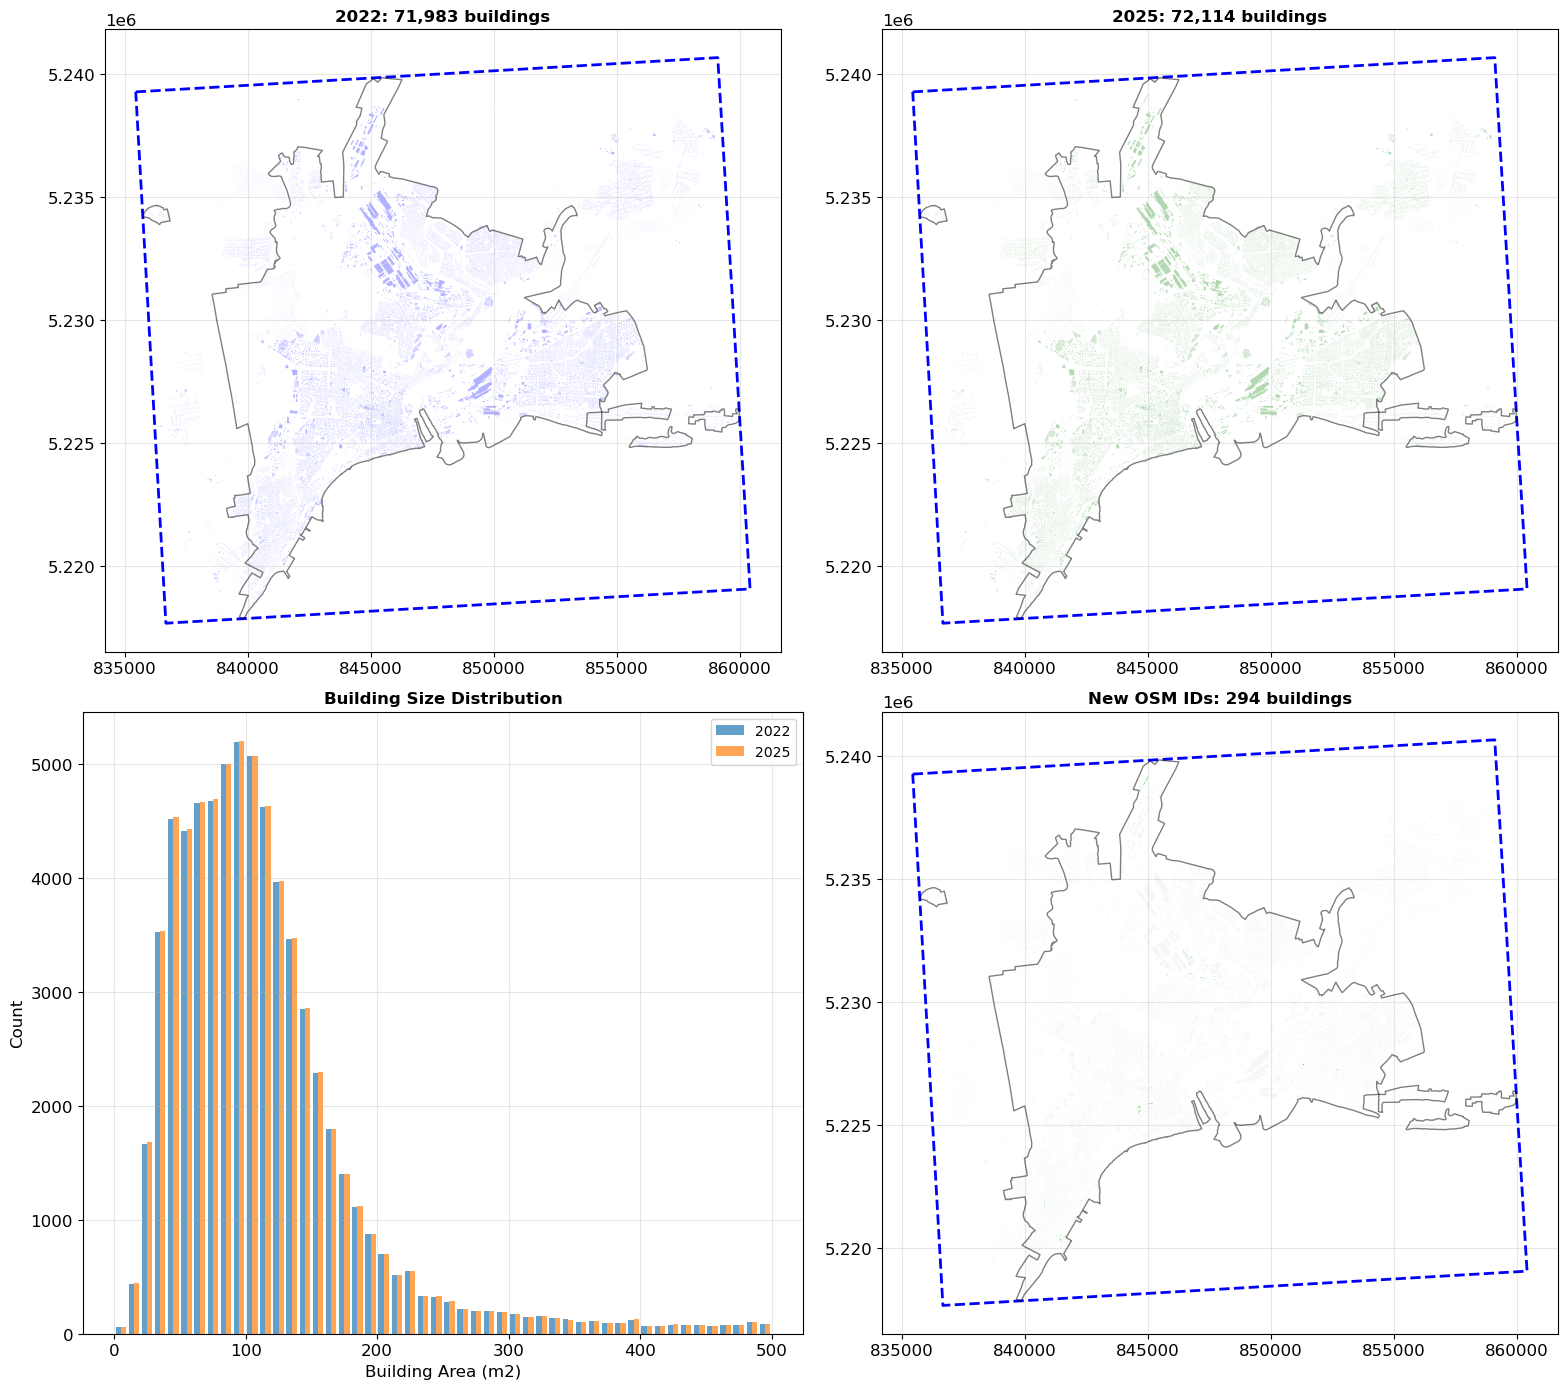


--- ASSESSMENT ---

  Evidence for IMPROVED MAPPING (3):
    - Building count INCREASED (unusual for war-damaged city)
    - Smaller median building size (more detailed mapping)
    - Buildings in previously unmapped grid cells

  CONCLUSION: IMPROVED OSM MAPPING - NOT suitable for damage assessment

  OSM 2022 vs 2025 reflects mapping completeness, NOT real damage.
  Use satellite imagery change detection or UNOSAT assessments instead.

OSM QUALITY ANALYSIS COMPLETE (31.2s)
  Change INSPECT_CITY to analyze a different city


In [24]:
# @title CELL 12: OSM MAPPING QUALITY ANALYSIS
# =============================================================================
# Analyzes whether OSM 2022 vs 2025 differences reflect mapping improvements
# or real building changes. Checks: density, sizes, OSM IDs, vertices, spatial.
# Uses city BBOX (not polygon) for area/density calculations.
# Conclusion: OSM temporal comparison unsuitable for damage assessment.
#
# Requires: Cell 10 (per-city buildings extracted)
# =============================================================================

CELL_ID = "cell_12_osm_quality_analysis"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from datetime import datetime
from shapely.geometry import Point, box
import json

CITIES_DATA_DIR = Path(CITIES_DIR)
CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}_{INSPECT_CITY}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS' and log.get('city') == INSPECT_CITY:
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 12 already run for {INSPECT_CITY} ({previous_log['timestamp'][:10]}). "
          f"Set FORCE_RERUN=True to re-run.")
    findings = previous_log.get('findings', {})
    print(f"  2022: {findings.get('count_2022', '?'):,}, "
          f"2025: {findings.get('count_2025', '?'):,}, "
          f"Change: {findings.get('change_percent', '?')}")
    print(f"  Conclusion: {findings.get('conclusion', '?')}")
    print(f"\n  Change INSPECT_CITY to analyze a different city")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print(f"ANALYZING OSM MAPPING QUALITY: {INSPECT_CITY}")
    print("=" * 70)

    inspect_city = INSPECT_CITY
    city_dir = CITIES_DATA_DIR / inspect_city

    if not city_dir.exists():
        raise FileNotFoundError(f"City directory not found: {city_dir}")

    buildings_2022 = gpd.read_file(city_dir / "buildings_2022.geojson")
    buildings_2025 = gpd.read_file(city_dir / "buildings_2025.geojson")

    count_2022 = len(buildings_2022)
    count_2025 = len(buildings_2025)
    count_increase = count_2025 - count_2022
    pct_increase = (count_increase / count_2022 * 100) if count_2022 > 0 else 0

    print(f"\n  2022: {count_2022:,}, 2025: {count_2025:,}, Change: {count_increase:+,} ({pct_increase:+.1f}%)")

    # ========================================================================
    # CHECK 1: SPATIAL DISTRIBUTION / DENSITY
    # ========================================================================

    print(f"\n--- CHECK 1: DENSITY ---")

    buildings_2022_utm = buildings_2022.to_crs('EPSG:32636')
    buildings_2025_utm = buildings_2025.to_crs('EPSG:32636')

    boundary = gpd.read_file(city_dir / "boundary.geojson")
    city_bbox = box(*boundary.geometry.unary_union.bounds)
    city_bbox_gdf = gpd.GeoDataFrame(geometry=[city_bbox], crs=boundary.crs).to_crs('EPSG:32636')
    boundary = boundary.to_crs('EPSG:32636')
    bbox_area_km2 = city_bbox_gdf.geometry.area.sum() / 1_000_000
    area_km2 = bbox_area_km2

    density_2022 = count_2022 / area_km2
    density_2025 = count_2025 / area_km2

    print(f"  BBOX area: {bbox_area_km2:.2f} km2")
    print(f"  2022: {density_2022:.1f} bldg/km2, 2025: {density_2025:.1f} bldg/km2")

    # ========================================================================
    # CHECK 2: BUILDING SIZES
    # ========================================================================

    print(f"\n--- CHECK 2: BUILDING SIZES ---")

    areas_2022 = buildings_2022_utm.geometry.area
    areas_2025 = buildings_2025_utm.geometry.area

    area_2022_mean = areas_2022.mean()
    area_2022_median = areas_2022.median()
    area_2025_mean = areas_2025.mean()
    area_2025_median = areas_2025.median()

    print(f"  2022: mean={area_2022_mean:.1f} m2, median={area_2022_median:.1f} m2")
    print(f"  2025: mean={area_2025_mean:.1f} m2, median={area_2025_median:.1f} m2")

    smaller_median = area_2025_median < area_2022_median
    if smaller_median:
        print(f"  -> 2025 has SMALLER median (more detailed mapping of small structures)")

    # ========================================================================
    # CHECK 3: OSM ID OVERLAP
    # ========================================================================

    print(f"\n--- CHECK 3: OSM ID OVERLAP ---")

    osm_id_cols = [col for col in buildings_2022.columns
                   if 'osm' in col.lower() and 'id' in col.lower()]

    common_ids_count = 0
    only_2022_count = 0
    only_2025_count = 0
    high_new_ids = False
    only_2025 = set()

    if osm_id_cols:
        id_col = osm_id_cols[0]
        ids_2022 = set(buildings_2022[id_col].dropna().astype(str))
        ids_2025 = set(buildings_2025[id_col].dropna().astype(str))

        common_ids = ids_2022 & ids_2025
        only_2022_ids = ids_2022 - ids_2025
        only_2025 = ids_2025 - ids_2022

        common_ids_count = len(common_ids)
        only_2022_count = len(only_2022_ids)
        only_2025_count = len(only_2025)

        print(f"  Using: {id_col}")
        print(f"  Common: {common_ids_count:,} ({common_ids_count/len(ids_2022)*100:.1f}%)")
        print(f"  Only 2022: {only_2022_count:,} ({only_2022_count/len(ids_2022)*100:.1f}%)")
        print(f"  Only 2025: {only_2025_count:,} ({only_2025_count/len(ids_2025)*100:.1f}%)")

        high_new_ids = (only_2025_count / len(ids_2025)) > 0.3
        if high_new_ids:
            print(f"  -> >30% new IDs = significant new mapping activity")
    else:
        print(f"  No OSM ID column found")
        id_col = None

    # ========================================================================
    # CHECK 4: GEOMETRY COMPLEXITY
    # ========================================================================

    print(f"\n--- CHECK 4: VERTEX COUNT ---")

    def count_vertices(geom):
        if geom.geom_type == 'Polygon':
            return len(geom.exterior.coords)
        elif geom.geom_type == 'MultiPolygon':
            return sum(len(p.exterior.coords) for p in geom.geoms)
        return 0

    vertices_2022 = buildings_2022.geometry.apply(count_vertices)
    vertices_2025 = buildings_2025.geometry.apply(count_vertices)

    vert_2022_mean = vertices_2022.mean()
    vert_2025_mean = vertices_2025.mean()

    print(f"  2022: {vert_2022_mean:.1f} vertices/building")
    print(f"  2025: {vert_2025_mean:.1f} vertices/building")

    more_vertices = vert_2025_mean > vert_2022_mean
    if more_vertices:
        print(f"  -> More vertices = better digitization quality")

    # ========================================================================
    # CHECK 5: SPATIAL GRID
    # ========================================================================

    print(f"\n--- CHECK 5: SPATIAL GRID ---")

    def grid_cell(point, cell_size=0.01):
        return (int(point.x / cell_size), int(point.y / cell_size))

    centroids_2022 = buildings_2022.geometry.centroid
    centroids_2025 = buildings_2025.geometry.centroid

    cells_2022 = centroids_2022.apply(lambda p: grid_cell(p))
    cells_2025 = centroids_2025.apply(lambda p: grid_cell(p))

    unique_cells_2022 = set(cells_2022)
    unique_cells_2025 = set(cells_2025)
    new_cells = unique_cells_2025 - unique_cells_2022

    print(f"  2022 cells: {len(unique_cells_2022)}, 2025 cells: {len(unique_cells_2025)}")
    print(f"  New cells: {len(new_cells)}")

    has_new_cells = len(new_cells) > 0
    if has_new_cells:
        print(f"  -> Buildings in previously unmapped areas")

    # ========================================================================
    # VISUALIZATION
    # ========================================================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Panel 1: 2022
    ax1 = axes[0, 0]
    city_bbox_gdf.boundary.plot(ax=ax1, color='blue', linewidth=2, linestyle='--')
    boundary.boundary.plot(ax=ax1, color='black', linewidth=1, alpha=0.5)
    buildings_2022_utm.plot(ax=ax1, color='blue', markersize=1, alpha=0.3)
    ax1.set_title(f'2022: {count_2022:,} buildings', fontsize=12, fontweight='bold')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    # Panel 2: 2025
    ax2 = axes[0, 1]
    city_bbox_gdf.boundary.plot(ax=ax2, color='blue', linewidth=2, linestyle='--')
    boundary.boundary.plot(ax=ax2, color='black', linewidth=1, alpha=0.5)
    buildings_2025_utm.plot(ax=ax2, color='green', markersize=1, alpha=0.3)
    ax2.set_title(f'2025: {count_2025:,} buildings', fontsize=12, fontweight='bold')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    # Panel 3: Size distribution
    ax3 = axes[1, 0]
    ax3.hist([areas_2022, areas_2025], bins=50, label=['2022', '2025'],
             alpha=0.7, range=(0, 500))
    ax3.set_xlabel('Building Area (m2)')
    ax3.set_ylabel('Count')
    ax3.set_title('Building Size Distribution', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Panel 4: New buildings
    ax4 = axes[1, 1]
    city_bbox_gdf.boundary.plot(ax=ax4, color='blue', linewidth=2, linestyle='--')
    boundary.boundary.plot(ax=ax4, color='black', linewidth=1, alpha=0.5)
    buildings_2022_utm.plot(ax=ax4, color='lightgray', markersize=1, alpha=0.2)

    if only_2025_count > 0 and id_col:
        new_buildings = buildings_2025_utm[buildings_2025[id_col].astype(str).isin(only_2025)]
        new_buildings.plot(ax=ax4, color='limegreen', markersize=2, alpha=0.8)
        ax4.set_title(f'New OSM IDs: {len(new_buildings):,} buildings', fontsize=12, fontweight='bold')
    else:
        ax4.set_title('Cannot identify new buildings (no OSM IDs)', fontsize=12, fontweight='bold')
    ax4.set_aspect('equal')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()

    fig_path = CELL_IMAGE_DIR / f"{inspect_city}_osm_quality_analysis.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"\n  Saved: {fig_path}")
    plt.show()
    plt.close()

    # ========================================================================
    # ASSESSMENT
    # ========================================================================

    print(f"\n--- ASSESSMENT ---")

    evidence_mapping = []
    if count_increase > 0:
        evidence_mapping.append("Building count INCREASED (unusual for war-damaged city)")
    if high_new_ids:
        evidence_mapping.append(">30% buildings have new OSM IDs (new mapping)")
    if smaller_median:
        evidence_mapping.append("Smaller median building size (more detailed mapping)")
    if more_vertices:
        evidence_mapping.append("More complex building shapes (better digitization)")
    if has_new_cells:
        evidence_mapping.append("Buildings in previously unmapped grid cells")

    print(f"\n  Evidence for IMPROVED MAPPING ({len(evidence_mapping)}):")
    for item in evidence_mapping:
        print(f"    - {item}")

    if len(evidence_mapping) >= 3:
        conclusion = "IMPROVED OSM MAPPING - NOT suitable for damage assessment"
        print(f"\n  CONCLUSION: {conclusion}")
        print(f"\n  OSM 2022 vs 2025 reflects mapping completeness, NOT real damage.")
        print(f"  Use satellite imagery change detection or UNOSAT assessments instead.")
    else:
        conclusion = "Mixed evidence - manual verification recommended"
        print(f"\n  CONCLUSION: {conclusion}")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'city': inspect_city,
        'findings': {
            'count_2022': count_2022,
            'count_2025': count_2025,
            'change_count': count_increase,
            'change_percent': f"+{pct_increase:.1f}%",
            'bbox_area_km2': float(bbox_area_km2),
            'density_2022': float(density_2022),
            'density_2025': float(density_2025),
            'area_2022_median': float(area_2022_median),
            'area_2025_median': float(area_2025_median),
            'vertices_2022_mean': float(vert_2022_mean),
            'vertices_2025_mean': float(vert_2025_mean),
            'common_ids': common_ids_count,
            'only_2025_ids': only_2025_count,
            'new_cells': len(new_cells),
            'evidence_mapping': evidence_mapping,
            'conclusion': conclusion
        },
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"OSM QUALITY ANALYSIS COMPLETE ({duration:.1f}s)")
    print(f"  Change INSPECT_CITY to analyze a different city")
    print(f"{'='*70}")

# CELL 13: DOWNLOAD UNOSAT UKRAINE DAMAGE ASSESSMENTS

In [25]:
# @title CELL 13: DOWNLOAD UNOSAT UKRAINE DAMAGE ASSESSMENTS
# =============================================================================
# Downloads UNOSAT damage assessment data from HDX (Humanitarian Data Exchange).
# Searches for Ukraine-specific building damage shapefiles/geojson.
# Output: UNOSAT_DIR/raw/ with .zip, .geojson, .shp files
#
# Requires: Cell 4+4A (paths), internet access
# =============================================================================

CELL_ID = "cell_13_download_unosat"
FORCE_RERUN = True

import requests
from pathlib import Path
import pandas as pd
import json
import time
from datetime import datetime

UNOSAT_DIR = Path(DATA_ROOT) / "unosat_damage_assessments"
UNOSAT_RAW_DIR = UNOSAT_DIR / "raw"
UNOSAT_RAW_DIR.mkdir(parents=True, exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

UKRAINE_BOUNDS = {
    'lat_min': 44.0, 'lat_max': 53.0,
    'lon_min': 22.0, 'lon_max': 41.0
}

# ============================================================================
# HELPERS
# ============================================================================

def get_existing_files():
    existing = []
    for f in UNOSAT_RAW_DIR.glob("*"):
        if f.is_file() and f.suffix in ['.zip', '.geojson', '.shp', '.json']:
            existing.append({
                'filename': f.name,
                'path': str(f),
                'size_mb': f.stat().st_size / (1024**2)
            })
    return existing

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run and not CHECK_FOR_NEW:
    print(f"CELL 13 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Files: {previous_log.get('total_files', 0)}, "
          f"Size: {previous_log.get('total_size_mb', 0):.1f} MB")

    existing_files = get_existing_files()
    if existing_files:
        print(f"  {len(existing_files)} files in {UNOSAT_RAW_DIR}")

    log_file = UNOSAT_RAW_DIR / "download_log.csv"
    if log_file.exists():
        log_df = pd.read_csv(log_file)
        print(f"  Datasets: {log_df['dataset'].nunique()}, Formats: {log_df['format'].value_counts().to_dict()}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("DOWNLOADING UNOSAT UKRAINE DAMAGE ASSESSMENTS")
    print("=" * 70)
    print(f"  Output: {UNOSAT_RAW_DIR}")
    print(f"  Ukraine only: {UKRAINE_ONLY}")

    existing_files = get_existing_files()
    existing_filenames = {f['filename'] for f in existing_files}

    if existing_files and not FORCE_RERUN:
        print(f"\n  Existing: {len(existing_files)} files ({sum(f['size_mb'] for f in existing_files):.1f} MB)")
        if CHECK_FOR_NEW:
            print(f"  Will download only new files")

    # ========================================================================
    # HDX API SEARCH
    # ========================================================================

    HDX_BASE = "https://data.humdata.org"
    HDX_API = f"{HDX_BASE}/api/3/action"

    search_query = "unosat ukraine damage building" if UKRAINE_ONLY else "unosat damage"
    print(f"\n  Searching HDX: '{search_query}'")

    datasets = []
    damage_datasets = []
    api_success = False
    all_files = []
    downloaded_files = []
    skipped_files = []
    failed_files = []

    try:
        response = requests.get(
            f"{HDX_API}/package_search",
            params={'q': search_query, 'rows': 100, 'fq': 'organization:unosat'},
            timeout=30
        )

        if response.status_code == 200:
            results = response.json()
            datasets = results['result']['results']
            print(f"  Found {len(datasets)} UNOSAT datasets")

            for ds in datasets:
                title_lower = ds['title'].lower()
                notes_lower = ds.get('notes', '').lower()

                is_damage = any(kw in title_lower or kw in notes_lower
                               for kw in ['damage', 'building', 'structure', 'destruction'])

                is_ukraine = True
                if UKRAINE_ONLY:
                    is_ukraine = any(kw in title_lower or kw in notes_lower
                                   for kw in ['ukraine', 'ukrainian', 'mariupol',
                                              'kharkiv', 'kherson', 'kyiv'])

                if is_damage and is_ukraine:
                    damage_datasets.append({
                        'name': ds['name'],
                        'title': ds['title'],
                        'num_resources': len(ds.get('resources', [])),
                        'metadata_modified': ds.get('metadata_modified', 'Unknown'),
                        'dataset': ds
                    })

            print(f"  Ukraine damage datasets: {len(damage_datasets)}")

            if damage_datasets:
                print(f"\n  Available datasets:")
                for i, ds_info in enumerate(damage_datasets, 1):
                    print(f"    {i}. {ds_info['title']} ({ds_info['num_resources']} resources)")

            # =================================================================
            # DOWNLOAD FILES
            # =================================================================

            print(f"\nDownloading files...")

            for ds_info in damage_datasets:
                ds = ds_info['dataset']
                resources = ds.get('resources', [])

                for resource in resources:
                    format_type = resource.get('format', '').lower()
                    url = resource.get('url', '')
                    name = resource.get('name', 'unnamed')

                    if format_type in ['shp', 'shapefile', 'geojson', 'json', 'zip', 'zipped shapefile']:
                        try:
                            safe_name = "".join(c for c in name if c.isalnum() or c in (' ', '-', '_', '.')).strip()
                            if not safe_name:
                                safe_name = f"unosat_{resource['id']}"

                            if format_type in ['shp', 'shapefile', 'zipped shapefile', 'zip']:
                                if not safe_name.endswith('.zip'):
                                    safe_name += '.zip'
                            elif format_type in ['geojson', 'json']:
                                if not safe_name.endswith('.geojson'):
                                    safe_name += '.geojson'

                            output_file = UNOSAT_RAW_DIR / safe_name

                            if output_file.exists() and not FORCE_RERUN:
                                file_size = output_file.stat().st_size / (1024**2)
                                skipped_files.append({
                                    'filename': output_file.name, 'path': str(output_file),
                                    'size_mb': file_size, 'format': format_type,
                                    'dataset': ds_info['title']
                                })
                                continue

                            print(f"  Downloading: {safe_name}...")
                            file_response = requests.get(url, timeout=120, stream=True)

                            if file_response.status_code == 200:
                                with open(output_file, 'wb') as f:
                                    for chunk in file_response.iter_content(chunk_size=8192):
                                        f.write(chunk)

                                file_size = output_file.stat().st_size / (1024**2)
                                print(f"    {file_size:.2f} MB")

                                downloaded_files.append({
                                    'filename': output_file.name, 'path': str(output_file),
                                    'size_mb': file_size, 'format': format_type,
                                    'dataset': ds_info['title']
                                })
                            else:
                                print(f"    FAILED: HTTP {file_response.status_code}")
                                failed_files.append({'name': name, 'reason': f"HTTP {file_response.status_code}"})

                        except Exception as e:
                            print(f"    ERROR: {e}")
                            failed_files.append({'name': name, 'reason': str(e)})

                        time.sleep(1)

            all_files = downloaded_files + skipped_files
            api_success = True

            if all_files:
                log_df = pd.DataFrame(all_files)
                log_df.to_csv(UNOSAT_RAW_DIR / "download_log.csv", index=False)

        else:
            print(f"  ERROR: HDX API returned {response.status_code}")

    except Exception as e:
        print(f"  ERROR connecting to HDX: {e}")

    # ========================================================================
    # MANUAL DOWNLOAD INSTRUCTIONS (if API failed or no data)
    # ========================================================================

    if not api_success or (UKRAINE_ONLY and len(damage_datasets) == 0):
        print(f"\n  ALTERNATIVE: Manual download sources:")
        print(f"    HDX:        https://data.humdata.org/organization/unosat?q=ukraine")
        print(f"    UNOSAT:     https://unosat.org/products/?search=ukraine")
        print(f"    ReliefWeb:  https://reliefweb.int/updates?advanced-search=%28PC251%29_%28F10%29")
        print(f"    Copernicus: https://emergency.copernicus.eu/mapping/list-of-activations-rapid")
        print(f"\n  Save to: {UNOSAT_RAW_DIR}")

    # ========================================================================
    # SUMMARY + LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"UNOSAT DOWNLOAD COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Datasets found: {len(damage_datasets)}")
    print(f"  Downloaded: {len(downloaded_files)}, Skipped: {len(skipped_files)}, Failed: {len(failed_files)}")
    if all_files:
        print(f"  Total: {len(all_files)} files, {sum(f['size_mb'] for f in all_files):.1f} MB")

    if failed_files:
        print(f"\n  Failed:")
        for f in failed_files[:5]:
            print(f"    - {f['name']}: {f['reason']}")

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'ukraine_only': UKRAINE_ONLY,
        'api_success': api_success,
        'datasets_found': len(damage_datasets),
        'files_downloaded': len(downloaded_files),
        'files_skipped': len(skipped_files),
        'files_failed': len(failed_files),
        'total_files': len(all_files),
        'total_size_mb': sum(f['size_mb'] for f in all_files) if all_files else 0,
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n  Next: Run Cell 14 to extract and organize UNOSAT data by city")
    print(f"{'='*70}")

DOWNLOADING UNOSAT UKRAINE DAMAGE ASSESSMENTS
  Output: /content/drive_f/masterthesis/data/unosat_damage_assessments/raw
  Ukraine only: True

  Searching HDX: 'unosat ukraine damage building'
  Found 100 UNOSAT datasets
  Ukraine damage datasets: 14

  Available datasets:
    1. UNOSAT Damage Assessment Overview Map - Livoberezhnyi and Zhovtnevyi Districts, Mariupol City, Ukraine (2 resources)
    2. Mariupol Updated Building Damage Assessment Overview Map - Livoberezhnyi and Zhovtnevyi Districts (2 resources)
    3. Kremenchuk Damage Assessment Overview (2 resources)
    4. Mariupol Rapid Damage Assessment Overview Map (2 resources)
    5. Sumy Rapid Damage Assessment Overview Map (3 resources)
    6. North Kharkiv Rapid Damage Assessment Overview Map (3 resources)
    7. Damage assessment around the Nova Kakhova Dam, Ukraine as of 06 June 2023; 08:07 UTC (2 resources)
    8. Damage assessment over Kherson City, Khersonskyi Region, Khersonska Oblast, Ukraine as of 17 June 2023. (2 re

 # CELL 14: INSPECT DOWNLOADED UNOSAT FILES

In [26]:
# @title CELL 14: INSPECT DOWNLOADED UNOSAT FILES
# =============================================================================
# Checks what was downloaded by Cell 13 / manually placed Dietrich files,
# inspects shapefiles and geojson for damage columns,
# identifies building vs flood datasets, shows damage distribution.
#
# Requires: Cell 4+4A (paths), UNOSAT files in raw/
# =============================================================================
CELL_ID = "cell_14_inspect_unosat"
import geopandas as gpd
import pandas as pd
from pathlib import Path
print("=" * 70)
print("CHECKING DOWNLOADED UNOSAT FILES")
print("=" * 70)
all_files = []
for f in UNOSAT_RAW_DIR.glob("**/*"):
    if f.is_file():
        all_files.append({
            'name': f.name,
            'path': str(f.relative_to(UNOSAT_RAW_DIR)),
            'size_mb': f.stat().st_size / (1024**2),
            'extension': f.suffix
        })
if all_files:
    print(f"\n  Found {len(all_files)} files:")
    df = pd.DataFrame(all_files)
    print(df.to_string(index=False))

    # ========================================================================
    # INSPECT GEOJSON FILES (Dietrich unosat_labels + unosat_aois)
    # ========================================================================

    geojson_files = [f for f in all_files if f['extension'] == '.geojson']
    if geojson_files:
        print(f"\n\n{'='*70}")
        print(f"GEOJSON FILES ({len(geojson_files)})")
        print(f"{'='*70}")
        for gj in geojson_files:
            gj_path = UNOSAT_RAW_DIR / gj['path']
            print(f"\n{'='*70}")
            print(f"File: {gj['name']} ({gj['size_mb']:.2f} MB)")
            try:
                gdf = gpd.read_file(gj_path)
                print(f"  Features: {len(gdf):,}")
                print(f"  CRS: {gdf.crs}")
                print(f"  Geometry: {gdf.geometry.type.value_counts().to_dict()}")
                print(f"  Columns ({len(gdf.columns)}): {list(gdf.columns)}")

                # bounds
                bounds = gdf.total_bounds
                print(f"  Bounds: lon [{bounds[0]:.4f}, {bounds[2]:.4f}], lat [{bounds[1]:.4f}, {bounds[3]:.4f}]")

                # all columns: dtype + nunique + sample values
                print(f"\n  Column details:")
                for col in gdf.columns:
                    if col == 'geometry':
                        continue
                    dtype = gdf[col].dtype
                    non_null = gdf[col].notna().sum()
                    nunique = gdf[col].nunique()
                    print(f"    {col:30s}  dtype={str(dtype):10s}  non_null={non_null:,}/{len(gdf):,}  nunique={nunique}")
                    # value counts for categorical / low-cardinality columns
                    if nunique <= 20:
                        vc = gdf[col].value_counts(dropna=False).head(20)
                        for val, count in vc.items():
                            val_str = str(val) if pd.notna(val) else "NaN"
                            pct = (count / len(gdf)) * 100
                            print(f"      {val_str:40s}: {count:6,} ({pct:5.1f}%)")
                    else:
                        # show first 5 sample values
                        samples = gdf[col].dropna().head(5).tolist()
                        print(f"      samples: {samples}")

                # damage-related columns
                damage_cols = [col for col in gdf.columns
                              if any(kw in col.lower()
                                    for kw in ['damage', 'damag', 'class', 'grade', 'destroyed',
                                               'severity', 'level', 'label', 'status'])]
                if damage_cols:
                    print(f"\n  Damage-related columns: {damage_cols}")

                # building indicators
                building_cols = [col for col in gdf.columns
                                if any(kw in col.lower()
                                      for kw in ['building', 'structure', 'main_damag'])]
                if building_cols:
                    print(f"  Building-related columns: {building_cols}")

                # flood indicators
                flood_cols = [col for col in gdf.columns
                             if any(kw in col.lower()
                                   for kw in ['flood', 'water', 'inundation'])]
                if flood_cols:
                    print(f"  WARNING - FLOOD INDICATORS: {flood_cols}")

                # AOI-specific: check if this is an AOI boundaries file
                if len(gdf) < 50 and any(kw in gj['name'].lower() for kw in ['aoi', 'area']):
                    print(f"\n  Likely AOI boundaries file ({len(gdf)} regions)")
                    if 'name' in gdf.columns:
                        print(f"  AOI names: {gdf['name'].tolist()}")
                    elif 'aoi_name' in gdf.columns:
                        print(f"  AOI names: {gdf['aoi_name'].tolist()}")

            except Exception as e:
                print(f"  ERROR loading: {e}")

    # ========================================================================
    # INSPECT SHAPEFILES (legacy HDX downloads)
    # ========================================================================

    shapefiles = [f for f in all_files if f['extension'] == '.shp']
    if shapefiles:
        print(f"\n\n{'='*70}")
        print(f"SHAPEFILES ({len(shapefiles)})")
        print(f"{'='*70}")
        for shp in shapefiles:
            shp_path = UNOSAT_RAW_DIR / shp['path']
            print(f"\n{'='*70}")
            print(f"File: {shp['name']} ({shp['size_mb']:.2f} MB)")
            try:
                gdf = gpd.read_file(shp_path)
                print(f"  Features: {len(gdf):,}")
                print(f"  Geometry: {gdf.geometry.type.value_counts().to_dict()}")
                print(f"  Columns ({len(gdf.columns)}): {', '.join(list(gdf.columns)[:10])}...")
                # damage columns
                damage_cols = [col for col in gdf.columns
                              if any(kw in col.lower()
                                    for kw in ['damage', 'damag', 'class', 'grade', 'destroyed'])]
                if damage_cols:
                    print(f"  Damage columns: {', '.join(damage_cols)}")
                    for col in damage_cols[:3]:
                        print(f"    {col}: {gdf[col].value_counts().to_dict()}")
                # flood indicators
                flood_indicators = [col for col in gdf.columns
                                  if any(kw in col.lower()
                                        for kw in ['flood', 'water', 'inundation'])]
                if flood_indicators:
                    print(f"  WARNING - FLOOD INDICATORS: {', '.join(flood_indicators)}")
                # building damage indicators
                building_indicators = [col for col in gdf.columns
                                      if any(kw in col.lower()
                                            for kw in ['building', 'structure', 'main_damag'])]
                if building_indicators:
                    print(f"  BUILDING DAMAGE: {', '.join(building_indicators)}")
                    if 'Main_Damag' in gdf.columns:
                        print(f"\n  Main_Damag distribution:")
                        main_dist = gdf['Main_Damag'].value_counts().sort_index()
                        for val, count in main_dist.items():
                            print(f"    {val}: {count}")
            except Exception as e:
                print(f"  ERROR loading: {e}")

else:
    print(f"\n  No files found in {UNOSAT_RAW_DIR}")
    print(f"  Run Cell 13 first or place Dietrich files manually.")

# download log (from Cell 13, may not exist if files placed manually)
log_file = UNOSAT_RAW_DIR / "download_log.csv"
if log_file.exists():
    print(f"\n{'='*70}")
    print(f"DOWNLOAD LOG:")
    print(f"{'='*70}")
    log_df = pd.read_csv(log_file)
    print(f"\n  Datasets: {log_df['dataset'].unique()}")
    print(f"\n  Files:")
    print(log_df[['filename', 'format', 'dataset']].to_string(index=False))

print(f"\n{'='*70}")
print(f"CELL 14 COMPLETE")
print(f"{'='*70}")

CHECKING DOWNLOADED UNOSAT FILES

  Found 792 files:
                                                                                           name                                                                                                                                path    size_mb   extension
                                                                          CE20140715PSE.gdb.zip                                                                                                               CE20140715PSE.gdb.zip   3.265783        .zip
                                                                          CE20140715PSE.shp.zip                                                                                                               CE20140715PSE.shp.zip   9.916420        .zip
                                                            CE20220223UKR_UNOSAT_Damage_shp.zip                                                                                                 CE

# CELL 15: EXTRACT UNOSAT DAMAGE DATA PER CITY

In [27]:
# @title CELL 15: EXTRACT UNOSAT DAMAGE DATA PER CITY
# =============================================================================
# Loads Dietrich compiled UNOSAT labels (unosat_labels.geojson, 18,686 points),
# spatial-joins to each city extent, saves per-city GeoJSON + metadata.
# CLIP_MODE controls spatial extraction: "bbox" or "polygon".
# Also loads original Mariupol shapefile for comparison if available.
# Output: UNOSAT_CITIES_DIR/{city}/unosat_damage.geojson, unosat_metadata.json
#
# Requires: Cell 8 (bda_city_boundaries.geojson), Cell 13/14 (UNOSAT download)
# =============================================================================

CELL_ID = "cell_15_extract_unosat_cities"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
from datetime import datetime
from shapely.geometry import box

UNOSAT_CITIES_DIR.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

assert CLIP_MODE in ("bbox", "polygon"), f"CLIP_MODE must be 'bbox' or 'polygon', got '{CLIP_MODE}'"

# Dietrich damage code mapping (from compiled GDB inspection)
# Codes observed: 1,2,3,4,5,6,7,15
DAMAGE_CODE_MAP = {
    1: 'Possibly Damaged',
    2: 'Moderately Damaged',
    3: 'Severely Damaged',
    4: 'Destroyed',
    5: 'Impact Crater',
    6: 'No Visible Damage',
    7: 'No Visible Damage',
    15: 'Unknown'
}

# Binary label for ML: damaged (destroyed + severely damaged) vs undamaged
# Following Dietrich 2025 who merges destroyed+severely into "damaged"
DAMAGE_BINARY_MAP = {
    1: 0,  # Possibly Damaged -> undamaged
    2: 0,  # Moderately Damaged -> undamaged
    3: 1,  # Severely Damaged -> damaged
    4: 1,  # Destroyed -> damaged
    5: -1, # Impact Crater -> exclude
    6: 0,  # No Visible Damage -> undamaged
    7: 0,  # No Visible Damage -> undamaged
    15: -1 # Unknown -> exclude
}

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 15 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities with data: {previous_log.get('cities_with_data', '?')}, "
          f"Features: {previous_log.get('total_features', '?'):,}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print(f"EXTRACTING UNOSAT BUILDING DAMAGE DATA PER CITY (CLIP_MODE={CLIP_MODE})")
    print("=" * 70)

    # Load city boundaries
    city_boundaries_file = Path(DATA_ROOT) / "bda_city_boundaries.geojson"
    cities_gdf = gpd.read_file(city_boundaries_file)
    print(f"  Loaded {len(cities_gdf)} city boundaries, CRS={cities_gdf.crs}")

    # ========================================================================
    # LOAD DIETRICH COMPILED LABELS (PRIMARY SOURCE)
    # ========================================================================

    dietrich_labels_file = UNOSAT_RAW_DIR / "unosat_labels.geojson"
    dietrich_aois_file = UNOSAT_RAW_DIR / "unosat_aois.geojson"

    if not dietrich_labels_file.exists():
        raise FileNotFoundError(f"Dietrich compiled labels not found: {dietrich_labels_file}")

    print(f"\n  Loading Dietrich compiled UNOSAT labels...")
    unosat_all = gpd.read_file(dietrich_labels_file)
    print(f"  Loaded {len(unosat_all):,} features, CRS={unosat_all.crs}")
    print(f"  Columns: {list(unosat_all.columns)}")
    print(f"  AOIs: {unosat_all['aoi'].nunique()} unique ({unosat_all['aoi'].value_counts().to_dict()})")

    # Add mapped damage columns
    unosat_all['damage_label'] = unosat_all['damage'].map(DAMAGE_CODE_MAP)
    unosat_all['damage_binary'] = unosat_all['damage'].map(DAMAGE_BINARY_MAP)

    print(f"\n  Damage code distribution:")
    for code, count in unosat_all['damage'].value_counts().sort_index().items():
        label = DAMAGE_CODE_MAP.get(code, '?')
        binary = DAMAGE_BINARY_MAP.get(code, '?')
        print(f"    {code:3d} = {label:25s} (binary={binary:2d}): {count:,}")

    n_damaged = (unosat_all['damage_binary'] == 1).sum()
    n_undamaged = (unosat_all['damage_binary'] == 0).sum()
    n_excluded = (unosat_all['damage_binary'] == -1).sum()
    print(f"\n  Binary split: damaged={n_damaged:,}, undamaged={n_undamaged:,}, excluded={n_excluded:,}")

    # Load AOI boundaries for reference
    if dietrich_aois_file.exists():
        aois_gdf = gpd.read_file(dietrich_aois_file)
        print(f"  Loaded {len(aois_gdf)} AOI boundaries")
    else:
        aois_gdf = None
        print(f"  WARNING: AOI boundaries not found")

    # ========================================================================
    # LOAD ORIGINAL MARIUPOL SHAPEFILE (COMPARISON)
    # ========================================================================

    mariupol_original = None
    for shp_file in UNOSAT_RAW_DIR.glob("**/*Damage_Point*No_Military*.shp"):
        print(f"\n  Found original Mariupol shapefile: {shp_file.name}")
        mariupol_original = gpd.read_file(shp_file)
        print(f"  Original Mariupol: {len(mariupol_original):,} features")
        if 'Main_Damag' in mariupol_original.columns:
            print(f"  Main_Damag distribution: {mariupol_original['Main_Damag'].value_counts().sort_index().to_dict()}")
        break

    # Reproject to match city boundaries
    if unosat_all.crs != cities_gdf.crs:
        print(f"\n  Reprojecting from {unosat_all.crs} to {cities_gdf.crs}...")
        unosat_all = unosat_all.to_crs(cities_gdf.crs)
    if mariupol_original is not None and mariupol_original.crs != cities_gdf.crs:
        mariupol_original = mariupol_original.to_crs(cities_gdf.crs)

    # ========================================================================
    # EXTRACT PER CITY
    # ========================================================================

    print(f"\nExtracting per city...")

    city_extractions = []

    for idx, city_row in cities_gdf.iterrows():
        city_name = city_row['city_name']
        city_dir = UNOSAT_CITIES_DIR / city_name
        city_dir.mkdir(exist_ok=True)

        try:
            if CLIP_MODE == "bbox":
                clip_geom = box(*city_row.geometry.bounds)
            else:
                clip_geom = city_row.geometry
            clip_gdf = gpd.GeoDataFrame(geometry=[clip_geom], crs=cities_gdf.crs)

            city_damage = gpd.sjoin(unosat_all, clip_gdf, how='inner', predicate='within')
            city_damage = city_damage[[col for col in city_damage.columns if not col.startswith('index_')]]

            count = len(city_damage)

            if count > 0:
                city_damage.to_file(city_dir / "unosat_damage.geojson", driver='GeoJSON')
                # Always save the original polygon boundary for reference
                city_gdf_temp = gpd.GeoDataFrame([city_row], crs=cities_gdf.crs)
                city_gdf_temp.to_file(city_dir / "boundary.geojson", driver='GeoJSON')

                n_dam = (city_damage['damage_binary'] == 1).sum()
                n_undam = (city_damage['damage_binary'] == 0).sum()
                n_excl = (city_damage['damage_binary'] == -1).sum()
                aois_present = city_damage['aoi'].unique().tolist()
                epochs = city_damage['ep'].unique().tolist()

                print(f"  {city_name:25s}: {count:,} features "
                      f"(damaged={n_dam}, undamaged={n_undam}, excluded={n_excl}) "
                      f"AOIs={aois_present}")

                # Mariupol comparison
                mariupol_comparison = None
                if city_name == 'Mariupol' and mariupol_original is not None:
                    mar_sjoin = gpd.sjoin(mariupol_original, clip_gdf, how='inner', predicate='within')
                    mariupol_comparison = {
                        'original_shapefile_count': len(mar_sjoin),
                        'dietrich_compiled_count': count,
                        'clip_mode': CLIP_MODE,
                        'note': 'Dietrich compiled includes multiple assessment epochs and Livoberezhnyy district'
                    }
                    print(f"    -> Mariupol comparison: original={len(mar_sjoin)}, dietrich={count}")

                metadata = {
                    'city_name': city_name,
                    'oblast': city_row['oblast'],
                    'tier': int(city_row['tier']),
                    'priority': int(city_row['priority']),
                    'clip_mode': CLIP_MODE,
                    'damage_features': int(count),
                    'n_damaged': int(n_dam),
                    'n_undamaged': int(n_undam),
                    'n_excluded': int(n_excl),
                    'aois': aois_present,
                    'epochs': [int(e) for e in epochs],
                    'damage_distribution': city_damage['damage'].value_counts().sort_index().to_dict(),
                    'source': 'dietrich_compiled_unosat_labels',
                    'source_file': dietrich_labels_file.name,
                    'columns': list(city_damage.columns),
                    'geometry_type': 'Point',
                    'extracted_date': datetime.now().isoformat(),
                    'has_data': True
                }
                if mariupol_comparison:
                    metadata['mariupol_comparison'] = mariupol_comparison
            else:
                metadata = {
                    'city_name': city_name,
                    'oblast': city_row['oblast'],
                    'tier': int(city_row['tier']),
                    'priority': int(city_row['priority']),
                    'clip_mode': CLIP_MODE,
                    'damage_features': 0,
                    'extracted_date': datetime.now().isoformat(),
                    'has_data': False
                }

            with open(city_dir / "unosat_metadata.json", 'w') as f:
                json.dump(metadata, f, indent=2)

            city_extractions.append(metadata)

        except Exception as e:
            print(f"  {city_name:25s}: ERROR - {e}")
            city_extractions.append({
                'city_name': city_name,
                'error': str(e),
                'has_data': False,
                'damage_features': 0
            })

    # ========================================================================
    # SAVE AOI BOUNDARIES PER CITY (for reference)
    # ========================================================================

    if aois_gdf is not None:
        aoi_match_file = UNOSAT_CITIES_DIR / "city_aoi_mapping.json"
        city_aoi_map = {}
        for ext in city_extractions:
            if ext.get('has_data') and 'aois' in ext:
                city_aoi_map[ext['city_name']] = ext['aois']
        with open(aoi_match_file, 'w') as f:
            json.dump(city_aoi_map, f, indent=2)
        print(f"\n  Saved city-AOI mapping: {aoi_match_file.name}")

    # ========================================================================
    # SUMMARY
    # ========================================================================

    summary_df = pd.DataFrame(city_extractions)
    summary_df['has_data'] = summary_df['has_data'].astype(bool)
    summary_df['damage_features'] = summary_df['damage_features'].fillna(0).astype(int)

    cities_with_data = summary_df[summary_df['has_data'] == True]
    cities_without = summary_df[summary_df['has_data'] == False]

    summary_df.to_csv(UNOSAT_CITIES_DIR / "extraction_summary.csv", index=False)

    duration = (datetime.now() - start_time).total_seconds()

    print(f"\n{'='*70}")
    print(f"UNOSAT EXTRACTION COMPLETE ({duration:.1f}s)")
    print(f"{'='*70}")
    print(f"  Clip mode: {CLIP_MODE}")
    print(f"  Source: Dietrich compiled labels ({len(unosat_all):,} total)")
    print(f"  Cities with data: {len(cities_with_data)}/{len(cities_gdf)}")
    print(f"  Total features extracted: {summary_df['damage_features'].sum():,}")

    if len(cities_with_data) > 0:
        print(f"\n  Cities with damage data:")
        for _, row in cities_with_data.sort_values('damage_features', ascending=False).iterrows():
            n_dam = row.get('n_damaged', '?')
            n_undam = row.get('n_undamaged', '?')
            print(f"    {row['city_name']:25s}: {row['damage_features']:>6,}  (dam={n_dam}, undam={n_undam})")

    if len(cities_without) > 0:
        print(f"\n  Cities WITHOUT UNOSAT data ({len(cities_without)}):")
        for _, row in cities_without.iterrows():
            print(f"    {row['city_name']}")

    # save log
    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'clip_mode': CLIP_MODE,
        'cities_with_data': int(len(cities_with_data)),
        'cities_without_data': int(len(cities_without)),
        'total_features': int(summary_df['damage_features'].sum()),
        'source': 'dietrich_compiled_unosat_labels',
        'damage_code_map': {str(k): v for k, v in DAMAGE_CODE_MAP.items()},
        'damage_binary_map': {str(k): v for k, v in DAMAGE_BINARY_MAP.items()},
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"{'='*70}")

EXTRACTING UNOSAT BUILDING DAMAGE DATA PER CITY (CLIP_MODE=bbox)
  Loaded 50 city boundaries, CRS=EPSG:4326

  Loading Dietrich compiled UNOSAT labels...
  Loaded 18,686 features, CRS=EPSG:4326
  Columns: ['unosat_id', 'date', 'damage', 'layer', 'gdb', 'city', 'country', 'ep', 'prev_date', 'prev_damage', 'aoi', 'geometry']
  AOIs: 18 unique ({'UKR1': 6093, 'UKR3': 5650, 'UKR2': 2628, 'UKR6': 1032, 'UKR4': 978, 'UKR5': 722, 'UKR7': 610, 'UKR10': 198, 'UKR8': 167, 'UKR9': 143, 'UKR16': 141, 'UKR15': 68, 'UKR18': 67, 'UKR13': 58, 'UKR14': 55, 'UKR12': 29, 'UKR17': 26, 'UKR11': 21})

  Damage code distribution:
      1 = Possibly Damaged          (binary= 0): 2,471
      2 = Moderately Damaged        (binary= 0): 8,463
      3 = Severely Damaged          (binary= 1): 5,614
      4 = Destroyed                 (binary= 1): 1,661
      5 = Impact Crater             (binary=-1): 51
      6 = No Visible Damage         (binary= 0): 59
      7 = No Visible Damage         (binary= 0): 366
     15 

# CELL 16: ANALYZE UNOSAT DAMAGE CLASSIFICATIONS + EMS-98 MAPPING

In [28]:
# @title CELL 16: ANALYZE UNOSAT DAMAGE CLASSIFICATIONS + EMS-98 MAPPING
# =============================================================================
# Analyzes Main_Damag and d_Damage_S columns across all cities with UNOSAT data.
# Defines dual EMS-98 mapping strategy (primary: Main_Damag, fallback: d_Damage_S).
# Creates per-city damage maps and aggregate distribution plots.
#
# Requires: Cell 15 (UNOSAT per-city extraction)
# =============================================================================

CELL_ID = "cell_16_unosat_damage_analysis"
FORCE_RERUN = True


import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 16 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities explored: {previous_log.get('cities_explored', '?')}, "
          f"Main_Damag coverage: {previous_log.get('main_damag_coverage_pct', '?'):.1f}%")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("ANALYZING UNOSAT DAMAGE CLASSIFICATIONS")
    print("=" * 70)

    summary_file = UNOSAT_CITIES_DIR / "extraction_summary.csv"
    if not summary_file.exists():
        raise FileNotFoundError("No extraction summary found. Run Cell 15 first.")

    summary_df = pd.read_csv(summary_file)

    # handle string/bool has_data
    if summary_df['has_data'].dtype == 'object':
        summary_df['has_data'] = summary_df['has_data'].map({'True': True, 'False': False, True: True, False: False})

    cities_with_data = summary_df[summary_df['has_data'] == True]
    print(f"  Found {len(cities_with_data)} cities with UNOSAT data")

    if len(cities_with_data) == 0:
        print(f"\n  DEBUG: has_data dtype={summary_df['has_data'].dtype}, "
              f"values={summary_df['has_data'].unique()}")
        raise RuntimeError("No cities have UNOSAT data!")

    # ========================================================================
    # STEP 1: ANALYZE DAMAGE CLASSIFICATIONS
    # ========================================================================

    print(f"\n--- STEP 1: DAMAGE CLASSIFICATIONS ---")

    all_column_schemas = {}
    main_damag_stats = []
    cities_explored = []

    for idx, city_row in cities_with_data.iterrows():
        city_name = city_row['city_name']
        city_dir = UNOSAT_CITIES_DIR / city_name

        damage_file = city_dir / "unosat_damage.geojson"
        if not damage_file.exists():
            continue

        damage_gdf = gpd.read_file(damage_file)

        # Main_Damag
        if 'Main_Damag' in damage_gdf.columns:
            main_damag_counts = damage_gdf['Main_Damag'].value_counts(dropna=False)
            print(f"\n  {city_name}: {len(damage_gdf):,} features")
            for val, count in main_damag_counts.items():
                val_str = str(val) if pd.notna(val) else "NULL"
                print(f"    Main_Damag {val_str}: {count}")

            main_damag_stats.append({
                'city': city_name,
                'total_features': len(damage_gdf),
                'has_main_damag': damage_gdf['Main_Damag'].notna().sum(),
                'pct_coverage': (damage_gdf['Main_Damag'].notna().sum() / len(damage_gdf)) * 100,
                'main_damag_mean': damage_gdf['Main_Damag'].mean(),
                'main_damag_median': damage_gdf['Main_Damag'].median(),
                'main_damag_1': (damage_gdf['Main_Damag'] == 1).sum(),
                'main_damag_2': (damage_gdf['Main_Damag'] == 2).sum(),
                'main_damag_3': (damage_gdf['Main_Damag'] == 3).sum(),
                'main_damag_4': (damage_gdf['Main_Damag'] == 4).sum()
            })
        else:
            main_damag_stats.append({
                'city': city_name, 'total_features': len(damage_gdf),
                'has_main_damag': 0, 'pct_coverage': 0
            })

        # d_Damage_S
        if 'd_Damage_S' in damage_gdf.columns:
            d_damage_counts = damage_gdf['d_Damage_S'].value_counts()
            print(f"    d_Damage_S:")
            for val, count in list(d_damage_counts.items())[:5]:
                print(f"      {val}: {count}")

        # all damage-related columns
        damage_columns = [col for col in damage_gdf.columns
                         if any(kw in col.lower()
                               for kw in ['damage', 'damag', 'class', 'grade', 'severity',
                                         'destroyed', 'level', 'assessment', 'status'])]

        for col in damage_columns:
            if col not in all_column_schemas:
                all_column_schemas[col] = {}
            value_counts = damage_gdf[col].value_counts(dropna=False)
            for val, count in value_counts.items():
                val_key = "NULL/NaN" if pd.isna(val) else str(val)
                if val_key not in all_column_schemas[col]:
                    all_column_schemas[col][val_key] = 0
                all_column_schemas[col][val_key] += count

        cities_explored.append({
            'city': city_name, 'features': len(damage_gdf),
            'columns': list(damage_gdf.columns),
            'damage_columns': damage_columns,
            'has_main_damag': 'Main_Damag' in damage_gdf.columns
        })

    # ========================================================================
    # STEP 2: MAIN_DAMAG ANALYSIS
    # ========================================================================

    print(f"\n--- STEP 2: MAIN_DAMAG COVERAGE ---")

    main_damag_df = pd.DataFrame(main_damag_stats)

    total_features = main_damag_df['total_features'].sum()
    total_with_main_damag = main_damag_df['has_main_damag'].sum()
    coverage_pct = (total_with_main_damag / total_features) * 100 if total_features > 0 else 0

    print(f"  Total features: {total_features:,}")
    print(f"  With Main_Damag: {total_with_main_damag:,} ({coverage_pct:.1f}%)")

    cities_with_main = main_damag_df[main_damag_df['has_main_damag'] > 0]
    for _, row in cities_with_main.iterrows():
        print(f"    {row['city']:25s}: {row['has_main_damag']:,}/{row['total_features']:,} ({row['pct_coverage']:.1f}%)")

    total_1 = main_damag_df.get('main_damag_1', pd.Series([0])).sum()
    total_2 = main_damag_df.get('main_damag_2', pd.Series([0])).sum()
    total_3 = main_damag_df.get('main_damag_3', pd.Series([0])).sum()
    total_4 = main_damag_df.get('main_damag_4', pd.Series([0])).sum()
    total_valid = total_1 + total_2 + total_3 + total_4

    if total_valid > 0:
        print(f"\n  Distribution:")
        print(f"    1 (Slight):      {total_1:,} ({(total_1/total_valid)*100:.1f}%)")
        print(f"    2 (Moderate):    {total_2:,} ({(total_2/total_valid)*100:.1f}%)")
        print(f"    3 (Substantial): {total_3:,} ({(total_3/total_valid)*100:.1f}%)")
        print(f"    4 (Destroyed):   {total_4:,} ({(total_4/total_valid)*100:.1f}%)")

    # ========================================================================
    # STEP 3: ALL COLUMN SCHEMAS
    # ========================================================================

    print(f"\n--- STEP 3: ALL DAMAGE COLUMN SCHEMAS ---")

    priority_columns = ['Main_Damag', 'd_Damage_S']
    other_columns = [col for col in all_column_schemas.keys() if col not in priority_columns]

    for col in priority_columns + other_columns[:5]:
        if col not in all_column_schemas:
            continue
        values = all_column_schemas[col]
        sorted_values = sorted(values.items(), key=lambda x: x[1], reverse=True)
        print(f"\n  {col}:")
        for val, count in sorted_values[:10]:
            val_display = str(val)[:40]
            pct = (count / total_features) * 100
            print(f"    {val_display:40s}: {count:,} ({pct:.1f}%)")
        if len(sorted_values) > 10:
            print(f"    ... and {len(sorted_values) - 10} more values")

    # ========================================================================
    # STEP 4: EMS-98 MAPPING STRATEGY
    # ========================================================================

    print(f"\n--- STEP 4: EMS-98 MAPPING ---")

    ems98_mapping_primary = {
        'Main_Damag': {
            1: 1.0, 2: 2.0, 3: 3.5, 4: 5.0, 'NULL/NaN': None
        }
    }

    ems98_mapping_fallback = {
        'd_Damage_S': {
            'No change': 0.0, 'New - damage': 2.5,
            'Increase - damage': 4.0, 'Decrease - damage': None, 'NULL/NaN': None
        }
    }

    print(f"\n  PRIMARY (Main_Damag -> EMS-98):")
    print(f"    1 -> Grade 1.0 (Slight)")
    print(f"    2 -> Grade 2.0 (Moderate)")
    print(f"    3 -> Grade 3.5 (Substantial to heavy)")
    print(f"    4 -> Grade 5.0 (Destruction)")

    print(f"\n  FALLBACK (d_Damage_S -> EMS-98):")
    print(f"    No change         -> Grade 0.0")
    print(f"    New - damage      -> Grade 2.5 (conservative)")
    print(f"    Increase - damage -> Grade 4.0")
    print(f"    Decrease - damage -> NULL (recovery)")

    primary_coverage = coverage_pct
    d_damage_total = sum(v for k, v in all_column_schemas.get('d_Damage_S', {}).items() if k != 'NULL/NaN')
    fallback_coverage = (d_damage_total / total_features) * 100 if total_features > 0 else 0

    print(f"\n  Coverage: Primary={primary_coverage:.1f}%, Fallback={fallback_coverage:.1f}%")
    print(f"  Recommendation: {'PRIMARY' if primary_coverage > 30 else 'FALLBACK'}")

    mapping_config = {
        'primary': ems98_mapping_primary,
        'fallback': ems98_mapping_fallback,
        'coverage': {
            'primary_features': int(total_with_main_damag),
            'primary_pct': float(primary_coverage),
            'fallback_features': int(d_damage_total),
            'fallback_pct': float(fallback_coverage),
            'total_features': int(total_features)
        },
        'recommendation': 'primary' if primary_coverage > 30 else 'fallback'
    }

    mapping_file = UNOSAT_CITIES_DIR / "ems98_mapping_config.json"
    with open(mapping_file, 'w') as f:
        json.dump(mapping_config, f, indent=2)
    print(f"  Saved: {mapping_file}")

    # ========================================================================
    # STEP 5: VISUALIZATIONS
    # ========================================================================

    print(f"\n--- STEP 5: VISUALIZATIONS ---")

    if len(cities_with_main) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Panel 1: Cities by feature count
        ax1 = axes[0, 0]
        cities_df = pd.DataFrame(cities_explored).sort_values('features', ascending=False)
        cities_df.plot(x='city', y='features', kind='barh', ax=ax1, color='coral', legend=False)
        ax1.set_title('UNOSAT Damage Features by City', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Number of Features')
        ax1.set_ylabel('')
        ax1.grid(True, alpha=0.3, axis='x')

        # Panel 2: Main_Damag coverage
        ax2 = axes[0, 1]
        main_damag_df_plot = main_damag_df[main_damag_df['has_main_damag'] > 0].copy()
        if len(main_damag_df_plot) > 0:
            main_damag_df_plot.plot(x='city', y='pct_coverage', kind='bar', ax=ax2,
                                    color='steelblue', legend=False)
            ax2.set_title('Main_Damag Coverage by City', fontsize=12, fontweight='bold')
            ax2.set_ylabel('Coverage (%)')
            ax2.set_xlabel('')
            ax2.tick_params(axis='x', rotation=45)
            ax2.grid(True, alpha=0.3, axis='y')
            ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5)

        # Panel 3: Main_Damag distribution
        ax3 = axes[1, 0]
        if total_valid > 0:
            damage_values = pd.DataFrame({
                'Value': ['1 (Slight)', '2 (Moderate)', '3 (Substantial)', '4 (Destroyed)'],
                'Count': [total_1, total_2, total_3, total_4]
            })
            damage_values.plot(x='Value', y='Count', kind='bar', ax=ax3, color='darkred', legend=False)
            ax3.set_title('Main_Damag Distribution (All Cities)', fontsize=12, fontweight='bold')
            ax3.set_ylabel('Count')
            ax3.set_xlabel('Damage Value')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(True, alpha=0.3, axis='y')

        # Panel 4: EMS-98 mapping
        ax4 = axes[1, 1]
        ems98_preview = pd.DataFrame({
            'UNOSAT': [1, 2, 3, 4],
            'EMS98': [1.0, 2.0, 3.5, 5.0],
            'Count': [total_1, total_2, total_3, total_4]
        })
        ax4.scatter(ems98_preview['EMS98'], ems98_preview['UNOSAT'],
                    s=ems98_preview['Count']/10, alpha=0.6, c='purple')
        ax4.set_title('Main_Damag -> EMS-98 Mapping', fontsize=12, fontweight='bold')
        ax4.set_xlabel('EMS-98 Grade')
        ax4.set_ylabel('UNOSAT Main_Damag')
        ax4.set_xlim(0, 5.5)
        ax4.set_ylim(0.5, 4.5)
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        fig_path = CELL_IMAGE_DIR / "main_damag_analysis.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  Saved: {fig_path}")

    # Individual city maps
    if PLOT_ALL_CITIES and len(cities_with_main) > 0:
        print(f"\n  Creating individual city maps...")

        for _, city_info in cities_with_main.iterrows():
            city_name = city_info['city']
            city_dir = UNOSAT_CITIES_DIR / city_name

            damage_file = city_dir / "unosat_damage.geojson"
            boundary_file = city_dir / "boundary.geojson"

            if not damage_file.exists():
                continue

            damage_gdf = gpd.read_file(damage_file)

            fig, axes = plt.subplots(1, 2, figsize=(16, 7))

            # spatial map
            ax1 = axes[0]
            if boundary_file.exists():
                boundary_gdf = gpd.read_file(boundary_file)
                boundary_gdf.boundary.plot(ax=ax1, color='black', linewidth=2)

            if 'Main_Damag' in damage_gdf.columns:
                plot_data = damage_gdf[damage_gdf['Main_Damag'].notna()]
                if len(plot_data) > 0:
                    plot_data.plot(ax=ax1, column='Main_Damag', categorical=False,
                                  legend=True, markersize=30, alpha=0.8, cmap='YlOrRd',
                                  vmin=1, vmax=4, legend_kwds={'label': 'Main_Damag (1-4)'})
            else:
                damage_gdf.plot(ax=ax1, color='red', markersize=20, alpha=0.7)

            ax1.set_title(f'{city_name} - UNOSAT Damage\n{len(damage_gdf):,} features',
                         fontsize=12, fontweight='bold')
            ax1.grid(True, alpha=0.3)
            ax1.set_aspect('equal')

            # distribution bar chart
            ax2 = axes[1]
            if 'Main_Damag' in damage_gdf.columns:
                value_counts = damage_gdf['Main_Damag'].value_counts().sort_index()
                value_counts = value_counts[value_counts.index.notna()]
                if len(value_counts) > 0:
                    value_counts.plot(kind='bar', ax=ax2, color='darkred')
                    ax2.set_title(f'Main_Damag Distribution - {city_name}',
                                 fontsize=12, fontweight='bold')
                    ax2.set_xlabel('Damage Value')
                    ax2.set_ylabel('Count')
                    ax2.grid(True, alpha=0.3, axis='y')
                    total = value_counts.sum()
                    for i, (idx_val, val) in enumerate(value_counts.items()):
                        pct = (val / total) * 100
                        ax2.text(i, val, f'{pct:.1f}%', ha='center', va='bottom')

            plt.tight_layout()
            fig_path = CELL_IMAGE_DIR / f"{city_name}_main_damag.png"
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"    {city_name}: saved")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'cities_explored': len(cities_explored),
        'main_damag_coverage_pct': float(coverage_pct),
        'main_damag_distribution': {
            'value_1': int(total_1), 'value_2': int(total_2),
            'value_3': int(total_3), 'value_4': int(total_4)
        },
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNOSAT DAMAGE ANALYSIS COMPLETE ({duration:.1f}s)")
    print(f"  Cities: {len(cities_explored)}, Main_Damag coverage: {coverage_pct:.1f}%")
    print(f"  Recommendation: {'PRIMARY (Main_Damag)' if coverage_pct > 30 else 'FALLBACK (d_Damage_S)'}")
    print(f"{'='*70}")

ANALYZING UNOSAT DAMAGE CLASSIFICATIONS
  Found 21 cities with UNOSAT data

--- STEP 1: DAMAGE CLASSIFICATIONS ---

--- STEP 2: MAIN_DAMAG COVERAGE ---
  Total features: 21,427
  With Main_Damag: 0 (0.0%)

--- STEP 3: ALL DAMAGE COLUMN SCHEMAS ---

  damage:
    2                                       : 10,134 (47.3%)
    3                                       : 6,191 (28.9%)
    1                                       : 2,751 (12.8%)
    4                                       : 1,889 (8.8%)
    7                                       : 345 (1.6%)
    6                                       : 59 (0.3%)
    5                                       : 57 (0.3%)
    15                                      : 1 (0.0%)

  prev_damage:
    -99                                     : 15,250 (71.2%)
    6                                       : 4,908 (22.9%)
    3                                       : 543 (2.5%)
    2                                       : 468 (2.2%)
    4                     

# CELL 17: COMPILE UNOSAT DATA WITH DUAL EMS-98 MAPPING

In [29]:
# @title CELL 17: COMPILE UNOSAT DATA WITH EMS-98 MAPPING
# =============================================================================
# Combines per-city UNOSAT extractions into one unified dataset.
# Applies EMS-98 mapping from Dietrich damage codes.
# Verifies Ukraine coordinates, drops sparse columns, saves compiled outputs.
#
# Output: UNOSAT_COMPILED_DIR/unosat_ukraine_compiled.geojson + .csv + metadata
# Requires: Cell 15 (per-city extraction), Cell 16 (mapping config)
# =============================================================================

CELL_ID = "cell_17_compile_unosat"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime
import warnings


UNOSAT_COMPILED_DIR.mkdir(exist_ok=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

UKRAINE_BOUNDS = {
    'lat_min': 44.0, 'lat_max': 53.0,
    'lon_min': 22.0, 'lon_max': 41.0
}

# EMS-98 mapping (same as Cell 15/16 for reference)
EMS98_MAP = {
    1: 1.0,   # Possibly Damaged -> Grade 1
    2: 2.0,   # Moderately Damaged -> Grade 2
    3: 3.5,   # Severely Damaged -> Grade 3-4
    4: 5.0,   # Destroyed -> Grade 5
    5: None,  # Impact Crater -> exclude
    6: 0.0,   # No Visible Damage -> Grade 0
    7: 0.0,   # No Visible Damage -> Grade 0
    15: None  # Unknown -> exclude
}

# ============================================================================
# HELPERS
# ============================================================================

def verify_ukraine_coordinates(gdf):
    if len(gdf) == 0:
        return gdf
    geom_type = gdf.geometry.type.iloc[0]
    if geom_type == 'Point':
        lats = gdf.geometry.y
        lons = gdf.geometry.x
    else:
        centroids = gdf.geometry.centroid
        lats = centroids.y
        lons = centroids.x
    in_ukraine = (
        (lats >= UKRAINE_BOUNDS['lat_min']) & (lats <= UKRAINE_BOUNDS['lat_max']) &
        (lons >= UKRAINE_BOUNDS['lon_min']) & (lons <= UKRAINE_BOUNDS['lon_max'])
    )
    return gdf[in_ukraine]

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 17 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Features: {previous_log.get('total_features', '?'):,}, "
          f"Cities: {previous_log.get('num_cities', '?')}")

    compiled_file = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.geojson"
    if compiled_file.exists():
        print(f"  File: {compiled_file} ({compiled_file.stat().st_size / (1024**2):.1f} MB)")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("COMPILING UNOSAT DATA WITH EMS-98 MAPPING")
    print("=" * 70)

    summary_file = UNOSAT_CITIES_DIR / "extraction_summary.csv"
    if not summary_file.exists():
        raise FileNotFoundError("No extraction summary found. Run Cell 15 first.")

    summary_df = pd.read_csv(summary_file)
    if summary_df['has_data'].dtype == 'object':
        summary_df['has_data'] = summary_df['has_data'].map({'True': True, 'False': False, True: True, False: False})
    cities_with_data = summary_df[summary_df['has_data'] == True]
    print(f"  {len(cities_with_data)} cities with UNOSAT data")

    if len(cities_with_data) == 0:
        raise RuntimeError("No cities have UNOSAT data!")

    # Load mapping config from Cell 16
    mapping_config_file = UNOSAT_CITIES_DIR / "ems98_mapping_config.json"
    if mapping_config_file.exists():
        with open(mapping_config_file, 'r') as f:
            mapping_config = json.load(f)
        print(f"  Mapping config loaded")
    else:
        print(f"  WARNING: No mapping config found, using built-in EMS98_MAP")

    # ========================================================================
    # STEP 1: LOAD + MAP PER CITY
    # ========================================================================

    print(f"\n--- STEP 1: LOADING CITY DATA ---")

    all_city_data = []
    city_stats = []

    for idx, city_row in cities_with_data.iterrows():
        city_name = city_row['city_name']
        city_dir = UNOSAT_CITIES_DIR / city_name

        damage_file = city_dir / "unosat_damage.geojson"
        if not damage_file.exists():
            continue

        try:
            city_damage = gpd.read_file(damage_file)
            original_count = len(city_damage)

            if VERIFY_UKRAINE_COORDS:
                city_damage = verify_ukraine_coordinates(city_damage)
                removed = original_count - len(city_damage)
                if removed > 0:
                    print(f"  {city_name}: removed {removed} non-Ukraine features")

            if len(city_damage) == 0:
                continue

            city_damage['city_name'] = city_name
            city_damage['city_oblast'] = city_row['oblast']
            city_damage['city_tier'] = int(city_row['tier'])

            # EMS-98 mapping from Dietrich damage codes
            if 'damage' in city_damage.columns:
                city_damage['ems98_grade'] = city_damage['damage'].map(EMS98_MAP)

            # Ensure damage_label and damage_binary exist
            if 'damage_label' not in city_damage.columns and 'damage' in city_damage.columns:
                from cell_15 import DAMAGE_CODE_MAP, DAMAGE_BINARY_MAP
                city_damage['damage_label'] = city_damage['damage'].map(DAMAGE_CODE_MAP)
                city_damage['damage_binary'] = city_damage['damage'].map(DAMAGE_BINARY_MAP)

            all_city_data.append(city_damage)

            n_dam = (city_damage['damage_binary'] == 1).sum() if 'damage_binary' in city_damage.columns else 0
            n_undam = (city_damage['damage_binary'] == 0).sum() if 'damage_binary' in city_damage.columns else 0
            n_excl = (city_damage['damage_binary'] == -1).sum() if 'damage_binary' in city_damage.columns else 0
            n_ems98 = city_damage['ems98_grade'].notna().sum() if 'ems98_grade' in city_damage.columns else 0

            city_stats.append({
                'city': city_name, 'oblast': city_row['oblast'],
                'tier': int(city_row['tier']), 'features': len(city_damage),
                'n_damaged': int(n_dam), 'n_undamaged': int(n_undam),
                'n_excluded': int(n_excl), 'n_ems98_valid': int(n_ems98),
            })

            print(f"  {city_name:25s}: {len(city_damage):,} features "
                  f"(dam={n_dam}, undam={n_undam}, ems98={n_ems98})")

        except Exception as e:
            print(f"  {city_name:25s}: ERROR - {e}")

    if not all_city_data:
        raise RuntimeError("No city data could be loaded!")

    # ========================================================================
    # STEP 2: COMBINE + CLEAN
    # ========================================================================

    print(f"\n--- STEP 2: COMBINING ---")

    target_crs = all_city_data[0].crs
    for i, gdf in enumerate(all_city_data):
        if gdf.crs != target_crs:
            all_city_data[i] = gdf.to_crs(target_crs)

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FutureWarning)
        compiled_gdf = pd.concat(all_city_data, ignore_index=True)
        compiled_gdf = gpd.GeoDataFrame(compiled_gdf, crs=target_crs)

    print(f"  Total: {len(compiled_gdf):,} features, {compiled_gdf['city_name'].nunique()} cities")

    geom_types = compiled_gdf.geometry.type.value_counts()
    print(f"  Geometry: {geom_types.to_dict()}")

# Drop sparse columns
    if DROP_SPARSE_COLUMNS:
        threshold = len(compiled_gdf) * 0.1
        columns_before = len(compiled_gdf.columns)
        non_geom_cols = [col for col in compiled_gdf.columns if col != 'geometry']

        cols_to_keep = ['geometry']
        cols_to_keep.extend([col for col in non_geom_cols
                            if compiled_gdf[col].notna().sum() >= threshold])

        essential_cols = [
            'city_name', 'city', 'oblast', 'tier', 'priority',
            'unosat_id', 'damage', 'damage_label', 'damage_binary',
            'ems98_grade', 'date', 'ep', 'prev_date', 'prev_damage', 'aoi',
            'layer', 'gdb', 'admin_level', 'battle_start', 'battle_stop',
            'lat', 'lon'
        ]
        for col in essential_cols:
            if col in compiled_gdf.columns and col not in cols_to_keep:
                cols_to_keep.append(col)

        compiled_gdf = compiled_gdf[cols_to_keep]
        print(f"  Columns: {columns_before} -> {len(compiled_gdf.columns)} (dropped sparse)")

    # ========================================================================
    # STEP 2B: CLEAN DUPLICATE / REDUNDANT COLUMNS
    # ========================================================================

    print(f"\n--- STEP 2B: CLEANING COLUMNS ---")

    # city_oblast is duplicate of oblast (from sjoin)
    if 'city_oblast' in compiled_gdf.columns and 'oblast' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.drop(columns=['city_oblast'])
        print(f"  Dropped 'city_oblast' (duplicate of 'oblast')")
    elif 'city_oblast' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.rename(columns={'city_oblast': 'oblast'})
        print(f"  Renamed 'city_oblast' -> 'oblast'")

    # city_tier is duplicate of tier (from sjoin)
    if 'city_tier' in compiled_gdf.columns and 'tier' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.drop(columns=['city_tier'])
        print(f"  Dropped 'city_tier' (duplicate of 'tier')")
    elif 'city_tier' in compiled_gdf.columns:
        compiled_gdf = compiled_gdf.rename(columns={'city_tier': 'tier'})
        print(f"  Renamed 'city_tier' -> 'tier'")

    # country is always Ukraine
    if 'country' in compiled_gdf.columns:
        if compiled_gdf['country'].nunique() == 1:
            compiled_gdf = compiled_gdf.drop(columns=['country'])
            print(f"  Dropped 'country' (always Ukraine)")

    # ========================================================================
    # STEP 3: DATA QUALITY REPORT
    # ========================================================================

    print(f"\n--- STEP 3: DATA QUALITY ---")

    city_counts = compiled_gdf['city_name'].value_counts()
    for city, count in city_counts.items():
        print(f"  {city:25s}: {count:,}")

    # Binary split
    n_dam_total = (compiled_gdf['damage_binary'] == 1).sum()
    n_undam_total = (compiled_gdf['damage_binary'] == 0).sum()
    n_excl_total = (compiled_gdf['damage_binary'] == -1).sum()
    print(f"\n  Binary split:")
    print(f"    Damaged (3+4):       {n_dam_total:>6,} ({n_dam_total/len(compiled_gdf)*100:.1f}%)")
    print(f"    Undamaged (1+2+6+7): {n_undam_total:>6,} ({n_undam_total/len(compiled_gdf)*100:.1f}%)")
    print(f"    Excluded (5+15):     {n_excl_total:>6,} ({n_excl_total/len(compiled_gdf)*100:.1f}%)")

    # EMS-98 coverage
    ems98_valid = compiled_gdf['ems98_grade'].notna().sum()
    ems98_pct = (ems98_valid / len(compiled_gdf)) * 100
    print(f"\n  EMS-98 coverage: {ems98_valid:,}/{len(compiled_gdf):,} ({ems98_pct:.1f}%)")
    ems98_counts = compiled_gdf['ems98_grade'].value_counts().sort_index()
    for grade, count in ems98_counts.items():
        if pd.notna(grade):
            print(f"    Grade {grade:3.1f}: {count:>6,} ({(count/len(compiled_gdf))*100:.1f}%)")

    # Damage code distribution
    print(f"\n  Damage code distribution:")
    for code, count in compiled_gdf['damage'].value_counts().sort_index().items():
        from_cell15 = DAMAGE_CODE_MAP if 'DAMAGE_CODE_MAP' not in dir() else DAMAGE_CODE_MAP
        label = {1:'Possibly Damaged',2:'Moderately Damaged',3:'Severely Damaged',
                 4:'Destroyed',5:'Impact Crater',6:'No Visible Damage',
                 7:'No Visible Damage',15:'Unknown'}.get(code, '?')
        print(f"    {code:3d} ({label:25s}): {count:>6,}")

    # Epoch distribution
    if 'ep' in compiled_gdf.columns:
        print(f"\n  Epoch distribution:")
        for ep, count in compiled_gdf['ep'].value_counts().sort_index().items():
            print(f"    Epoch {ep}: {count:,}")

    # ========================================================================
    # STEP 4: SAVE
    # ========================================================================

    print(f"\n--- STEP 4: SAVING ---")

    compiled_geojson = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.geojson"
    compiled_gdf.to_file(compiled_geojson, driver='GeoJSON')
    file_size_mb = compiled_geojson.stat().st_size / (1024**2)
    print(f"  GeoJSON: {compiled_geojson.name} ({file_size_mb:.1f} MB)")

    # Shapefile
    try:
        if file_size_mb < 100:
            if len(geom_types) > 1:
                for geom_type in geom_types.index:
                    subset = compiled_gdf[compiled_gdf.geometry.type == geom_type]
                    shp_name = f"unosat_ukraine_{geom_type.lower()}.shp"
                    with warnings.catch_warnings():
                        warnings.filterwarnings('ignore', category=UserWarning)
                        subset.to_file(UNOSAT_COMPILED_DIR / shp_name)
                    print(f"  Shapefile ({geom_type}): {shp_name} ({len(subset):,})")
            else:
                compiled_shp = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.shp"
                with warnings.catch_warnings():
                    warnings.filterwarnings('ignore', category=UserWarning)
                    compiled_gdf.to_file(compiled_shp)
                print(f"  Shapefile: {compiled_shp.name}")
    except Exception as e:
        print(f"  Shapefile failed: {e}")

    compiled_csv = UNOSAT_COMPILED_DIR / "unosat_ukraine_compiled.csv"
    compiled_gdf.drop(columns=['geometry']).to_csv(compiled_csv, index=False)
    print(f"  CSV: {compiled_csv.name}")

    stats_df = pd.DataFrame(city_stats)
    stats_df.to_csv(UNOSAT_COMPILED_DIR / "compilation_statistics.csv", index=False)

    metadata = {
        'created': datetime.now().isoformat(),
        'source': 'dietrich_compiled_unosat_labels',
        'num_cities': int(compiled_gdf['city_name'].nunique()),
        'total_features': len(compiled_gdf),
        'crs': str(compiled_gdf.crs),
        'columns': list(compiled_gdf.columns),
        'geometry_types': geom_types.to_dict(),
        'cities': city_counts.to_dict(),
        'ukraine_verified': VERIFY_UKRAINE_COORDS,
        'sparse_columns_dropped': DROP_SPARSE_COLUMNS,
        'ems98_coverage_pct': float(ems98_pct),
        'binary_split': {
            'damaged': int(n_dam_total),
            'undamaged': int(n_undam_total),
            'excluded': int(n_excl_total)
        },
        'bounds': compiled_gdf.total_bounds.tolist(),
    }
    with open(UNOSAT_COMPILED_DIR / "dataset_metadata.json", 'w') as f:
        json.dump(metadata, f, indent=2)

    # ========================================================================
    # STEP 5: VISUALIZATIONS
    # ========================================================================

    print(f"\n--- STEP 5: VISUALIZATIONS ---")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: Features by city with binary split
    ax1 = axes[0, 0]
    plot_stats = stats_df.sort_values('features', ascending=True).set_index('city')
    plot_stats[['n_damaged', 'n_undamaged', 'n_excluded']].plot(
        kind='barh', stacked=True, ax=ax1, color=['#d62728', '#2ca02c', '#7f7f7f'])
    ax1.set_title('Damage Features by City (Binary Split)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Number of Features')
    ax1.set_ylabel('')
    ax1.legend(['Damaged', 'Undamaged', 'Excluded'], loc='lower right')
    ax1.grid(True, alpha=0.3, axis='x')

    # Panel 2: EMS-98 grade distribution
    ax2 = axes[0, 1]
    ems_plot = compiled_gdf['ems98_grade'].value_counts().sort_index()
    ems_plot = ems_plot[ems_plot.index.notna()]
    if len(ems_plot) > 0:
        ems_labels = [f'Grade {g:.1f}' for g in ems_plot.index]
        ems_colors = ['#91cf60', '#fee08b', '#fdae61', '#f46d43', '#d73027']
        ax2.bar(range(len(ems_plot)), ems_plot.values, color=ems_colors[:len(ems_plot)])
        ax2.set_xticks(range(len(ems_plot)))
        ax2.set_xticklabels(ems_labels)
        ax2.set_title('EMS-98 Grade Distribution (Compiled)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Count')
        ax2.grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(ems_plot.values):
            ax2.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

    # Panel 3: Damage code distribution
    ax3 = axes[1, 0]
    code_counts = compiled_gdf['damage'].value_counts().sort_index()
    code_labels = [f"{c}\n{DAMAGE_CODE_MAP.get(c, '?')[:12]}" for c in code_counts.index]
    colors = ['#fee08b', '#fdae61', '#f46d43', '#d73027', '#4575b4', '#91cf60', '#91cf60', '#999999']
    ax3.bar(range(len(code_counts)), code_counts.values, color=colors[:len(code_counts)])
    ax3.set_xticks(range(len(code_counts)))
    ax3.set_xticklabels(code_labels, fontsize=9)
    ax3.set_title('Damage Code Distribution (Compiled)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Count')
    ax3.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(code_counts.values):
        ax3.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

    # Panel 4: Per-city damage ratio
    ax4 = axes[1, 1]
    ratio_df = stats_df.copy()
    ratio_df['damage_ratio'] = ratio_df['n_damaged'] / (ratio_df['n_damaged'] + ratio_df['n_undamaged'])
    ratio_df = ratio_df.sort_values('damage_ratio', ascending=True)
    ax4.barh(ratio_df['city'], ratio_df['damage_ratio'], color='#d62728')
    ax4.set_title('Damage Ratio by City', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Proportion Damaged')
    ax4.set_xlim(0, 1)
    ax4.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5)
    ax4.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    fig_path = CELL_IMAGE_DIR / "compiled_ems98_overview.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {fig_path}")

    # Overview map
    fig, ax = plt.subplots(figsize=(14, 10))

    plot_data = compiled_gdf[compiled_gdf['ems98_grade'].notna()]
    if len(plot_data) > 0:
        plot_data.plot(ax=ax, column='ems98_grade', categorical=False, legend=True,
                      markersize=15, alpha=0.7, cmap='RdYlGn_r', vmin=0, vmax=5,
                      legend_kwds={'label': 'EMS-98 Damage Grade'})
    else:
        compiled_gdf.plot(ax=ax, color='red', markersize=10, alpha=0.6)

    ax.set_title(f'UNOSAT Ukraine - EMS-98 Damage Assessment (Dietrich compiled)\n'
                 f'{len(compiled_gdf):,} features, {compiled_gdf["city_name"].nunique()} cities',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()

    fig_path = CELL_IMAGE_DIR / "ukraine_overview_map.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {fig_path}")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'num_cities': int(compiled_gdf['city_name'].nunique()),
        'total_features': len(compiled_gdf),
        'total_columns': len(compiled_gdf.columns),
        'ems98_coverage_pct': float(ems98_pct),
        'binary_split': {
            'damaged': int(n_dam_total),
            'undamaged': int(n_undam_total),
            'excluded': int(n_excl_total)
        },
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNOSAT COMPILATION COMPLETE ({duration:.1f}s)")
    print(f"  Features: {len(compiled_gdf):,}, Cities: {compiled_gdf['city_name'].nunique()}")
    print(f"  EMS-98 coverage: {ems98_pct:.1f}%")
    print(f"  Binary: damaged={n_dam_total:,}, undamaged={n_undam_total:,}, excluded={n_excl_total:,}")
    print(f"{'='*70}")

COMPILING UNOSAT DATA WITH EMS-98 MAPPING
  21 cities with UNOSAT data
  Mapping config loaded

--- STEP 1: LOADING CITY DATA ---
  Mariupol                 : 6,093 features (dam=3311, undam=2749, ems98=6060)
  Avdiivka                 : 722 features (dam=93, undam=628, ems98=721)
  Sievierodonetsk          : 1,580 features (dam=568, undam=1010, ems98=1578)
  Volnovakha               : 978 features (dam=174, undam=804, ems98=978)
  Lysychansk               : 2,379 features (dam=1117, undam=1260, ems98=2377)
  Rubizhne                 : 2,687 features (dam=463, undam=2224, ems98=2687)
  Irpin                    : 1,211 features (dam=308, undam=901, ems98=1209)
  Bucha                    : 694 features (dam=194, undam=498, ems98=692)
  Hostomel                 : 1,409 features (dam=618, undam=789, ems98=1407)
  Borodyanka               : 167 features (dam=68, undam=99, ems98=167)
  Makariv                  : 143 features (dam=61, undam=82, ems98=143)
  Dmytrivka                : 694 feat

# CELL 18: OVERLAY UNOSAT DAMAGE WITH OSM BUILDINGS

In [30]:
# @title CELL 18: OVERLAY UNOSAT DAMAGE WITH OSM BUILDINGS
# =============================================================================
# Links UNOSAT damage points to OSM building polygons for ALL cities.
# Method 1: spatial join (points within buildings)
# Method 2: nearest neighbor (<15m) for remaining unmatched points
# Uses Dietrich damage codes + EMS-98 mapping from Cell 15/17.
#
# Output: OSM_DIR/{city}_buildings_2025_with_damage.geojson per city
# Requires: Cell 15 (UNOSAT per-city), Cell 9/10 (OSM buildings)
# =============================================================================

CELL_ID = "cell_18_unosat_osm_overlay"
FORCE_RERUN = True

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
from datetime import datetime

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 18 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Cities processed: {previous_log.get('cities_processed', '?')}, "
          f"Total buildings with damage: {previous_log.get('total_buildings_with_damage', '?'):,}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("OVERLAYING UNOSAT DAMAGE WITH OSM BUILDINGS (ALL CITIES)")
    print("=" * 70)
    print(f"  Max linking distance: {MAX_DISTANCE_METERS}m")

    # ========================================================================
    # STEP 1: FIND CITIES WITH BOTH UNOSAT + OSM DATA
    # ========================================================================

    print(f"\n--- STEP 1: FINDING CITIES WITH UNOSAT + OSM DATA ---")

    summary_file = UNOSAT_CITIES_DIR / "extraction_summary.csv"
    if not summary_file.exists():
        raise FileNotFoundError("No extraction summary found. Run Cell 15 first.")

    summary_df = pd.read_csv(summary_file)
    if summary_df['has_data'].dtype == 'object':
        summary_df['has_data'] = summary_df['has_data'].map({'True': True, 'False': False, True: True, False: False})
    cities_with_unosat = summary_df[summary_df['has_data'] == True]

    eligible_cities = []
    for idx, city_row in cities_with_unosat.iterrows():
        city_name = city_row['city_name']
        damage_file = UNOSAT_CITIES_DIR / city_name / "unosat_damage.geojson"
        osm_file = OSM_OUTPUT_DIR/ f"{city_name}_buildings_2025.geojson"
        if damage_file.exists() and osm_file.exists():
            eligible_cities.append(city_name)
            print(f"  {city_name:25s}: UNOSAT + OSM available")
        elif damage_file.exists():
            print(f"  {city_name:25s}: UNOSAT only (no OSM buildings)")
        else:
            print(f"  {city_name:25s}: missing UNOSAT data")

    print(f"\n  Eligible cities: {len(eligible_cities)}")

    if len(eligible_cities) == 0:
        raise RuntimeError("No cities have both UNOSAT and OSM data!")

    # ========================================================================
    # STEP 2: PROCESS EACH CITY
    # ========================================================================

    print(f"\n--- STEP 2: LINKING DAMAGE TO BUILDINGS ---")

    all_city_stats = []

    for city_name in eligible_cities:
        print(f"\n  {'='*60}")
        print(f"  {city_name}")
        print(f"  {'='*60}")

        damage_file = UNOSAT_CITIES_DIR / city_name / "unosat_damage.geojson"
        osm_file = OSM_OUTPUT_DIR/ f"{city_name}_buildings_2025.geojson"

        unosat_damage = gpd.read_file(damage_file)
        osm_buildings = gpd.read_file(osm_file)

        print(f"    UNOSAT: {len(unosat_damage):,} points, OSM: {len(osm_buildings):,} buildings")

        if unosat_damage.crs != osm_buildings.crs:
            unosat_damage = unosat_damage.to_crs(osm_buildings.crs)

        # Determine UTM zone from centroid
        centroid_lon = unosat_damage.geometry.unary_union.centroid.x
        utm_zone = int((centroid_lon + 180) / 6) + 1
        utm_crs = f"EPSG:326{utm_zone:02d}"

        damage_proj = unosat_damage.to_crs(utm_crs)
        buildings_proj = osm_buildings.to_crs(utm_crs)

        buildings_with_damage = buildings_proj.copy()
        buildings_with_damage['damage'] = None
        buildings_with_damage['damage_label'] = None
        buildings_with_damage['damage_binary'] = None
        buildings_with_damage['ems98_grade'] = None
        buildings_with_damage['unosat_id'] = None
        buildings_with_damage['unosat_date'] = None
        buildings_with_damage['unosat_ep'] = None
        buildings_with_damage['match_method'] = None
        buildings_with_damage['match_distance'] = None

        # Method 1: spatial join - points WITHIN buildings
        damage_in_buildings = gpd.sjoin(
            damage_proj, buildings_proj, how='inner', predicate='within'
        )

        # If multiple points fall in same building, keep highest damage
        if len(damage_in_buildings) > 0:
            damage_in_buildings = damage_in_buildings.sort_values('damage', ascending=False)
            damage_in_buildings = damage_in_buildings[~damage_in_buildings['index_right'].duplicated(keep='first')]

        direct_hits = len(damage_in_buildings)

        for _, row in damage_in_buildings.iterrows():
            bldg_idx = row['index_right']
            buildings_with_damage.at[bldg_idx, 'damage'] = row['damage']
            buildings_with_damage.at[bldg_idx, 'damage_label'] = row.get('damage_label', None)
            buildings_with_damage.at[bldg_idx, 'damage_binary'] = row.get('damage_binary', None)
            buildings_with_damage.at[bldg_idx, 'ems98_grade'] = row.get('ems98_grade', None)
            buildings_with_damage.at[bldg_idx, 'unosat_id'] = row.get('unosat_id', None)
            buildings_with_damage.at[bldg_idx, 'unosat_date'] = row.get('date', None)
            buildings_with_damage.at[bldg_idx, 'unosat_ep'] = row.get('ep', None)
            buildings_with_damage.at[bldg_idx, 'match_method'] = 'within'
            buildings_with_damage.at[bldg_idx, 'match_distance'] = 0

        # Method 2: nearest neighbor for unmatched
        matched_damage_indices = set(damage_in_buildings.index)
        unmatched_damage = damage_proj[~damage_proj.index.isin(matched_damage_indices)]

        nearest_count = 0

        if len(unmatched_damage) > 0:
            buildings_sindex = buildings_proj.sindex

            for idx, dmg_point in unmatched_damage.iterrows():
                buffer = dmg_point.geometry.buffer(MAX_DISTANCE_METERS)
                possible_matches_idx = list(buildings_sindex.intersection(buffer.bounds))
                possible_matches = buildings_proj.iloc[possible_matches_idx]

                if len(possible_matches) > 0:
                    distances = possible_matches.geometry.distance(dmg_point.geometry)
                    closest_idx = distances.idxmin()
                    closest_distance = distances.min()

                    if closest_distance <= MAX_DISTANCE_METERS:
                        if pd.isna(buildings_with_damage.at[closest_idx, 'damage']):
                            buildings_with_damage.at[closest_idx, 'damage'] = dmg_point['damage']
                            buildings_with_damage.at[closest_idx, 'damage_label'] = dmg_point.get('damage_label', None)
                            buildings_with_damage.at[closest_idx, 'damage_binary'] = dmg_point.get('damage_binary', None)
                            buildings_with_damage.at[closest_idx, 'ems98_grade'] = dmg_point.get('ems98_grade', None)
                            buildings_with_damage.at[closest_idx, 'unosat_id'] = dmg_point.get('unosat_id', None)
                            buildings_with_damage.at[closest_idx, 'unosat_date'] = dmg_point.get('date', None)
                            buildings_with_damage.at[closest_idx, 'unosat_ep'] = dmg_point.get('ep', None)
                            buildings_with_damage.at[closest_idx, 'match_method'] = 'nearest'
                            buildings_with_damage.at[closest_idx, 'match_distance'] = closest_distance
                            nearest_count += 1

        buildings_with_damage = buildings_with_damage.to_crs(epsg=4326)

        total_with_damage = buildings_with_damage['damage'].notna().sum()
        total_buildings = len(buildings_with_damage)
        damage_pct = (total_with_damage / total_buildings) * 100 if total_buildings > 0 else 0
        unmatched = len(unosat_damage) - direct_hits - nearest_count

        print(f"    Direct hits: {direct_hits:,}, Nearest (<{MAX_DISTANCE_METERS}m): {nearest_count:,}, "
              f"Unmatched: {unmatched:,}")
        print(f"    Buildings with damage: {total_with_damage:,}/{total_buildings:,} ({damage_pct:.1f}%)")

        # Save per-city
        output_file = OSM_OUTPUT_DIR/ f"{city_name}_buildings_2025_with_damage.geojson"
        buildings_with_damage.to_file(output_file, driver='GeoJSON')
        print(f"    Saved: {output_file.name}")

        all_city_stats.append({
            'city': city_name,
            'unosat_points': len(unosat_damage),
            'osm_buildings': total_buildings,
            'direct_hits': int(direct_hits),
            'nearest_matches': int(nearest_count),
            'unmatched_points': int(unmatched),
            'buildings_with_damage': int(total_with_damage),
            'damage_coverage_pct': float(damage_pct),
            'match_rate_pct': float((direct_hits + nearest_count) / len(unosat_damage) * 100) if len(unosat_damage) > 0 else 0
        })

    # ========================================================================
    # STEP 3: SUMMARY
    # ========================================================================

    print(f"\n--- STEP 3: SUMMARY ---")

    stats_df = pd.DataFrame(all_city_stats)
    stats_df.to_csv(UNOSAT_CITIES_DIR / "overlay_statistics.csv", index=False)

    print(f"\n  {'City':25s} {'Points':>7s} {'Bldgs':>7s} {'Direct':>7s} {'Near':>5s} {'Unmat':>6s} {'Match%':>7s}")
    print(f"  {'-'*70}")
    for _, row in stats_df.sort_values('unosat_points', ascending=False).iterrows():
        print(f"  {row['city']:25s} {row['unosat_points']:>7,} {row['osm_buildings']:>7,} "
              f"{row['direct_hits']:>7,} {row['nearest_matches']:>5,} {row['unmatched_points']:>6,} "
              f"{row['match_rate_pct']:>6.1f}%")

    total_points = stats_df['unosat_points'].sum()
    total_matched = stats_df['direct_hits'].sum() + stats_df['nearest_matches'].sum()
    total_unmatched = stats_df['unmatched_points'].sum()
    total_bldg_damage = stats_df['buildings_with_damage'].sum()

    print(f"\n  Totals:")
    print(f"    UNOSAT points:         {total_points:>7,}")
    print(f"    Matched to buildings:  {total_matched:>7,} ({total_matched/total_points*100:.1f}%)")
    print(f"    Unmatched:             {total_unmatched:>7,} ({total_unmatched/total_points*100:.1f}%)")
    print(f"    Buildings with damage: {total_bldg_damage:>7,}")

    # ========================================================================
    # STEP 4: VISUALIZATIONS
    # ========================================================================

    print(f"\n--- STEP 4: VISUALIZATIONS ---")

    # Overview: match rates per city
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: Match breakdown per city
    ax1 = axes[0, 0]
    plot_df = stats_df.sort_values('unosat_points', ascending=True).set_index('city')
    plot_df[['direct_hits', 'nearest_matches', 'unmatched_points']].plot(
        kind='barh', stacked=True, ax=ax1, color=['#2ca02c', '#ff7f0e', '#d62728'])
    ax1.set_title('UNOSAT Point Matching by City', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Number of Points')
    ax1.set_ylabel('')
    ax1.legend(['Within Building', f'Nearest (<{MAX_DISTANCE_METERS}m)', 'Unmatched'], loc='lower right')
    ax1.grid(True, alpha=0.3, axis='x')

    # Panel 2: Match rate per city
    ax2 = axes[0, 1]
    plot_df2 = stats_df.sort_values('match_rate_pct', ascending=True)
    ax2.barh(plot_df2['city'], plot_df2['match_rate_pct'], color='#2ca02c')
    ax2.set_title('Match Rate by City', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Match Rate (%)')
    ax2.set_xlim(0, 100)
    ax2.axvline(x=50, color='orange', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3, axis='x')

    # Panel 3: Building damage coverage per city
    ax3 = axes[1, 0]
    plot_df3 = stats_df.sort_values('damage_coverage_pct', ascending=True)
    ax3.barh(plot_df3['city'], plot_df3['damage_coverage_pct'], color='darkred')
    ax3.set_title('Building Damage Coverage by City', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Buildings with Damage (%)')
    ax3.set_xlim(0, max(stats_df['damage_coverage_pct'].max() * 1.1, 10))
    ax3.grid(True, alpha=0.3, axis='x')

    # Panel 4: Aggregate pie
    ax4 = axes[1, 1]
    agg_labels = [f'Within\n{stats_df["direct_hits"].sum():,}',
                  f'Nearest\n{stats_df["nearest_matches"].sum():,}',
                  f'Unmatched\n{stats_df["unmatched_points"].sum():,}']
    agg_vals = [stats_df['direct_hits'].sum(), stats_df['nearest_matches'].sum(),
                stats_df['unmatched_points'].sum()]
    ax4.pie(agg_vals, labels=agg_labels, colors=['#2ca02c', '#ff7f0e', '#d62728'],
            autopct='%1.1f%%', startangle=90)
    ax4.set_title('Aggregate Match Breakdown', fontsize=12, fontweight='bold')

    plt.tight_layout()
    fig_path = CELL_IMAGE_DIR / "overlay_summary.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {fig_path}")

    # Detail maps for top 3 cities by feature count
    if CREATE_DETAILED_MAPS:
        print(f"\n  Creating detail maps...")

        top_cities = stats_df.nlargest(3, 'unosat_points')['city'].tolist()

        for city_name in top_cities:
            damage_file = UNOSAT_CITIES_DIR / city_name / "unosat_damage.geojson"
            output_file = OSM_OUTPUT_DIR/ f"{city_name}_buildings_2025_with_damage.geojson"

            if not output_file.exists():
                continue

            unosat_damage = gpd.read_file(damage_file)
            buildings_final = gpd.read_file(output_file)

            fig, ax = plt.subplots(figsize=(20, 16))

            buildings_no_damage = buildings_final[buildings_final['ems98_grade'].isna()]
            buildings_damaged_plot = buildings_final[buildings_final['ems98_grade'].notna()]

            buildings_no_damage.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

            if len(buildings_damaged_plot) > 0:
                buildings_damaged_plot.plot(ax=ax, column='ems98_grade', cmap='YlOrRd',
                                           edgecolor='darkred', linewidth=0.8, alpha=0.8,
                                           legend=True, legend_kwds={'label': 'EMS-98 Grade', 'shrink': 0.8})

            unosat_damage.plot(ax=ax, color='red', marker='x', markersize=20, alpha=0.4)

            n_dam = buildings_damaged_plot['damage_binary'].eq(1).sum() if 'damage_binary' in buildings_damaged_plot.columns else 0
            ax.set_title(f'{city_name} Building Damage (UNOSAT + OSM)\n'
                        f'{len(buildings_final):,} buildings, {len(buildings_damaged_plot):,} with damage, '
                        f'{n_dam:,} damaged',
                        fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal')
            plt.tight_layout()

            fig_path = CELL_IMAGE_DIR / f"{city_name}_damage_overview.png"
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"    {city_name}: saved")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'cities_processed': len(all_city_stats),
        'total_unosat_points': int(total_points),
        'total_matched': int(total_matched),
        'total_unmatched': int(total_unmatched),
        'total_buildings_with_damage': int(total_bldg_damage),
        'max_distance_meters': MAX_DISTANCE_METERS,
        'per_city': all_city_stats
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNOSAT-OSM OVERLAY COMPLETE ({duration:.1f}s)")
    print(f"  Cities: {len(all_city_stats)}")
    print(f"  Matched: {total_matched:,}/{total_points:,} ({total_matched/total_points*100:.1f}%)")
    print(f"  Buildings with damage: {total_bldg_damage:,}")
    print(f"{'='*70}")
    plt.close('all')

OVERLAYING UNOSAT DAMAGE WITH OSM BUILDINGS (ALL CITIES)
  Max linking distance: 10m

--- STEP 1: FINDING CITIES WITH UNOSAT + OSM DATA ---
  Mariupol                 : UNOSAT + OSM available
  Avdiivka                 : UNOSAT + OSM available
  Sievierodonetsk          : UNOSAT + OSM available
  Volnovakha               : UNOSAT + OSM available
  Lysychansk               : UNOSAT + OSM available
  Rubizhne                 : UNOSAT + OSM available
  Irpin                    : UNOSAT + OSM available
  Bucha                    : UNOSAT + OSM available
  Hostomel                 : UNOSAT + OSM available
  Borodyanka               : UNOSAT + OSM available
  Makariv                  : UNOSAT + OSM available
  Dmytrivka                : UNOSAT + OSM available
  Moschun                  : UNOSAT + OSM available
  Kharkiv                  : UNOSAT + OSM available
  Kherson                  : UNOSAT + OSM available
  Mykolaiv                 : UNOSAT + OSM available
  Chornobaivka             :

# CELL 18B2: ANALYZE UNMATCHED UNOSAT POINTS (NEAREST BUILDING DISTANCE)

In [31]:
# @title CELL 18B2: ANALYZE UNMATCHED UNOSAT POINTS (NEAREST BUILDING DISTANCE)
# =============================================================================
# For each UNOSAT point that remained unmatched in Cell 18B (>15m from any
# Overture building), compute actual distance to nearest building.
# Helps decide if threshold should be relaxed or if points are in open areas.
#
# Output: histogram + per-city stats of nearest building distances
# Requires: Cell 18B (Overture overlay)
# =============================================================================

CELL_ID = "cell_18b2_unmatched_analysis"
FORCE_RERUN = True
MAX_DISTANCE_METERS = 15

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
from datetime import datetime


CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 18B2 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Total unmatched analyzed: {previous_log.get('total_unmatched', '?')}")

else:
    start_time = datetime.now()

    print("=" * 70)
    print("ANALYZING UNMATCHED UNOSAT POINTS - NEAREST BUILDING DISTANCE")
    print("=" * 70)

    # Load overlay stats to find cities
    overlay_stats_file = CITIES_DIR / "overture_overlay_statistics.csv"
    if not overlay_stats_file.exists():
        raise FileNotFoundError("Run Cell 18B first.")

    overlay_df = pd.read_csv(overlay_stats_file)
    cities_with_unmatched = overlay_df[overlay_df['unmatched_points'] > 0]

    print(f"  Cities with unmatched points: {len(cities_with_unmatched)}")
    print(f"  Total unmatched: {cities_with_unmatched['unmatched_points'].sum():,}")

    all_unmatched = []

    print(f"\n  {'City':25s} {'Unmat':>6s} {'Median':>8s} {'Mean':>8s} {'P25':>8s} {'P75':>8s} {'Max':>8s}")
    print(f"  {'-'*75}")

    for _, city_row in cities_with_unmatched.iterrows():
        city_name = city_row['city']

        damage_file = UNOSAT_CITIES_DIR / city_name / "unosat_damage.geojson"
        overture_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture.geojson"
        overlay_file = CITIES_DIR / city_name / f"{city_name}_buildings_overture_with_damage.geojson"

        if not all(f.exists() for f in [damage_file, overture_file, overlay_file]):
            continue

        unosat_damage = gpd.read_file(damage_file)
        overture_buildings = gpd.read_file(overture_file)

        if unosat_damage.crs != overture_buildings.crs:
            unosat_damage = unosat_damage.to_crs(overture_buildings.crs)

        centroid_lon = unosat_damage.geometry.unary_union.centroid.x
        utm_zone = int((centroid_lon + 180) / 6) + 1
        utm_crs = f"EPSG:326{utm_zone:02d}"

        damage_proj = unosat_damage.to_crs(utm_crs)
        buildings_proj = overture_buildings.to_crs(utm_crs)

        # Redo spatial join to identify matched points
        damage_in_buildings = gpd.sjoin(
            damage_proj, buildings_proj, how='inner', predicate='within'
        )
        matched_within = set(damage_in_buildings.index)

        # Redo nearest neighbor to identify nearest-matched
        unmatched_after_within = damage_proj[~damage_proj.index.isin(matched_within)]
        matched_nearest = set()
        buildings_sindex = buildings_proj.sindex

        for idx, dmg_point in unmatched_after_within.iterrows():
            buffer = dmg_point.geometry.buffer(MAX_DISTANCE_METERS)
            possible_matches_idx = list(buildings_sindex.intersection(buffer.bounds))
            possible_matches = buildings_proj.iloc[possible_matches_idx]
            if len(possible_matches) > 0:
                distances = possible_matches.geometry.distance(dmg_point.geometry)
                if distances.min() <= MAX_DISTANCE_METERS:
                    matched_nearest.add(idx)

        # Truly unmatched: not within, not nearest
        truly_unmatched = damage_proj[
            (~damage_proj.index.isin(matched_within)) &
            (~damage_proj.index.isin(matched_nearest))
        ]

        if len(truly_unmatched) == 0:
            continue

        # For each unmatched point, find distance to nearest building (no limit)
        for idx, dmg_point in truly_unmatched.iterrows():
            # Search in expanding radius: 50, 200, 1000, 5000m
            nearest_dist = None
            for search_radius in [50, 200, 1000, 5000]:
                buffer = dmg_point.geometry.buffer(search_radius)
                possible_idx = list(buildings_sindex.intersection(buffer.bounds))
                if len(possible_idx) > 0:
                    possible = buildings_proj.iloc[possible_idx]
                    distances = possible.geometry.distance(dmg_point.geometry)
                    nearest_dist = distances.min()
                    break

            all_unmatched.append({
                'city': city_name,
                'unosat_id': dmg_point.get('unosat_id', None),
                'damage': dmg_point.get('damage', None),
                'damage_label': dmg_point.get('damage_label', None),
                'nearest_building_m': float(nearest_dist) if nearest_dist is not None else None,
                'lon': dmg_point.geometry.x,
                'lat': dmg_point.geometry.y,
            })

        city_dists = [r['nearest_building_m'] for r in all_unmatched if r['city'] == city_name and r['nearest_building_m'] is not None]
        if len(city_dists) > 0:
            arr = np.array(city_dists)
            print(f"  {city_name:25s} {len(city_dists):>6,} {np.median(arr):>7.1f}m {np.mean(arr):>7.1f}m "
                  f"{np.percentile(arr, 25):>7.1f}m {np.percentile(arr, 75):>7.1f}m {np.max(arr):>7.1f}m")

    # ========================================================================
    # AGGREGATE ANALYSIS
    # ========================================================================

    unmatched_df = pd.DataFrame(all_unmatched)
    valid = unmatched_df[unmatched_df['nearest_building_m'].notna()]

    print(f"\n{'='*70}")
    print(f"AGGREGATE ({len(valid)} unmatched points with distance)")
    print(f"{'='*70}")

    dists = valid['nearest_building_m'].values

    print(f"  Median distance to nearest building: {np.median(dists):.1f}m")
    print(f"  Mean distance:                       {np.mean(dists):.1f}m")
    print(f"  Std:                                 {np.std(dists):.1f}m")

    thresholds = [20, 25, 30, 50, 100, 200, 500]
    print(f"\n  Recoverable if threshold increased:")
    for t in thresholds:
        n_within = (dists <= t).sum()
        pct = n_within / len(dists) * 100
        print(f"    <={t:>4d}m: {n_within:>5,} / {len(dists):,} ({pct:.1f}%)")

    # Damage level breakdown of unmatched
    print(f"\n  Damage level of unmatched points:")
    for label, group in valid.groupby('damage_label'):
        print(f"    {label:30s}: {len(group):>5,} ({len(group)/len(valid)*100:.1f}%)")

    # ========================================================================
    # VISUALIZATIONS
    # ========================================================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Panel 1: Histogram of nearest building distances
    ax1 = axes[0, 0]
    ax1.hist(dists, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax1.axvline(x=15, color='red', linestyle='--', linewidth=2, label=f'Current threshold ({MAX_DISTANCE_METERS}m)')
    ax1.axvline(x=np.median(dists), color='orange', linestyle='--', linewidth=2, label=f'Median ({np.median(dists):.0f}m)')
    ax1.set_title('Distance to Nearest Building (Unmatched Points)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Distance (m)')
    ax1.set_ylabel('Count')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Panel 2: Zoomed histogram 0-100m
    ax2 = axes[0, 1]
    dists_zoom = dists[dists <= 100]
    ax2.hist(dists_zoom, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(x=15, color='red', linestyle='--', linewidth=2, label=f'Current threshold ({MAX_DISTANCE_METERS}m)')
    for t in [20, 25, 30, 50]:
        n = (dists <= t).sum()
        ax2.axvline(x=t, color='gray', linestyle=':', alpha=0.5)
        ax2.text(t + 0.5, ax2.get_ylim()[1] * 0.9, f'{t}m\n+{n-(dists<=15).sum()}', fontsize=8, alpha=0.7)
    ax2.set_title('Zoomed: 0-100m', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Distance (m)')
    ax2.set_ylabel('Count')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Panel 3: CDF - what % recovered at each threshold
    ax3 = axes[1, 0]
    sorted_dists = np.sort(dists)
    cdf = np.arange(1, len(sorted_dists) + 1) / len(sorted_dists) * 100
    ax3.plot(sorted_dists, cdf, color='steelblue', linewidth=2)
    ax3.axvline(x=15, color='red', linestyle='--', label=f'Current ({MAX_DISTANCE_METERS}m)')
    for t in [20, 25, 30, 50]:
        pct = (dists <= t).sum() / len(dists) * 100
        ax3.plot(t, pct, 'o', markersize=8, color='orange')
        ax3.annotate(f'{t}m: {pct:.0f}%', (t, pct), textcoords='offset points',
                     xytext=(10, -5), fontsize=9)
    ax3.set_title('Cumulative: % Recoverable at Threshold', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Distance Threshold (m)')
    ax3.set_ylabel('% of Unmatched Recovered')
    ax3.set_xlim(0, 200)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Panel 4: Per-city unmatched median distance
    ax4 = axes[1, 1]
    city_medians = valid.groupby('city')['nearest_building_m'].median().sort_values()
    ax4.barh(city_medians.index, city_medians.values, color='steelblue')
    ax4.axvline(x=15, color='red', linestyle='--', linewidth=2, label=f'Current threshold')
    ax4.set_title('Median Nearest Building Distance (Unmatched)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Distance (m)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = CELL_IMAGE_DIR / "unmatched_distance_analysis.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"\n  Saved: {fig_path}")

    # Save unmatched details
    unmatched_df.to_csv(CITIES_DIR / "unmatched_unosat_points_analysis.csv", index=False)
    print(f"  Saved: unmatched_unosat_points_analysis.csv")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'total_unmatched': int(len(valid)),
        'median_nearest_m': float(np.median(dists)),
        'mean_nearest_m': float(np.mean(dists)),
        'pct_within_20m': float((dists <= 20).sum() / len(dists) * 100),
        'pct_within_30m': float((dists <= 30).sum() / len(dists) * 100),
        'pct_within_50m': float((dists <= 50).sum() / len(dists) * 100),
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"UNMATCHED ANALYSIS COMPLETE ({duration:.1f}s)")
    print(f"  Points: {len(valid):,}, Median nearest: {np.median(dists):.1f}m")
    print(f"{'='*70}")
    plt.close('all')

ANALYZING UNMATCHED UNOSAT POINTS - NEAREST BUILDING DISTANCE
  Cities with unmatched points: 21
  Total unmatched: 2,853

  City                       Unmat   Median     Mean      P25      P75      Max
  ---------------------------------------------------------------------------
  Mariupol                     313    42.4m    69.8m    25.8m    90.3m   273.1m
  Avdiivka                      97   142.5m   149.4m    89.2m   209.8m   338.6m
  Sievierodonetsk               31    23.9m    32.6m    18.2m    36.9m   115.2m
  Volnovakha                     9    17.6m    18.9m    16.2m    20.5m    26.9m
  Lysychansk                    34    34.0m    39.8m    20.0m    46.1m   115.2m
  Rubizhne                      14    17.0m    19.1m    15.8m    21.0m    29.4m
  Irpin                        149    24.1m    27.9m    18.1m    32.1m   113.5m
  Bucha                         90    25.3m    29.5m    18.4m    35.6m   113.5m
  Hostomel                     123    26.7m    34.5m    20.0m    39.3m   338.8m